Searching for X-Ray Halos:

**Goal:** search the boundary coordinates produced in Step 12 for archival eROSITA skytiles containing a dust-scattering echo.

**Pipeline (bbh_search.ipynb):**
1. **Tile discovery** - for each event's boundary polygon, sample a grid of points inside it (`sample_grid_inside_polygon`, `step_deg=1.5`) and query the eROSITA skytile-search API at each point (`find_skytiles_at_point`). This builds the set of eROSITA tiles (`srvmap`) overlapping the region. An optional `margin_deg` buffer expands the polygon outward first (`expand_polygon`), so tiles near the boundary aren't missed.
2. **Image retrieval** - download each tile's EXP_010 image product (3240×3240 px, 4 arcsec/pixel) and verify its WCS against the expected tile center (`download_skytile_image`, `_verify_wcs_matches_tile`).
3. **Point-source masking** - look up each tile's catalogued eROSITA sources (`eRASS1_Main` catalog, `get_tile_sources`) and replace every pixel within a source's radius with that tile's own background-model value (`DET_010`'s `BackgrImage`, `remove_point_sources`). This keeps bright point sources from inflating the photon counts the search sums over. It only touches an in-memory copy of the image, the downloaded files on disk are never changed, and can be turned off with `remove_sources=False`. The mask radius (30″ for unresolved sources, `POINT_SOURCE_RADIUS_ARCSEC`) is calibrated to eROSITA's *survey-averaged* PSF half-energy width, about 26-29″ across eRASS's many off-axis scan passes rather than the sharper ~16″ on-axis figure. A smaller radius would leave a source's own PSF wings unmasked and still inflate the photon sum. Empirically this masks about 0.6% of a tile's pixels on average, around 182 px per source.
4. **Extended-source (SNR) masking** - look up any cataloged Galactic supernova remnant (Green's Catalogue, 294 SNRs, `load_snr_catalog`/`get_snrs_near_tile`) whose footprint overlaps the tile and mask it out the same way, swapped for the tile's own background estimate (`remove_snr_sources`). This exists because `eRASS1_Main` only catalogues point/compact sources. A degree-scale SNR (e.g. Puppis A on `GW191204_171526`'s tile 125132) sails straight through point-source masking and wins `photon_annulus_search`'s raw-count ranking outright. On by default and independent of point-source masking, can be turned off with `remove_snr=False`. A separate, post-hoc, candidate-level version of this check also exists (`flag_snr_contamination`/`top_clean_candidates`), for filtering results that were already searched without this masking.
5. **Predicted ring size** - for each event, convert its GW-to-observation time delay (`parse_relative_time_to_days`) into a predicted ring radius and annulus width using the dust-scattering-echo geometry.
6. **Detection (`photon_annulus_search`)** - crop each (now point-source- and SNR-masked) tile to the margin-expanded polygon (`crop_to_polygon`), then sum raw photon counts directly in a ring-shaped kernel via FFT convolution (`scipy.signal.fftconvolve`) across the predicted radius window, at every possible center at once. This suits eROSITA's sparse, often single-photon-dominated data. Non-max suppression (`non_max_suppress_circles`) then collapses duplicate detections. An earlier gradient/Hough-transform approach, `simple_edge_map` + `circular_hough_transform`, is retired from the main search but still used by `diagnose_event` and the MAXI J1348-630 validation cell.
7. **Validation** - the pipeline is calibrated against MAXI J1348-630 (Step 10), a source with a known, previously-published 34-47 arcmin dust-scattering ring.

- **Radius:** θ ≈ 0.49° × √(Δt / 1 yr) × √(8500 pc / d), for scattering dust at distance *d* along the line of sight.
- **Halo Annular Width:** depends mainly on the width of the angular probability distribution as a function of scattering angle. The characteristic angular width of the distribution is σ ≈ 10.4 arcmin / (a/0.1 μm) / (E/1 keV) (`scattering_sigma_arcmin`). For the probability to drop by a factor of 10 from its value at θ_0, you need an angle θ defined by Δθ ≈ ln(10)·σ²/θ_0 (`ring_width_arcmin`). θ_0 is the smallest angle from the most distant dust. Exposure-length and telescope-resolution (~15″) contributions to the width are negligible by comparison and aren't separately modeled.



Point source catalog: https://erosita.mpe.mpg.de/dr1/AllSkySurveyData_dr1/Catalogues_dr1/MerloniA_DR1/eRASS1_Main_v1.2.html

image and background map description: https://erosita.mpe.mpg.de/dr1/eSASS4DR1/eSASS4DR1_ProductsDescription/products_description_dr1.html

In [62]:
import os

EVENTS_CSV_PATH = os.path.join(
    "x-rays E = 1.0keV for filtering",
    "filtered_before_erass2_overlap_regions_and_observation_time_>=0.1_scattering_probability_and_<=0.950212931632136_absorption_probability.csv",
)
BOUNDARY_DIR = os.path.join(
    "x-rays E = 1.0keV for filtering",
    "overlap_boundaries",
)

print("EVENTS_CSV_PATH exists:", os.path.exists(EVENTS_CSV_PATH))
print("BOUNDARY_DIR exists:", os.path.exists(BOUNDARY_DIR))

EVENTS_CSV_PATH exists: True
BOUNDARY_DIR exists: True


In [63]:
# Draw a polygon representing 90% region boundary for each GW event
# Find skytiles that fill in this polygon

import csv
import time
import requests
import numpy as np

# finding the points in each blob
def load_boundary_polygon(boundary_json_path):
    blobs = {}
    with open(boundary_json_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            blob_id = int(row["blob_id"])
            ra = float(row["ra"])
            dec = float(row["dec"])
            blobs.setdefault(blob_id, []).append((ra, dec))
    return blobs

# some margin in case 90% region was not totally accurate
def expand_polygon(polygon_ra, polygon_dec, margin_deg):
    """
    Expands the polygon outward by margin_deg, by moving each vertex
    along its own local outward normal direction (estimated from its
    two neighboring vertices), rather than scaling radially from a
    single centroid.

    margin_deg=0 returns the polygon unchanged.
    """
    # accounts for if a blob is just 1 or two points
    if margin_deg == 0 or len(polygon_ra) < 3:
        return list(polygon_ra), list(polygon_dec)

    ra_arr = np.array(polygon_ra, dtype=float)
    dec_arr = np.array(polygon_dec, dtype=float)
    n = len(ra_arr)

    # applying correction to make axes more grid-like
    cos_dec = np.cos(np.radians(dec_arr.mean()))
    x = ra_arr * cos_dec
    y = dec_arr

    prev = np.roll(np.arange(n), 1)
    nxt = np.roll(np.arange(n), -1)

    # edge vectors into and out of each vertex
    in_vec = np.stack([x - x[prev], y - y[prev]], axis=1)
    out_vec = np.stack([x[nxt] - x, y[nxt] - y], axis=1)

    def unit_normals(vec):
        # right-hand perpendicular of each edge vector, normalized
        perp = np.stack([vec[:, 1], -vec[:, 0]], axis=1)
        norm = np.linalg.norm(perp, axis=1, keepdims=True)
        norm = np.where(norm == 0, 1e-12, norm)
        return perp / norm

    n_in = unit_normals(in_vec)
    n_out = unit_normals(out_vec)

    # average the two adjacent edge normals for a smooth per-vertex
    # outward direction, then re-normalize
    avg_normal = n_in + n_out
    avg_norm_len = np.linalg.norm(avg_normal, axis=1, keepdims=True)
    avg_norm_len = np.where(avg_norm_len == 0, 1e-12, avg_norm_len)
    avg_normal = avg_normal / avg_norm_len

    new_x_pos = x + avg_normal[:, 0] * margin_deg
    new_y_pos = y + avg_normal[:, 1] * margin_deg
    new_x_neg = x - avg_normal[:, 0] * margin_deg
    new_y_neg = y - avg_normal[:, 1] * margin_deg

    # Determine which sign points outward empirically: the outward
    # choice should increase the polygon's enclosed area (shoelace
    # formula), while the inward choice decreases it. This sidesteps
    # getting the winding-direction convention backwards by hand.
    def shoelace_area(xs, ys):
        return 0.5 * abs(np.sum(xs * np.roll(ys, -1) - np.roll(xs, -1) * ys))

    area_orig = shoelace_area(x, y)
    area_pos = shoelace_area(new_x_pos, new_y_pos)
    area_neg = shoelace_area(new_x_neg, new_y_neg)

    if area_pos >= area_orig and area_pos >= area_neg:
        new_x, new_y = new_x_pos, new_y_pos
    else:
        new_x, new_y = new_x_neg, new_y_neg

    new_ra = new_x / cos_dec
    new_dec = new_y
    return list(new_ra), list(new_dec)

# checks if a point is inside the polygon
def point_in_polygon(ra, dec, polygon_ra, polygon_dec):
    # ra, dec is some point
    # polygon_ra, polygon_dec are points on the boundaries
    n = len(polygon_ra) # number of points
    inside = False
    j = n - 1 # last index
    for i in range(n):
        # get next edge
        xi, yi = polygon_ra[i], polygon_dec[i] # vertex 1
        xj, yj = polygon_ra[j], polygon_dec[j] #vertex 2
        if ((yi > dec) != (yj > dec)) and (
            ra < (xj - xi) * (dec - yi) / (yj - yi + 1e-15) + xi
        ): 
            # point must be vertically (dec) wihtin the vertices, 
            # (xj - xi) * (dec - yi) / (yj - yi + 1e-15) + xi is the ra coord where edge hits dec
            # ra < ... tests if point is to the left of the edge
            inside = not inside # counts crossing from left to right. Odd number means point is inside
        j = i # test every edge
    return inside

# create a grid inside of the polygon and find all points at the intersections that are within the polygon 
# step_deg should be smaller than the skytile size (3.6 deg) so don't skip over a tile
def sample_grid_inside_polygon(polygon_ra, polygon_dec, step_deg=1.5):
    ra_arr = np.array(polygon_ra)
    dec_arr = np.array(polygon_dec)
    ra_grid = np.arange(ra_arr.min(), ra_arr.max() + step_deg, step_deg)
    dec_grid = np.arange(dec_arr.min(), dec_arr.max() + step_deg, step_deg)

    points = []
    for ra in ra_grid:
        for dec in dec_grid:
            if point_in_polygon(ra, dec, polygon_ra, polygon_dec):
                points.append((ra, dec))
    return points

# find the skytile corresponding to a point in equatorial
def find_skytiles_at_point(ra_icrs, dec_icrs, search_radius_deg=0.1):
    
    url = (
        "https://erosita.mpe.mpg.de/erodat/skyview/skytile_search_api/"
        f"?RA={ra_icrs}&DEC={dec_icrs}&RAD={search_radius_deg}"
    )

    # in case there is an error (I will be calling this function a lot)
    max_retries = 3
    for attempt in range(max_retries):
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            return resp.json().get("tiles", [])
        except requests.exceptions.RequestException as e:
            if attempt < max_retries - 1:
                wait_s = 2 ** attempt  # 1s, 2s, 4s
                print(f"    [retry] skytile search at RA={ra_icrs:.4f} DEC={dec_icrs:.4f} "
                      f"failed ({e}), retrying in {wait_s}s...")
                time.sleep(wait_s)
            else:
                print(f"    [fail] skytile search at RA={ra_icrs:.4f} DEC={dec_icrs:.4f} "
                      f"failed after {max_retries} attempts ({e}) - skipping this sample point")
                return []

def find_all_skytiles_for_event(boundary_json_path, step_deg=1.5, margin_deg=0.0):
    blobs = load_boundary_polygon(boundary_json_path)
    seen_tiles = {}
    all_samples = []

    for blob_id, points in blobs.items():
        ra_list = [p[0] for p in points]
        dec_list = [p[1] for p in points]

        if len(points) < 3:
            # Degenerate blob (1-2 points) - can't form a polygon, so
            # expand_polygon's vertex-normal approach doesn't apply.
            # Widen the per-point tile search radius by margin_deg
            # instead, so this blob still gets the same buffer treatment.
            samples = points
            search_radius_deg = 0.1 + margin_deg
        else:
            if margin_deg:
                ra_list, dec_list = expand_polygon(ra_list, dec_list, margin_deg)
            samples = sample_grid_inside_polygon(ra_list, dec_list, step_deg)
            if not samples:
                # blob is smaller than step_deg in both directions -
                # grid sampling found nothing inside; fall back to
                # using its (possibly expanded) vertices directly so
                # it's not dropped.
                samples = list(zip(ra_list, dec_list))
            search_radius_deg = 0.1

        all_samples.extend(samples)
        for ra, dec in samples:
            tiles = find_skytiles_at_point(ra, dec, search_radius_deg=search_radius_deg)
            for t in tiles:
                seen_tiles[t["srvmap"]] = t

    return list(seen_tiles.values()), all_samples, blobs


In [64]:
# Finding the skytiles I identified that I need from the erosita website
import numpy as np
from astropy.io import fits

_skymaps_table = None

def load_skymaps_table(path="skytiles/SKYMAPS_052022_MPE.fits"):
    """
    Loads and caches the SKYMAPS table. Returns a dict of numpy
    arrays keyed by column name, for fast vectorized lookups.
    """
    global _skymaps_table
    if _skymaps_table is not None:
        return _skymaps_table

    with fits.open(path) as hdul:
        data = hdul[1].data
        _skymaps_table = {
            "SRVMAP": np.array(data["SRVMAP"]),
            "RA_CEN": np.array(data["RA_CEN"]),
            "DE_CEN": np.array(data["DE_CEN"]),
            "RA_MIN": np.array(data["RA_MIN"]),
            "RA_MAX": np.array(data["RA_MAX"]),
            "DE_MIN": np.array(data["DE_MIN"]),
            "DE_MAX": np.array(data["DE_MAX"]),
        }
    print(f"Loaded SKYMAPS table: {len(_skymaps_table['SRVMAP'])} real tiles")
    return _skymaps_table


def find_real_srvmap(ra, dec, table_path="skytiles/SKYMAPS_052022_MPE.fits"):
    """
    Given an expected (ra, dec) - e.g. from the skytile search API's
    ra_cen/de_cen for a candidate tile - finds the REAL srvmap whose
    tile actually contains/is closest to that position, using the
    authoritative table rather than any digit-decoding guess.

    Returns (real_srvmap, actual_ra_cen, actual_de_cen, offset_deg).
    offset_deg is the distance between the requested position and
    the matched tile's true center - should be small (this tile's
    own half-width, ~1.5-1.8 deg) for a correct match; a large value
    would mean something is still off (e.g. ra/dec swapped, or units
    wrong) and is worth flagging rather than trusting blindly.
    """
    table = load_skymaps_table(table_path)

    # cos(dec) correction so RA/Dec degrees are angularly comparable
    cos_dec = np.cos(np.radians(dec))
    d_ra = (table["RA_CEN"] - ra) * cos_dec
    d_dec = table["DE_CEN"] - dec
    dist = np.sqrt(d_ra**2 + d_dec**2)

    best_idx = np.argmin(dist)
    real_srvmap = int(table["SRVMAP"][best_idx])
    actual_ra = float(table["RA_CEN"][best_idx])
    actual_dec = float(table["DE_CEN"][best_idx])
    offset_deg = float(dist[best_idx])

    return real_srvmap, actual_ra, actual_dec, offset_deg


def real_tile_directory_url(real_srvmap, product="EXP", proc="010",
                             archive_base="https://erosita.mpe.mpg.de/erodat/data/download"):
    """
    Builds the directory URL from a REAL (table-verified) srvmap.

    CONFIRMED via direct browser check: the directory order is
    DDD/RRR, NOT RRR/DDD as originally assumed from one ambiguous
    early example. For srvmap=136123 (RA_CEN=135.88, DE_CEN=-33.01,
    so RRR=136, DDD=123): /136/123/ returns 404, but /123/136/
    returns a real, populated directory. This matches the official
    docs once read carefully: "products are arranged in directories
    named by the sky tile declination number (DDD), with
    subdirectories of the right-ascension number (RRR)" - DDD is the
    OUTER/first directory, RRR is the INNER/second.
    """
    srvmap_str = f"{real_srvmap:06d}"
    rrr, ddd = srvmap_str[:3], srvmap_str[3:]
    return f"{archive_base}/{ddd}/{rrr}/{product}_{proc}/", rrr, ddd
    

In [65]:
# Loading the eRASS1_Main source catalogue (Merloni et al. 2024, DR1),
# used to identify point sources so they can be masked out before running
# photon_annulus_search. Same pattern as load_skymaps_table/find_real_srvmap:
# cache the whole table once in memory, then filter down to what's needed
# per tile.
#
# Download once (~613MB compressed):
#   https://erosita.mpe.mpg.de/dr1/AllSkySurveyData_dr1/Catalogues_dr1/MerloniA_DR1/eRASS1_Main.v1.2.fits.tar.gz
# into skytiles/, then `tar -xzf eRASS1_Main.v1.2.fits.tar.gz`.

import numpy as np
from astropy.io import fits

_erass1_catalog = None


def load_erass1_catalog(path="skytiles/eRASS1_Main.v1.2.fits"):
    """
    Loads and caches the eRASS1_Main source catalogue. Pulls in every
    column present rather than hardcoding a guessed schema - the docs
    themselves warn "the released catalogues may differ slightly from
    this layout" - so the SKYMAPS lesson (verify against the real file,
    don't trust a naming scheme from docs alone) applies here too.
    Returns a dict of numpy arrays keyed by column name.
    """
    global _erass1_catalog
    if _erass1_catalog is not None:
        return _erass1_catalog

    with fits.open(path) as hdul:
        data = hdul[1].data
        names = data.columns.names
        catalog = {name: np.asarray(data[name]) for name in names}

    _erass1_catalog = catalog
    n_sources = len(catalog[names[0]])
    print(f"Loaded eRASS1_Main catalogue: {n_sources} sources, {len(names)} columns")
    print(f"Columns: {names}")
    return catalog


def get_tile_sources(real_srvmap, skytile_col="SKYTILE", path="skytiles/eRASS1_Main.v1.2.fits"):
    """
    Returns the subset of eRASS1_Main rows whose tile-ID column matches
    real_srvmap - the same table-verified srvmap that find_real_srvmap
    resolves and real_tile_directory_url uses to build the image download
    URL, so sources returned here are guaranteed to be on the same tile
    as the downloaded image.

    Each row's EXT column (arcsec) is 0 for a point-like/unresolved
    source and >0 for a resolved-extended one (257/260 sources on tile
    136123 have EXT=0) - use this to size the exclusion radius per
    source: a fixed PSF-based radius when EXT==0, scaled up by EXT
    (plus some margin) when EXT>0.

    skytile_col="SKYTILE" is confirmed against the real file (930203
    sources, 252 columns; tile 136123 -> 260 sources, RA/Dec range
    matches that tile's known center) - see EXT below for point vs
    extended.
    """
    catalog = load_erass1_catalog(path)
    if skytile_col not in catalog:
        raise KeyError(
            f"{skytile_col!r} not found in catalogue columns: {list(catalog.keys())}"
        )
    sel = catalog[skytile_col] == real_srvmap
    return {name: arr[sel] for name, arr in catalog.items()}


In [66]:
# Step 5: Download skytile FITS files from erosita site into skytiles/{event}/
"""
Downloads the eROSITA DR1 image FITS files for every skytile that
overlaps each GW event's boundary polygon, saving into:

    skytiles/{event_name}/{filename}.fits.gz

No queryable API for this. Erosita's archive is a plain file tree
(erosita.mpe.mpg.de/erodat/data/download/...), each directory a dumb
HTML listing page of whatever files sit in it. Build the URL yourself
from the naming convention, or scrape the listing.

guessed_filename tries the known convention first (one GET, no
parsing). Falls back to scraping the real directory listing
(find_image_filename_from_listing) if that 404s, which happens when a
tile's band/camera combo isn't the default klm=024.

CONFIRMED DIRECTLY VIA BROWSER (after a full day of wrong inferences
from a single ambiguous example - this is the version to trust):
  - srvmap=136123 has RA_CEN=135.88 (RRR=136), DE_CEN=-33.01 (DDD=123).
  - Directory: /123/136/EXP_010/ EXISTS. /136/123/ does NOT exist.
    So the directory order is DDD (declination) FIRST, then RRR
    (right ascension) - matching the official docs once read
    carefully: "directories named by the sky tile declination number
    (DDD), with subdirectories of the right-ascension number (RRR)".
  - Filename inside that directory: em01_136123_024_Image_c010.fits.gz
    - i.e. RRR(136) then DDD(123), NOT reversed. So the filename's
    jjjjjj field is RRRDDD, matching srvmap's own digit order
    directly - no swap needed for the filename, only for the
    directory path.
  - EXP_010 (not DET_010) is the correct product chain for Image
    files - DET_010 only has AreaTab/SensMap/ApeSensMap/BackgrImage/
    ExposureMap.
  - Files are gzip-compressed (.fits.gz). astropy.io.fits.open()
    handles gzip transparently.
  - klm=024 is band index 4 (0.2-2.3 keV, eROSITA's standard
    soft+medium combined band). klm=021..027 cover bands 1-7.
"""

import os
import re
import csv
import requests
from collections import defaultdict
from astropy.io import fits


ARCHIVE_BASE = "https://erosita.mpe.mpg.de/erodat/data/download"

# klm=024 -> all cameras, filter wheel, 0.2-2.3 keV band. Filename
# digit order is RRRDDD (NOT reversed - confirmed directly against
# em01_136123_024_Image_c010.fits.gz for srvmap=136123, RRR=136,
# DDD=123).
GUESSED_FILENAME_TEMPLATE = "em01_{rrr:03d}{ddd:03d}_024_Image_c010.fits.gz"


def guessed_filename(rrr, ddd):
    """
    Filename digit order is RRRDDD, matching srvmap's own digit
    order directly - confirmed against a real listing for
    srvmap=136123 (em01_136123_024_Image_c010.fits.gz). No swap
    needed here; the swap only applies to the DIRECTORY path order
    (see real_tile_directory_url in skymaps_lookup.py).
    """
    return GUESSED_FILENAME_TEMPLATE.format(rrr=int(rrr), ddd=int(ddd))


def find_image_filename_from_listing(directory_url):
    """
    Fallback: fetch the directory's HTML listing and regex out a
    filename that looks like an Image product. Used only if the
    guessed filename 404s (e.g. if a tile only has some energy bands
    processed, or the band/camera digits differ from our default).

    Returns None (not an exception) if the directory itself doesn't
    exist - this happens for some srvmap numbers returned by the
    skytile search API: that API reports which tile *number* covers
    a sky position, but not every tile number necessarily has
    released archive products (coverage gaps, not-yet-released
    tiles, etc.). A missing directory is an expected outcome here,
    not a bug to crash on.
    """
    try:
        resp = requests.get(directory_url, timeout=30)
        resp.raise_for_status()
    except requests.exceptions.RequestException:
        return None

    candidates = re.findall(r'href="([^"]*_024_Image[^"]*\.fits\.gz)"', resp.text)
    if not candidates:
        # widen: any Image file, any band, in case band 024 isn't present for this tile
        candidates = re.findall(r'href="([^"]*Image[^"]*\.fits\.gz)"', resp.text)
    return candidates[0] if candidates else None


def _atomic_write(dest_path, content):
    """
    Writes content to dest_path via a temp file + rename, so a file
    at dest_path only ever exists once it's fully written. Without
    this, interrupting the script (e.g. stopping a notebook cell)
    mid-write could leave a truncated file at dest_path - and since
    download_all_skytiles uses os.path.exists(dest_path) to decide
    whether to skip re-downloading a tile, a truncated file would be
    silently treated as "already downloaded" on the next run.
    os.replace is atomic on both POSIX and Windows.
    """
    tmp_path = dest_path + ".part"
    with open(tmp_path, "wb") as f:
        f.write(content)
    os.replace(tmp_path, dest_path)


def _verify_fits(path):
    """
    Confirms a downloaded file is actually a readable FITS file, not
    a truncated download or an unexpected response (e.g. an HTML
    error page served with a 200 status, which does happen on some
    misconfigured servers/CDNs). Opens the file and forces the data
    to be read into memory - astropy.io.fits lazily reads HDU data by
    default, so just calling fits.open() without touching .data
    would NOT catch a truncated file; accessing .data is what
    actually exercises the full read and will raise on truncation or
    decompression errors.

    Returns True if valid, False otherwise (never raises).
    """
    try:
        with fits.open(path) as hdul:
            _ = hdul[0].data.shape  # forces the data to actually be read
        return True
    except Exception:
        return False


def _verify_wcs_matches_tile(path, expected_ra, expected_dec, max_offset_deg=2.0):
    """
    Sanity check: opens the downloaded file and compares its
    WCS-derived tile center against the (ra_cen, de_cen) the skytile
    search API claimed for this tile. A large mismatch means the
    wrong file got downloaded/saved for this srvmap.

    CONFIRMED real failure mode this catches: a tile's WCS coming
    back as CRVAL=[0,-90] (the south celestial pole - a degenerate
    placeholder value), instead of its real position, for 3 different
    srvmap numbers that all decoded to ordinary mid-southern-latitude
    tiles with no reason to be near the pole. The likely cause: a
    directory-listing fetch failing silently and falling back to an
    unverified naive RRR/DDD guess in tile_directory_url, which
    happened to resolve to the wrong file.

    max_offset_deg=2.0 allows some slack (a tile is ~3.6deg wide) but
    still catches a genuinely wrong tile, which is off by tens of
    degrees or lands at the pole. Returns (ok, actual_ra, actual_dec).
    Does not raise; caller decides what to do with a mismatch.
    """
    try:
        with fits.open(path) as hdul:
            from astropy.wcs import WCS
            wcs = WCS(hdul[0].header)
            h, w = hdul[0].data.shape
            actual_ra, actual_dec = wcs.wcs_pix2world(w / 2, h / 2, 0)
    except Exception:
        return False, None, None

    actual_ra, actual_dec = float(actual_ra), float(actual_dec)
    offset = ((actual_ra - expected_ra) ** 2 + (actual_dec - expected_dec) ** 2) ** 0.5
    return offset <= max_offset_deg, actual_ra, actual_dec


def download_skytile_image(srvmap, dest_path, product="EXP", proc="010",
                            expected_ra=None, expected_dec=None,
                            skymaps_table_path="skytiles/SKYMAPS_052022_MPE.fits"):
    """
    Resolves the REAL srvmap from the authoritative SKYMAPS table
    using expected_ra/expected_dec (the position the skytile search
    API said this tile should be at), then downloads directly from
    that tile's own directory - no guessing, snapping, or
    neighborhood search needed.

    This replaces the previous approach of decoding the skytile
    search API's srvmap digits directly into a directory path, which
    failed systematically: confirmed empirically that doing so
    produced wrong directories for essentially every tile in a real
    multi-event run (some directories didn't exist at all; others
    existed but held the wrong tile). The root cause: the search
    API's srvmap and the archive's real directory-naming scheme
    don't agree the way the documentation suggested. The SKYMAPS
    table is the archive's own authoritative source for which srvmap
    real tile actually covers a given position, so looking it up
    there sidesteps the whole problem.

    Returns True on success, False if nothing could be downloaded
    (logged with a reason) - never raises, so one missing/bad tile
    doesn't abort the whole batch download.
    """
    if expected_ra is None or expected_dec is None:
        print(f"    [fail] srvmap={srvmap}: no expected_ra/expected_dec given - "
              f"cannot resolve the real tile without a position to look up")
        return False

    try:
        real_srvmap, table_ra, table_dec, offset_deg = find_real_srvmap(
            expected_ra, expected_dec, table_path=skymaps_table_path
        )
    except Exception as e:
        print(f"    [fail] srvmap={srvmap}: could not load/query SKYMAPS table ({e})")
        return False

    if offset_deg > 2.5:
        # A tile is ~3.6deg wide, so the requested position should
        # always be within roughly half that of its true tile center.
        # A bigger offset than this means something is off with the
        # request itself (e.g. ra/dec swapped upstream) - worth
        # flagging loudly rather than silently using a poor match.
        print(f"    [WARNING] srvmap={srvmap}: nearest real tile (srvmap={real_srvmap}) "
              f"is {offset_deg:.2f} deg from the requested position - unusually far, "
              f"double check the request isn't malformed")

    directory_url, rrr, ddd = real_tile_directory_url(real_srvmap, product=product, proc=proc)
    guessed_name = guessed_filename(rrr, ddd)
    guessed_url = directory_url + guessed_name

    try:
        resp = requests.get(guessed_url, timeout=120)
    except requests.exceptions.RequestException as e:
        print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
              f"network error on {guessed_url} ({e})")
        return False

    if resp.status_code == 200:
        if _check_and_save(dest_path, resp.content, srvmap, table_ra, table_dec):
            return True

    # fallback: scrape this (now correct) directory's listing for the
    # real filename, in case the guessed klm/filename digits are off
    # for this particular tile (e.g. a different energy band/camera
    # combination was processed for it)
    real_name = find_image_filename_from_listing(directory_url)
    if real_name is None:
        print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
              f"no Image file found in correct directory {directory_url}")
        return False

    real_url = directory_url + real_name
    try:
        resp = requests.get(real_url, timeout=120)
    except requests.exceptions.RequestException as e:
        print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
              f"network error on {real_url} ({e})")
        return False

    if resp.status_code != 200:
        print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
              f"{real_url} -> HTTP {resp.status_code}")
        return False

    if _check_and_save(dest_path, resp.content, srvmap, table_ra, table_dec):
        return True

    print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
          f"downloaded file still failed verification after using the correct tile")
    return False


def _check_and_save(dest_path, content, srvmap, expected_ra, expected_dec):
    """
    Writes content to a temp location, verifies it's valid FITS and
    (if expected coords given) has the right WCS, before committing
    it to dest_path. Cleans up after itself either way - never leaves
    a wrong or invalid file at dest_path.
    """
    tmp_check_path = dest_path + ".checking"
    _atomic_write(tmp_check_path, content)

    if not _verify_fits(tmp_check_path):
        os.remove(tmp_check_path)
        return False

    if expected_ra is not None and expected_dec is not None:
        wcs_ok, actual_ra, actual_dec = _verify_wcs_matches_tile(tmp_check_path, expected_ra, expected_dec)
        if not wcs_ok:
            os.remove(tmp_check_path)
            return False

    os.replace(tmp_check_path, dest_path)
    return True


def load_events_csv(csv_path):
    events = defaultdict(list)
    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            events[row["event_name"]].append(row)
    return events


def download_all_skytiles(csv_path, boundary_dir, out_root="skytiles",
                           product="EXP", proc="010",
                           skymaps_table_path="skytiles/SKYMAPS_052022_MPE.fits",
                           margin_deg=0.5):
    """
    For every unique event in csv_path:
      - load its _boundary.csv from boundary_dir
      - find every skytile overlapping any part of the boundary
        (all blobs, not just the main one - and ignoring any single
        center coordinate, per your instruction)
      - download each tile's image FITS into out_root/{event_name}/

    margin_deg: buffer (in degrees) added around each boundary polygon
    before tile discovery (via find_all_skytiles_for_event's own
    margin_deg, which uses expand_polygon). Defaults to 0.5 to match
    run_halo_search's own margin_deg default - without this, a tile
    that only overlaps the *expanded* search region run_halo_search
    later crops to (see expand_polygon/crop_to_polygon) could be
    missing from this download step entirely, and would silently
    never get searched. Pass 0.0 to restore the old exact-boundary
    tile lookup.

    Requires skymaps_table_path to point at a downloaded copy of
    SKYMAPS_052022_MPE.fits (the authoritative tile table - see
    https://erosita.mpe.mpg.de/dr1/eSASS4DR1/eSASS4DR1_ProductsDescription/skytile.html)
    so each tile's real srvmap/directory can be resolved correctly.

    Never aborts the whole run over one bad tile - a missing/404
    tile is logged and skipped, not raised. Returns a dict of
    {event_name: {"ok": [...], "failed": [...]}} srvmap lists so you
    can see afterward exactly which tiles didn't come down.
    """
    events = load_events_csv(csv_path)
    summary = {}

    for event_name in events:
        event_dir = os.path.join(out_root, event_name)
        os.makedirs(event_dir, exist_ok=True)

        boundary_path = os.path.join(boundary_dir, f"{event_name}_boundary.csv")
        tiles, samples, blobs = find_all_skytiles_for_event(boundary_path, margin_deg=margin_deg)

        print(f"[{event_name}] {len(tiles)} skytile(s) overlap the boundary region (margin_deg={margin_deg})")

        ok_list, failed_list = [], []
        for tile in tiles:
            srvmap = tile["srvmap"]
            dest_path = os.path.join(event_dir, f"srvmap_{srvmap:06d}.fits.gz")

            if os.path.exists(dest_path):
                fits_ok = _verify_fits(dest_path)
                wcs_ok = True
                actual_ra, actual_dec = None, None
                expected_ra, expected_dec = tile.get("ra_cen"), tile.get("de_cen")
                if fits_ok:
                    # Recheck against the SKYMAPS table's real tile center
                    # (table_ra/table_dec), not the skytile-search API's
                    # ra_cen/de_cen - that's what the file was actually
                    # verified against when first saved (see
                    # download_skytile_image/_check_and_save). The API's
                    # own ra_cen/de_cen can differ from the real center by
                    # up to ~1.5-1.8 deg (see find_real_srvmap's docstring),
                    # right up against _verify_wcs_matches_tile's 2.0 deg
                    # default tolerance - reusing it here caused a
                    # correctly-downloaded file to occasionally fail this
                    # recheck and get needlessly re-fetched on every rerun.
                    try:
                        _, expected_ra, expected_dec, _ = find_real_srvmap(
                            expected_ra, expected_dec, table_path=skymaps_table_path
                        )
                    except Exception:
                        pass  # fall back to the API's ra_cen/de_cen below
                    wcs_ok, actual_ra, actual_dec = _verify_wcs_matches_tile(
                        dest_path, expected_ra, expected_dec
                    )

                if fits_ok and wcs_ok:
                    print(f"    [skip] srvmap={srvmap}: already downloaded and verified")
                    ok_list.append(srvmap)
                    continue
                elif fits_ok and not wcs_ok:
                    print(f"    [redownload] srvmap={srvmap}: existing file has WRONG "
                          f"WCS center (file says RA={actual_ra}, Dec={actual_dec}, "
                          f"expected RA={expected_ra}, Dec={expected_dec}) - "
                          f"removing and re-fetching")
                    os.remove(dest_path)
                else:
                    print(f"    [redownload] srvmap={srvmap}: existing file failed "
                          f"verification (likely from an interrupted earlier run) - "
                          f"removing and re-fetching")
                    os.remove(dest_path)

            try:
                ok = download_skytile_image(
                    srvmap, dest_path, product=product, proc=proc,
                    expected_ra=tile.get("ra_cen"), expected_dec=tile.get("de_cen"),
                    skymaps_table_path=skymaps_table_path,
                )
            except Exception as e:
                # Defense in depth: download_skytile_image already
                # catches the network/HTTP errors we expect, but this
                # ensures truly unexpected exceptions still can't take
                # down the whole multi-event loop.
                print(f"    [FAILED] srvmap={srvmap}: unexpected error ({e})")
                ok = False

            (ok_list if ok else failed_list).append(srvmap)
            print(f"    [{'ok' if ok else 'FAILED'}] srvmap={srvmap} -> {dest_path}")

        summary[event_name] = {"ok": ok_list, "failed": failed_list}

    print("\n=== Download summary ===")
    for event_name, s in summary.items():
        print(f"{event_name}: {len(s['ok'])} ok, {len(s['failed'])} failed"
              + (f"  (failed srvmaps: {s['failed']})" if s["failed"] else ""))

    return summary


In [67]:
# Step 6: when download is interrupted
"""
Checks every downloaded skytile FITS file for corruption by actually
trying to open it with astropy and inspect its data - the most
reliable test, since a truncated/corrupted file will almost always
fail to parse (bad gzip stream, incomplete header, truncated data
block) rather than silently loading wrong content.
"""

import os
import numpy as np
from astropy.io import fits


def check_skytile_file(path, expected_shape=(3240, 3240)):
    """
    Tries to open and read one FITS file. Returns (ok, reason).
    ok=True only if: the file opens, has data, the data shape matches
    what a real eROSITA tile should be, and the data isn't all-NaN
    or all-zero (which would suggest an empty/placeholder response
    got saved instead of real image content - e.g. an HTML error
    page saved with a .fits.gz extension by mistake).
    """
    try:
        hdul = fits.open(path)
    except Exception as e:
        return False, f"failed to open ({type(e).__name__}: {e})"

    try:
        data = hdul[0].data
    except Exception as e:
        return False, f"failed to read data ({type(e).__name__}: {e})"
    finally:
        hdul.close()

    if data is None:
        return False, "no data in primary HDU"

    if expected_shape is not None and data.shape != expected_shape:
        return False, f"unexpected shape {data.shape}, expected {expected_shape}"

    finite = np.isfinite(data)
    if not finite.any():
        return False, "all values are NaN/inf"

    if np.nansum(data) == 0:
        return False, "all values are zero (likely an empty/error response, not real data)"

    return True, "ok"


def check_all_skytiles(skytiles_root="skytiles", expected_shape=(3240, 3240)):
    """
    Walks skytiles/{event_name}/*.fits.gz and checks every file.
    Prints a per-file report and returns a list of (path, reason) for
    anything that failed, so you can target re-downloads at just the
    broken files (delete them, then re-run download_all_skytiles -
    it'll only redownload what's missing).
    """
    bad_files = []
    n_checked = 0

    if not os.path.isdir(skytiles_root):
        print(f"{skytiles_root}/ doesn't exist yet - nothing to check")
        return bad_files

    for event_name in sorted(os.listdir(skytiles_root)):
        event_dir = os.path.join(skytiles_root, event_name)
        if not os.path.isdir(event_dir):
            continue

        for fname in sorted(os.listdir(event_dir)):
            if not fname.endswith(".fits.gz"):
                continue
            path = os.path.join(event_dir, fname)
            n_checked += 1
            ok, reason = check_skytile_file(path, expected_shape=expected_shape)
            status = "ok" if ok else "CORRUPT"
            print(f"[{status}] {event_name}/{fname}: {reason}")
            if not ok:
                bad_files.append((path, reason))

    print(f"\nChecked {n_checked} file(s), {len(bad_files)} corrupt/bad")
    return bad_files


def delete_bad_files(bad_files):
    """
    Deletes every path in the (path, reason) list returned by
    check_all_skytiles, so the next download_all_skytiles run will
    see them as missing and re-fetch them (rather than skipping them
    because os.path.exists still sees the corrupt file).
    """
    for path, reason in bad_files:
        os.remove(path)
        print(f"deleted {path} ({reason})")

In [68]:
# # # Download_all_skytiles. will skip those already downloaded
# download_all_skytiles(EVENTS_CSV_PATH, BOUNDARY_DIR, out_root="skytiles", product="EXP", proc="010")

In [69]:
# bad_files = check_all_skytiles(skytiles_root="skytiles")

In [70]:
# Searching for halos
# directly sum raw photon counts in the physically-sized annulus around every possible center, for every radius across the ±10% band.

import re
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS

# Image scale (from eROSITA DR1 docs): 3240x3240 px covering 3.6x3.6 deg -> 4 arcsec/pixel
ARCSEC_PER_PIXEL = 4.0 

D_PC = 8500.0   # assumed distance to the scattering dust layer (Galactic Center)
REF_TAU_DAYS = 365.0
REF_THETA_ARCMIN = 29.4   # = 0.49 deg * 60, at D=D_PC, dt=1yr (halo_size.pdf eq. 2)
DUST_GRAIN_RADIUS_UM = 0.1   # dust grain radius in microns
# Small buffer for calibration uncertainty (unknown dust cloud thickness D).
UNCERTAINTY_FRAC = 0.10
PHOTON_ENERGY_KEV = 1.0


def parse_relative_time_to_days(time_str):
    """
    Parses the CSV's 'time_relative_to_gw_detection' format, e.g.
    '+122d 11h 26m 1.9s' -> 122.476... (float days)
    """
    m = re.match(r"\+?(\d+)d\s+(\d+)h\s+(\d+)m\s+([\d.]+)s", time_str)
    if not m:
        raise ValueError(f"Unrecognized time format: {time_str!r}")
    d, h, mi, se = m.groups()
    return float(d) + float(h) / 24 + float(mi) / 1440 + float(se) / 86400


def predicted_theta_arcmin(days, dist=D_PC):
    """
    halo_size.pdf eq. 2: theta0 = 0.49 deg * sqrt(dt/1yr) * sqrt(D_PC/dist),
    returned in arcmin (REF_THETA_ARCMIN = 0.49 deg * 60). dist defaults to
    the Galactic-Center baseline (D_PC); pass a different dist to model a
    different assumed dust-column distance for a specific sightline - theta
    shrinks as dist grows (a more distant scattering site subtends a
    smaller angle for the same light-travel-time delay).
    """
    return REF_THETA_ARCMIN * np.sqrt(days / REF_TAU_DAYS) * np.sqrt(D_PC / dist)

def scattering_sigma_arcmin(grain_radius_um=DUST_GRAIN_RADIUS_UM, energy_keV=PHOTON_ENERGY_KEV):
    return 10.4 / (grain_radius_um / 0.1 * energy_keV)


def annulus_width_arcmin(theta_arcmin, grain_radius_um=DUST_GRAIN_RADIUS_UM, energy_keV=PHOTON_ENERGY_KEV):
    """
    useful ring width: angle from theta_0 (peak) to where scattering probability
    drops to 1/10 of its peak value.

    Implements halo_size.pdf eq. 5: Delta_theta/theta_0 = ln(10) * sigma^2 / theta_0^2,
    i.e. Delta_theta = ln(10) * sigma^2 / theta_0. (theta_arcmin here is theta_0.)
    """
    sigma = scattering_sigma_arcmin(grain_radius_um, energy_keV)
    return np.log(10) * sigma**2 / theta_arcmin

def search_radius_window_arcmin(dt_days,
                                    grain_radius_um=DUST_GRAIN_RADIUS_UM,
                                    energy_keV=PHOTON_ENERGY_KEV,
                                    uncertainty_frac=UNCERTAINTY_FRAC):
    """
    Hough-search radius window

    Returns (theta_min, theta_max, theta_center) in arcmin.
    """
    theta = predicted_theta_arcmin(dt_days)
    theta_min = theta
    theta_max = theta + annulus_width_arcmin(theta)
    return theta_min, theta_max, theta


def arcmin_to_pixels(arcmin):
    return (arcmin * 60.0) / ARCSEC_PER_PIXEL

# limits where I can search for halo centers
def crop_to_polygon(image_data, wcs, polygon_ra, polygon_dec, margin_deg=0.0):
    """
    Build a boolean mask True only for
    pixels whose sky coordinate falls inside the polygon. 

    margin_deg: extra leeway (in degrees) added around the polygon
    before the inside/outside test. E.g. margin_deg=0.5 adds
    roughly half a degree (~30 arcmin) of slack on all sides via
    expand_polygon(). Default 0 keeps the exact original behavior.

    """
    if margin_deg:
        polygon_ra, polygon_dec = expand_polygon(polygon_ra, polygon_dec, margin_deg)

    h, w = image_data.shape
    yy, xx = np.mgrid[0:h, 0:w]
    ra, dec = wcs.wcs_pix2world(xx, yy, 0)

    mask = np.zeros((h, w), dtype=bool)
    n = len(polygon_ra)

    # Vectorized point-in-polygon (ray casting) over the whole pixel grid
    inside = np.zeros((h, w), dtype=bool)
    j = n - 1
    for i in range(n):
        xi, yi = polygon_ra[i], polygon_dec[i]
        xj, yj = polygon_ra[j], polygon_dec[j]
        cond = (yi > dec) != (yj > dec)
        # avoid div-by-zero where yj == yi
        denom = (yj - yi)
        denom = np.where(denom == 0, 1e-15, denom)
        x_intersect = (xj - xi) * (dec - yi) / denom + xi
        toggle = cond & (ra < x_intersect)
        inside = np.where(toggle, ~inside, inside)
        j = i
    mask = inside

    cropped = np.where(mask, image_data, 0)
    return cropped, mask


# threshold_sigma could be very whack
# gradient-based edge detector.
def simple_edge_map(image, threshold_sigma=2.0, ignore_mask=None, min_count=0, erode_px=2):
    # crop_to_polygon zeros out everything outside ignore_mask, but
    # np.gradient uses neighboring pixels regardless of the mask - so
    # pixels just inside the polygon boundary see an artificial jump
    # from real data to the zeroed-out region just outside, producing
    # a spurious "edge" that traces the boundary shape itself rather
    # than real structure. Eroding the mask by erode_px pixels before
    # using it (both for the threshold stats and the final edge
    # filter) excludes that contaminated boundary strip. Pass
    # erode_px=0 to disable.
    if ignore_mask is not None and erode_px > 0:
        from scipy.ndimage import binary_erosion
        ignore_mask = binary_erosion(ignore_mask, iterations=erode_px)

    gy, gx = np.gradient(image.astype(float))
    grad_mag = np.sqrt(gx**2 + gy**2)

    valid = grad_mag[ignore_mask] if ignore_mask is not None else grad_mag
    med = np.median(valid)
    mad = np.median(np.abs(valid - med))
    sigma_est = 1.4826 * mad

    statistical_threshold = med + threshold_sigma * sigma_est
    threshold = max(statistical_threshold, min_count)

    edge_mask = grad_mag > threshold
    if ignore_mask is not None:
        edge_mask &= ignore_mask
    return edge_mask

def circular_hough_transform(edge_mask, radii, vote_threshold_frac=0.5, n_angles=360):
    """
    Annulus-based circular Hough transform: every radius in `radii`
    votes into ONE shared
    accumulator, instead of each radius getting its own independent
    layer. An edge pixel counts as "on the ring" for a candidate
    center if it's consistent with ANY radius in the band - i.e. any
    point that falls within the physically-predicted scattering
    annulus counts as part of the circle, matching the fact that a
    real echo is smeared across annulus_width_arcmin's Delta_theta,
    not confined to one pixel-thin radius.
    """
    H, W = edge_mask.shape
    radii = list(radii)

    ys, xs = np.nonzero(edge_mask)
    thetas = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    layer = np.zeros((H, W), dtype=np.int32)

    for r in radii:
        a_offsets = (r * cos_t).astype(np.int32)
        b_offsets = (r * sin_t).astype(np.int32)

        for x, y in zip(xs, ys):
            a_candidates = x - a_offsets
            b_candidates = y - b_offsets
            valid = (
                (a_candidates >= 0) & (a_candidates < W) &
                (b_candidates >= 0) & (b_candidates < H)
            )
            layer[b_candidates[valid], a_candidates[valid]] += 1

    if layer.max() == 0:
        return []

    cutoff = vote_threshold_frac * layer.max()
    by, bx = np.nonzero(layer >= cutoff)
    return [(int(y), int(x), int(layer[y, x])) for y, x in zip(by, bx)]

# Gaussian smoothing
def smooth_image(image, sigma_px=3.0):
    from scipy.ndimage import gaussian_filter
    return gaussian_filter(image.astype(float), sigma=sigma_px)


# Alternative to run_halo_search: direct photon-counting annulus search
"""
Direct photon-counting ring search - an alternative to run_halo_search's
edge/gradient-based circular_hough_transform.

For every radius r spanning +/-uncertainty_frac (10% by default) of
predicted_theta_arcmin, sums RAW photon counts (not edge votes) in the
annulus [r, r + annulus_width_arcmin(r)] around every possible center
in the (cropped) image at once, via 2D convolution with a ring-shaped
kernel - mathematically identical to calling count_photons_in_annulus
at every single pixel as a candidate center, but done in one FFT pass
per tested radius instead of a per-center loop, which would be far too
slow at eROSITA's 3240x3240 tile size.

Appropriate for eROSITA's sparse, single-photon-dominated data, where
a real diffuse echo may not produce a sharp image gradient at all
(simple_edge_map's premise) but does still show up as a real excess of
counts in the correctly-sized annulus.
"""

# Non-max suppression - collapse duplicate ring candidates

"""
Non-max suppression (NMS) for circular Hough transform candidates.

Problem: a single real ring produces many near-duplicate high-vote
candidates (center off by a pixel, radius off by a pixel, etc.) -
not because there are many rings, but because the accumulator is
forgiving. NMS collapses each such cluster down to one entry: the
highest-voted candidate in that cluster.

Algorithm (greedy, the standard approach):
  1. Sort all candidates by votes, descending.
  2. Take the top one - it's a confirmed detection.
  3. Remove every remaining candidate close enough in (center, radius)
     to be "the same ring" as that detection.
  4. Repeat with whatever's left until none remain.
"""

import numpy as np


def non_max_suppress_circles(candidates, center_dist_px=10, radius_dist_px=5):
    """
    candidates: list of dicts, each with at least 'x_px', 'y_px',
                and a radius field (pixels) plus 'votes'.
                Works with the dicts produced by run_halo_search,
                which use 'radius_arcmin' instead of a pixel radius -
                pass radius_px explicitly via radius_key if needed.
    center_dist_px: two candidates are "the same ring" if their
                centers are within this many pixels of each other.
    radius_dist_px: ...and their radii are within this many pixels
                of each other. (If your radius field is in arcmin,
                convert this threshold to arcmin before calling, or
                use the wrapper below.)

    Returns a new list, one entry per distinct ring, sorted by votes
    descending - the highest-voted member of each cluster.
    """
    remaining = sorted(candidates, key=lambda c: -c["votes"])
    kept = []

    while remaining:
        best = remaining.pop(0)
        kept.append(best)

        survivors = []
        for c in remaining:
            d_center = np.hypot(c["x_px"] - best["x_px"], c["y_px"] - best["y_px"])
            d_radius = abs(c["_radius_px"] - best["_radius_px"])
            if d_center > center_dist_px or d_radius > radius_dist_px:
                survivors.append(c)
            # else: close enough to `best` -> same ring, drop it
        remaining = survivors

    return kept


def non_max_suppress_arcmin_results(results, arcsec_per_pixel=4.0,
                                     center_dist_arcmin=2.0, radius_dist_arcmin=1.0):
    """
    Convenience wrapper for the dicts produced by run_halo_search
    (step2_halo_search.py), which carry 'radius_arcmin' rather than
    a pixel radius. Converts thresholds to pixels internally, then
    calls non_max_suppress_circles.

    IMPORTANT -  these defaults are a starting guess, not a verified
    value: how far a single real ring's raw candidates spread out in
    (center, radius) depends on your edge detector's noise level and
    the angle/radius step sizes used in the CHT pass. Tune both
    numbers against your own data: take one obvious/known ring's raw
    (pre-NMS) candidates, look at how spread out they are, and set
    these thresholds comfortably larger than that spread. Too tight
    -> one real ring gets reported as many "distinct" detections.
    Too loose -> two genuinely separate nearby rings get merged into
    one.
    """
    px_per_arcmin = 60.0 / arcsec_per_pixel

    # stash a pixel-radius field for the suppressor to compare on
    annotated = []
    for r in results:
        r = dict(r)  # don't mutate caller's dicts
        r["_radius_px"] = r["radius_arcmin"] * px_per_arcmin
        annotated.append(r)

    kept = non_max_suppress_circles(
        annotated,
        center_dist_px=center_dist_arcmin * px_per_arcmin,
        radius_dist_px=radius_dist_arcmin * px_per_arcmin,
    )

    for r in kept:
        del r["_radius_px"]
    return kept

from scipy.signal import fftconvolve
from scipy.ndimage import maximum_filter
from scipy.stats import poisson, norm

# Hard cap on raw (pre-NMS) candidates kept per tested radius. Local-maxima
# filtering (see photon_annulus_search) normally keeps this tiny, but sparse
# integer photon counts can still produce wide flat plateaus at the same
# value - without this cap, such a plateau would still hand non_max_suppress_circles's
# O(n^2) greedy loop enough candidates to make it intractable.
MAX_RAW_CANDIDATES_PER_RADIUS = 5000


# radius_step_px default (25, not 1): checked across all 7 real events in
# EVENTS_CSV_PATH at the actual PHOTON_ENERGY_KEV=1.0 - the per-radius
# annulus_width_arcmin (the ring kernel's own width) already comes out to
# 1.8x-4.9x WIDER than the entire +/-10% search band itself (e.g.
# GW200208_130117: 51px band vs a 219px-wide kernel; GW190828_065509, the
# narrowest case: 78px band vs 143px kernel). That means testing every
# single pixel radius (step=1) is heavily redundant - adjacent radii's
# kernels already overlap almost completely. step=25 still tests 2-4
# radii per tile for every event above, each overlapping generously with
# its neighbor (no coverage gaps), while cutting fftconvolve calls per
# tile by roughly 20-30x - the difference between ~101s/tile and ~4-5s/
# tile measured for GW200208_130117, i.e. an ~8-13 hour full run vs
# ~20-40 minutes. Revisit this number if PHOTON_ENERGY_KEV changes
# significantly (annulus width shrinks as 1/E, so a much higher energy
# assumption would need a correspondingly smaller step to stay safe).
def photon_annulus_search(image_data, wcs, polygon_ra, polygon_dec, dt_days,
                           radius_step_px=25, vote_threshold_frac=0.6,
                           pvalue_threshold=1e-3, real_srvmap=None,
                           skytiles_root="skytiles",
                           min_mask_pixels=100, margin_deg=0.5,
                           uncertainty_frac=UNCERTAINTY_FRAC,
                           grain_radius_um=DUST_GRAIN_RADIUS_UM,
                           energy_keV=PHOTON_ENERGY_KEV):
    """
    Crops to the GW polygon (same as run_halo_search), then for each
    radius r_px in the +/-uncertainty_frac window around
    predicted_theta_arcmin: builds a ring-shaped kernel (1 inside
    [r_px, r_px + width_px], 0 outside, width_px from
    annulus_width_arcmin evaluated at r_px), convolves it with the
    cropped/masked image, and keeps every LOCAL MAXIMUM of the
    annulus-summed count map whose one-sided Poisson p-value (observed
    count vs. expected count from that tile's own background map,
    see HALO_DETECTION_NOTES.md "Open follow-up" and
    SIGNIFICANCE_TEST_PLAN.md) clears pvalue_threshold. Replaces the
    old vote_threshold_frac=0.6 gate (kept as an unused parameter for
    call-site compatibility, see "old proxy" comment below), which
    only compared a candidate to that tile's own max and never to
    what background alone would predict.

    A real ring shows a strong count at many adjacent radii, not just
    one, so raw hits across all tested radii are merged via
    non_max_suppress_circles before being converted to sky coordinates.

    Returns candidates in the same dict schema as run_halo_search's
    results, with "votes" holding the summed photon count (not an
    edge-vote count) - so downstream code
    (non_max_suppress_arcmin_results, export_candidates_to_csv,
    plotting) can consume either interchangeably.
    """
    theta = predicted_theta_arcmin(dt_days)
    theta_lo = theta * (1 - uncertainty_frac)
    theta_hi = theta * (1 + uncertainty_frac)

    cropped, mask = crop_to_polygon(image_data, wcs, polygon_ra, polygon_dec, margin_deg=margin_deg)
    if mask.sum() < min_mask_pixels:
        return []

    masked_image = np.where(mask, cropped, 0).astype(np.float32)

    # Background-rate map for the significance test below (see
    # HALO_DETECTION_NOTES.md "Open follow-up" and
    # SIGNIFICANCE_TEST_PLAN.md): each pixel's expected count, used
    # directly as a per-pixel Poisson mean - same convention
    # remove_point_sources already relies on
    # (np.random.poisson(background_image[mask]), no extra scaling).
    # Falls back to a flat rate (this tile's own masked mean count)
    # when no real_srvmap is given - e.g. the MAXI J1348-630
    # validation cell below, which never downloads a background map -
    # worse than the real per-pixel map but keeps the significance
    # test meaningful instead of skipping it outright.
    if real_srvmap is not None:
        background_image = load_background_image(real_srvmap, skytiles_root=skytiles_root)
        bg_cropped, _ = crop_to_polygon(background_image, wcs, polygon_ra, polygon_dec, margin_deg=margin_deg)
        bg_masked = np.where(mask, bg_cropped, 0).astype(np.float32)
    else:
        mean_rate = float(masked_image[mask].mean()) if mask.any() else 0.0
        bg_masked = np.where(mask, mean_rate, 0).astype(np.float32)

    r_lo_px = max(1, int(arcmin_to_pixels(theta_lo)))
    r_hi_px = int(arcmin_to_pixels(theta_hi)) + 1

    raw_candidates = []  # (x_px, y_px, _radius_px, votes) dicts for non_max_suppress_circles
    for r_px in range(r_lo_px, r_hi_px, radius_step_px):
        r_arcmin = (r_px * ARCSEC_PER_PIXEL) / 60.0
        width_arcmin = annulus_width_arcmin(r_arcmin, grain_radius_um, energy_keV)
        width_px = max(1, int(round(arcmin_to_pixels(width_arcmin))))
        r_out_px = r_px + width_px

        size = 2 * r_out_px + 1
        kyy, kxx = np.mgrid[0:size, 0:size] - r_out_px
        kdist = np.sqrt(kxx**2 + kyy**2)
        kernel = ((kdist >= r_px) & (kdist <= r_out_px)).astype(np.float32)

        count_map = fftconvolve(masked_image, kernel, mode="same")
        count_map[~mask] = 0  # centers outside the cropped region aren't real candidates

        if count_map.max() <= 0:
            continue
        # cutoff = vote_threshold_frac * count_map.max()  # old proxy - relative to this tile's own max, replaced by pvalue_map below

        # Expected count in the same ring shape, from the background-rate
        # map above, at every position - same convolution trick count_map
        # itself uses, just against bg_masked instead of masked_image.
        expected_map = fftconvolve(bg_masked, kernel, mode="same")
        expected_map[~mask] = 0

        # One-sided p-value: P(observing >= count_map | background rate
        # expected_map). This is what actually answers "is this ring
        # brighter than chance would produce", which count_map.max()
        # alone never did (see HALO_DETECTION_NOTES.md "Open follow-up").
        pvalue_map = poisson.sf(count_map - 1, np.maximum(expected_map, 1e-6))

        # count_map is a broad, near-flat plateau over most of the exposed
        # region (the annulus kernel is hundreds of px wide), so thresholding
        # alone can flag millions of pixels as "candidates" - confirmed on real
        # data: >2M pixels for a single radius/blob/tile - which then makes the
        # O(n^2) greedy non_max_suppress_circles below intractable. Reduce to
        # local maxima first, on the same neighborhood scale NMS would collapse
        # to one entry anyway (center_dist_px=10 below), so NMS only ever sees a
        # small, genuinely-distinct set of peaks. MAX_RAW_CANDIDATES_PER_RADIUS
        # is a safety valve for the rare case where a flat plateau survives even
        # that (all pixels in it tie for the local max).
        #
        # pvalue_threshold now gates the same local maxima that
        # vote_threshold_frac used to: below the significance cutoff means
        # not a peak at all, so a tile/radius with nothing significant can
        # legitimately produce zero candidates instead of "the brightest
        # ring anyway". Not yet corrected for multiple testing across all
        # the positions/radii/tiles tested (see SIGNIFICANCE_TEST_PLAN.md
        # open question #2) - treat pvalue_threshold as a placeholder to
        # revisit, not a final value.
        peak_mask = (count_map == maximum_filter(count_map, size=21, mode="constant")) & (pvalue_map <= pvalue_threshold)
        ys, xs = np.nonzero(peak_mask)
        if len(ys) > MAX_RAW_CANDIDATES_PER_RADIUS:
            top = np.argpartition(-count_map[ys, xs], MAX_RAW_CANDIDATES_PER_RADIUS - 1)[:MAX_RAW_CANDIDATES_PER_RADIUS]
            ys, xs = ys[top], xs[top]
        for y, x in zip(ys, xs):
            pval = float(pvalue_map[y, x])
            raw_candidates.append({
                "x_px": int(x), "y_px": int(y), "_radius_px": r_px,
                "votes": float(count_map[y, x]),
                "expected_counts": float(expected_map[y, x]),
                "pvalue": pval,
                "sigma": float(norm.isf(pval)) if pval > 0 else float("inf"),
                "annulus_inner_arcmin": r_arcmin,
                "annulus_outer_arcmin": r_arcmin + width_arcmin,
            })

    if not raw_candidates:
        return []

    deduped = non_max_suppress_circles(raw_candidates, center_dist_px=10, radius_dist_px=8)

    results = []
    for c in deduped:
        ra_c, dec_c = wcs.wcs_pix2world(c["x_px"], c["y_px"], 0)
        results.append({
            "x_px": c["x_px"], "y_px": c["y_px"], "ra": float(ra_c), "dec": float(dec_c),
            "radius_arcmin": (c["_radius_px"] * ARCSEC_PER_PIXEL) / 60.0,
            "votes": c["votes"],
            "expected_counts": c["expected_counts"],
            "pvalue": c["pvalue"],
            "sigma": c["sigma"],
            "pvalue_threshold": pvalue_threshold,
            "predicted_theta_arcmin": theta,
            "annulus_inner_arcmin": c["annulus_inner_arcmin"],
            "annulus_outer_arcmin": c["annulus_outer_arcmin"],
            "energy_keV": energy_keV,
        })
    return results


In [71]:
# Retired in favor of photon_annulus_search (direct photon-counting
# annulus search) - see run_one_search_per_event, which now calls that
# instead. Left commented out (not deleted) since simple_edge_map and
# circular_hough_transform themselves are still used directly by
# diagnose_event and the MAXI J1348-630 validation cell.
# def run_halo_search(image_data, wcs, polygon_ra, polygon_dec, dt_days,
#                      radius_step_px=1, vote_threshold_frac=0.6,
#                      min_mask_pixels=100, margin_deg=0.5,
#                      smoothing_sigma_px=None,
#                      energy_keV=PHOTON_ENERGY_KEV):
#     """
#     End-to-end: crop to the GW polygon, edge-detect, Hough-transform
#     over the theta(dt)-predicted radius band only, return ranked
#     candidates with sky coordinates.

#     dt_days: time since GW detection for *this* observation row
#              (parse with parse_relative_time_to_days on the CSV's
#              time_relative_to_gw_detection column).

#     margin_deg: extra leeway added around the boundary polygon before
#              cropping (see expand_polygon/crop_to_polygon) - the GW
#              boundary is a probability contour, not an exact edge, so
#              a halo right at/near the nominal line shouldn't be
#              excluded. Default 0.5 deg (~30 arcmin) of slack on all
#              sides; set to 0 to use the exact polygon with no margin.

#     smoothing_sigma_px: if given (e.g. 3.0), applies a Gaussian blur
#              (see smooth_image) to the cropped image BEFORE edge
#              detection/CHT - this only affects which candidates get
#              found, not what gets reported. Candidate centers/radii
#              still come from the smoothed image's geometry (that's
#              where the edges were found), but if you want real photon
#              counts for a candidate, measure those separately from
#              the original unsmoothed file (e.g. via
#              count_photons_on_circle in export_candidates.py, which
#              already operates on whatever image you pass it - just
#              make sure that's the original, not a smoothed copy).
#              Default None - no smoothing, identical to previous
#              behavior, so existing calls are unaffected.

#     min_mask_pixels: if the polygon doesn't overlap this tile at all
#              (or only barely - e.g. a sliver of the boundary clips a
#              tile's corner), the crop mask will be empty or nearly
#              so. There's nothing to search in that case, so return
#              an empty result immediately rather than running edge
#              detection on (effectively) no data, which previously
#              produced NaN/median-of-empty-slice warnings downstream.
#     """
#     theta_min, theta_max, theta_center = search_radius_window_arcmin(dt_days, energy_keV=energy_keV)

#     cropped, mask = crop_to_polygon(image_data, wcs, polygon_ra, polygon_dec, margin_deg=margin_deg)
#     if mask.sum() < min_mask_pixels:
#         return []

#     edge_input = smooth_image(cropped, sigma_px=smoothing_sigma_px) if smoothing_sigma_px else cropped
#     # min_count=1 only makes sense for RAW integer count data (guards
#     # against the degenerate-threshold bug on sparse data - see
#     # simple_edge_map's docstring). Smoothed data's gradients are tiny
#     # fractions and would be entirely zeroed out by that same floor,
#     # so it's disabled (min_count=0) whenever smoothing was applied.
#     min_count = 0 if smoothing_sigma_px else 1
#     edges = simple_edge_map(edge_input, threshold_sigma=2.5, ignore_mask=mask, min_count=min_count)

#     r_min_px = max(1, int(arcmin_to_pixels(theta_min)))
#     r_max_px = int(arcmin_to_pixels(theta_max)) + 1
#     radii_px = range(r_min_px, r_max_px, radius_step_px)

#     candidates = circular_hough_transform(edges, radii_px, vote_threshold_frac=vote_threshold_frac)
#     candidates.sort(key=lambda c: -c[2])  # highest votes first

#     results = []
#     for y, x, votes in candidates:
#         ra_c, dec_c = wcs.wcs_pix2world(x, y, 0)
#         # No per-candidate fitted radius anymore - circular_hough_transform
#         # sums votes across the whole predicted band into one accumulator,
#         # so every candidate from this search shares the same nominal
#         # radius: the search's own predicted theta_center.
#         radius_arcmin = theta_center
#         results.append({
#             "x_px": x, "y_px": y, "ra": float(ra_c), "dec": float(dec_c),
#             "radius_arcmin": radius_arcmin, "votes": votes,
#             "predicted_theta_arcmin": theta_center,
#             # Physical annulus this candidate was searched within, WITHOUT the
#             # UNCERTAINTY_FRAC search-margin padding (theta_min/theta_max do include
#             # that padding - it exists to keep the Hough search from missing a ring
#             # right at the edge of our D_PC_ASSUMED calibration uncertainty, but
#             # padding it further when later measuring photon counts in the annulus
#             # would only dilute a real signal with extra background pixels for no
#             # physical reason - see count_photons_in_annulus).
#             "annulus_inner_arcmin": theta_center,
#             "annulus_outer_arcmin": theta_center + annulus_width_arcmin(theta_center, energy_keV=energy_keV),
#             "smoothing_sigma_px": smoothing_sigma_px,
#             "energy_keV": energy_keV,
#         })
#     return results


In [72]:
# Masking out point sources, replacing them with the background estimate
#
# Plain-English version of what this cell does:
#   1. Look up every X-ray source eROSITA catalogued on this tile (from
#      eRASS1_Main, via get_tile_sources - see the cell above).
#   2. For each source, find where it lands in the image (in pixels)
#      and draw a small circle around it.
#   3. Every pixel inside one of those circles gets swapped out for the
#      matching pixel from eROSITA's own background map (BackgrImage) -
#      i.e. "what the sky looks like there with no source in the way".
#   4. The result is a new image, same size as the original, with the
#      point sources smoothed away instead of spiking the photon count.

import os
import re
import requests
import numpy as np
from astropy.io import fits


# How big a circle (in arcsec) to blank out around a point source.
#
# Calibrated to the instrument PSF, not chosen as a safety margin:
# eROSITA's on-axis point-spread function (half-energy width) is
# actually much tighter, ~16 arcsec - but these are eRASS survey-mode
# tiles, built from many scan passes at a range of off-axis angles, not
# single on-axis pointings. The relevant number is the survey-averaged
# PSF HEW, ~26-29 arcsec, so a source's photons aren't a single pixel -
# they're smeared by the optics into a blob about that wide. Masking
# a smaller radius would leave a ring of the source's own PSF wings
# unmasked, which would still inflate the photon counts
# photon_annulus_search sums over - exactly what this masking exists
# to prevent. 30 arcsec is "out to where the PSF has negligible flux
# left", not padding.
#
# Empirically (across the masked search run over ~217 tiles) this
# averages ~182 px masked per source (~30.4" effective radius) and
# ~0.6% of a tile's pixels overall - confirming most catalogued
# sources are unresolved (EXT=0) and get exactly this fixed disc, and
# that the masking only ever touches a small, sparse fraction of each
# image.
POINT_SOURCE_RADIUS_ARCSEC = 30.0

# Extra margin (arcsec) added on top of an extended source's own size
# (its EXT value), so we don't just shrink it down to a point.
EXTENDED_SOURCE_MARGIN_ARCSEC = 15.0


def mask_radius_arcsec(ext_arcsec):
    """
    How big a circle to draw around one source.
    ext_arcsec == 0 means the catalogue thinks it's a point source.
    ext_arcsec > 0 means it's resolved/extended, so use a bigger circle.
    """
    if ext_arcsec <= 0:
        return POINT_SOURCE_RADIUS_ARCSEC
    return ext_arcsec + EXTENDED_SOURCE_MARGIN_ARCSEC


def build_point_source_mask(image, wcs, sources):
    """
    Returns a grid of True/False the same size as `image`.
    True = "this pixel sits inside a source's circle, mask it out".

    sources is the dict returned by get_tile_sources: one entry per
    source, with "RA", "DEC", "EXT" arrays (among others).

    Still loops over sources one at a time (only ~260 per tile, so
    that's cheap) - but for each source, instead of a slow pixel-by-
    pixel Python loop, it uses numpy to test every pixel in a small
    box around the source all at once.
    """
    height, width = image.shape
    mask = np.zeros((height, width), dtype=bool)

    n_sources = len(sources["RA"])
    for i in range(n_sources):
        ra = sources["RA"][i]
        dec = sources["DEC"][i]
        ext_arcsec = sources["EXT"][i]

        # Where does this source land in the image, in pixel coordinates?
        x_center, y_center = wcs.wcs_world2pix(ra, dec, 0)
        x_center, y_center = float(x_center), float(y_center)

        radius_arcsec = mask_radius_arcsec(ext_arcsec)
        radius_px = radius_arcsec / ARCSEC_PER_PIXEL

        # Only work inside a small box around the source instead of the
        # whole image - same result, much faster.
        x_min = max(0, int(x_center - radius_px))
        x_max = min(width, int(x_center + radius_px) + 1)
        y_min = max(0, int(y_center - radius_px))
        y_max = min(height, int(y_center + radius_px) + 1)

        # np.mgrid builds two grids covering that box: y_grid[y, x] is
        # that cell's row number, x_grid[y, x] is its column number.
        # Together they give every pixel's (x, y) position in one shot,
        # instead of a Python loop visiting one pixel at a time.
        y_grid, x_grid = np.mgrid[y_min:y_max, x_min:x_max]

        # Distance (in pixels) from every pixel in the box to the
        # source's center - computed for the whole box in one numpy
        # call via np.hypot (same math as sqrt(dx**2 + dy**2)).
        distance_px = np.hypot(x_grid - x_center, y_grid - y_center)

        # True for every pixel in the box that falls inside the circle.
        inside_circle = distance_px <= radius_px

        # Turn those pixels on in the full-image mask. "|=" means
        # "OR this in" - so a pixel already masked by an earlier,
        # overlapping source stays masked.
        mask[y_min:y_max, x_min:x_max] |= inside_circle

    return mask


# Filename pattern for the background map, same idea as the image
# filename in "Step 5" above, just BackgrImage instead of Image, and it
# lives in the DET_010 folder instead of EXP_010.
BACKGROUND_FILENAME_TEMPLATE = "em01_{rrr:03d}{ddd:03d}_024_BackgrImage_c010.fits.gz"


def find_background_filename_from_listing(directory_url):
    """
    Fallback for a tile whose BackgrImage isn't under the guessed
    "em01_..." name - same idea, and same reason, as Step 5's
    find_image_filename_from_listing: some tiles only have their
    products under an "eb01_..." prefix instead of "em01_..."
    (confirmed directly: srvmap=266120's DET_010 directory holds
    eb01_266120_024_BackgrImage_c010.fits.gz, no em01 file at all -
    this is what was silently 404ing before this fallback existed).
    Scrapes the directory listing for a real "_024_BackgrImage"
    filename; returns None if the directory has none at all (any
    prefix) at that band.
    """
    try:
        resp = requests.get(directory_url, timeout=30)
        resp.raise_for_status()
    except requests.exceptions.RequestException:
        return None

    candidates = re.findall(r'href="([^"]*_024_BackgrImage[^"]*\.fits\.gz)"', resp.text)
    if not candidates:
        # widen: any BackgrImage file, any band, same reasoning as
        # find_image_filename_from_listing's own widening fallback.
        candidates = re.findall(r'href="([^"]*BackgrImage[^"]*\.fits\.gz)"', resp.text)
    return candidates[0] if candidates else None


def download_background_image(real_srvmap, dest_path):
    """
    Downloads one tile's background map, unless we already have it
    saved at dest_path. Reuses real_tile_directory_url (defined above)
    to find the right folder, just with product="DET" instead of "EXP".

    Tries the guessed "em01_..." filename first (one GET, no parsing -
    correct for most tiles); if that 404s, falls back to scraping the
    directory listing for the real filename
    (find_background_filename_from_listing), same two-step pattern
    download_skytile_image already uses for the image files
    themselves. Uses the same _atomic_write/_verify_fits helpers from
    Step 5 so an interrupted download can't leave a truncated file
    that a later os.path.exists check would wrongly treat as done.
    """
    if os.path.exists(dest_path):
        return  # already downloaded, nothing to do

    directory_url, rrr, ddd = real_tile_directory_url(real_srvmap, product="DET")
    guessed_name = BACKGROUND_FILENAME_TEMPLATE.format(rrr=int(rrr), ddd=int(ddd))

    response = requests.get(directory_url + guessed_name, timeout=120)
    if response.status_code != 200:
        real_name = find_background_filename_from_listing(directory_url)
        if real_name is None:
            raise requests.exceptions.HTTPError(
                f"no BackgrImage file found for real_srvmap={real_srvmap} in {directory_url} "
                f"(guessed {guessed_name!r} 404d and the directory listing had no fallback either)"
            )
        response = requests.get(directory_url + real_name, timeout=120)
        response.raise_for_status()

    _atomic_write(dest_path, response.content)
    if not _verify_fits(dest_path):
        os.remove(dest_path)
        raise ValueError(f"downloaded background image for real_srvmap={real_srvmap} failed FITS verification")


def load_background_image(real_srvmap, skytiles_root="skytiles"):
    """
    Downloads (if needed) and loads one tile's background map.
    Saved under skytiles/_background/ since a tile's background map
    doesn't depend on which GW event we're searching - every event
    that touches this tile can reuse the same downloaded file.
    """
    background_dir = os.path.join(skytiles_root, "_background")
    os.makedirs(background_dir, exist_ok=True)
    dest_path = os.path.join(background_dir, f"srvmap_{real_srvmap:06d}_background.fits.gz")

    download_background_image(real_srvmap, dest_path)

    with fits.open(dest_path) as hdul:
        background_image = hdul[0].data.copy()

    return background_image


def remove_point_sources(image, wcs, real_srvmap, skytiles_root="skytiles"):
    """
    The main function to call. Takes one tile's raw image, finds every
    catalogued source on that tile, and returns a NEW image with those
    sources replaced by eROSITA's own background estimate. Does not
    modify the original `image`.
    """
    sources = get_tile_sources(real_srvmap)
    mask = build_point_source_mask(image, wcs, sources)
    background_image = load_background_image(real_srvmap, skytiles_root=skytiles_root)

    # background_image is a continuous background *rate* (~0.01-0.08 here),
    # not a photon count - no real exposure ever reports a fractional
    # photon. Assigning it directly into cleaned_image (an int array of
    # real counts) used to silently truncate every value to 0, hard-zeroing
    # the masked region instead of restoring a plausible background. Poisson-
    # sampling that rate instead draws a realistic integer count per pixel -
    # mostly 0, occasionally 1 - matching the same sparse statistics real
    # background pixels actually show, rather than an artificial flat hole.
    cleaned_image = image.copy()
    cleaned_image[mask] = np.random.poisson(background_image[mask])

    n_masked = int(mask.sum())
    percent_masked = 100 * n_masked / mask.size
    print(f"tile {real_srvmap}: {len(sources['RA'])} catalogued sources -> "
          f"masked {n_masked} pixels ({percent_masked:.2f}% of the image)")

    return cleaned_image


In [73]:
# Extended-source (SNR) exclusion check
#
# eRASS1_Main (used above) only catalogues point/compact sources -
# things like supernova remnants are degree-scale diffuse structures
# and were never going to show up there, so remove_point_sources can't
# touch them. A bright Galactic SNR sitting on a tile still wins
# photon_annulus_search's raw-photon-count ranking every time, drowning
# out any real dust-scattering-echo candidates on that tile (this is
# exactly what happened with Puppis A on GW191204_171526's top-3).
#
# This cross-matches every candidate against Green's Catalogue of
# Galactic Supernova Remnants (Green 2019, 294 SNRs - fetched from the
# VizieR mirror VII/284 and cached at skytiles/green_snr_catalog.tsv)
# and flags any candidate that falls within a cataloged SNR's own
# angular radius (plus a margin - see DEFAULT_SNR_MARGIN_ARCMIN below).

import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

_snr_catalog = None

# Green's catalogue gives no position angle, so each SNR is treated as
# a circle of radius = half its LARGER reported axis (MajDiam) rather
# than a properly oriented ellipse - conservative in that it never
# underestimates the extent along the long axis.
#
# margin_arcmin is deliberately generous, not the PSF-sized 30" used
# for point sources: Green's positions/sizes come from radio surveys,
# and (a) an SNR's X-ray emission can extend well past its radio-
# defined shell, (b) the cataloged center can itself be tens of arcmin
# from where the X-ray emission actually peaks. E.g. Puppis A's Green
# position (RA 08:22:10, Dec -43:00) sits ~21' from the emission
# centroid measured directly off its own eROSITA tile - a 5' margin
# missed a real top-3 candidate that a 15' margin catches.
DEFAULT_SNR_MARGIN_ARCMIN = 15.0


def load_snr_catalog(path="skytiles/green_snr_catalog.tsv"):
    """
    Loads and caches Green's Catalogue of Galactic Supernova Remnants
    (Green 2019, 294 SNRs) from the VizieR TSV export saved at
    skytiles/green_snr_catalog.tsv. Returns a list of dicts with name,
    ra_deg, dec_deg, radius_arcmin.
    """
    global _snr_catalog
    if _snr_catalog is not None:
        return _snr_catalog

    with open(path) as f:
        lines = f.readlines()

    data_start = next((i + 1 for i, line in enumerate(lines) if line.startswith("-----")), None)
    if data_start is None:
        raise ValueError(f"couldn't find start of data rows in {path}")

    entries = []
    for line in lines[data_start:]:
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 5:
            continue
        name, ra_str, dec_str, maj_str, min_str = fields[:5]
        ra_str, dec_str = ra_str.strip(), dec_str.strip()
        if not ra_str or not dec_str:
            continue
        coord = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg), frame="icrs")

        maj = float(maj_str) if maj_str.strip() else None
        minr = float(min_str) if min_str.strip() else None
        diam = max([d for d in (maj, minr) if d is not None], default=None)
        if diam is None:
            continue

        entries.append({
            "name": name.strip(),
            "ra_deg": coord.ra.deg,
            "dec_deg": coord.dec.deg,
            "radius_arcmin": diam / 2.0,
        })

    _snr_catalog = entries
    print(f"Loaded Green SNR catalogue: {len(entries)} supernova remnants")
    return entries


def _haversine_sep_arcmin(ra1_deg, dec1_deg, ra2_deg, dec2_deg):
    """
    Angular separation (arcmin) between every point in (ra1, dec1) and
    every point in (ra2, dec2), broadcast into an (M, N) matrix - not
    just nearest-neighbour, because a candidate can be genuinely inside
    a *farther* SNR's (bigger) radius while some *closer* but tiny SNR
    doesn't cover it at all. Nearest-center-only matching would wrongly
    clear a candidate like that.
    """
    ra1, dec1 = np.radians(ra1_deg)[:, None], np.radians(dec1_deg)[:, None]
    ra2, dec2 = np.radians(ra2_deg)[None, :], np.radians(dec2_deg)[None, :]
    dra, ddec = ra2 - ra1, dec2 - dec1
    a = np.sin(ddec / 2) ** 2 + np.cos(dec1) * np.cos(dec2) * np.sin(dra / 2) ** 2
    return np.degrees(2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))) * 60.0


def find_snr_matches(ra_arr, dec_arr, catalog=None, margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN):
    """
    For each (ra, dec) in the input arrays, returns either None (no
    cataloged SNR covers this point) or (snr_name, separation_arcmin)
    for the closest SNR whose own radius + margin_arcmin covers it.
    Checks every SNR the point could plausibly fall inside, not just
    the nearest one by center distance - see _haversine_sep_arcmin.
    """
    catalog = catalog if catalog is not None else load_snr_catalog()
    cat_ra = np.array([s["ra_deg"] for s in catalog])
    cat_dec = np.array([s["dec_deg"] for s in catalog])
    cat_radius = np.array([s["radius_arcmin"] for s in catalog])
    cat_name = np.array([s["name"] for s in catalog])

    sep = _haversine_sep_arcmin(np.asarray(ra_arr), np.asarray(dec_arr), cat_ra, cat_dec)
    within = sep <= (cat_radius[None, :] + margin_arcmin)

    matches = []
    for row_within, row_sep in zip(within, sep):
        idxs = np.where(row_within)[0]
        if len(idxs) == 0:
            matches.append(None)
        else:
            best = idxs[np.argmin(row_sep[idxs])]
            matches.append((str(cat_name[best]), float(row_sep[best])))
    return matches


def flag_snr_contamination(results, margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN):
    """
    Stamps an `snr_match` field (None, or (snr_name, separation_arcmin))
    onto every candidate in every event of `results`, in place. Run
    once after loading/producing a results dict; downstream code (e.g.
    top_clean_candidates below, or CSV export) can then skip anything
    with snr_match set.
    """
    catalog = load_snr_catalog()
    n_total = 0
    n_flagged = 0
    for event_name, event_results in results.items():
        candidates = event_results.get("candidates", [])
        if not candidates:
            continue
        ra_arr = [c["ra"] for c in candidates]
        dec_arr = [c["dec"] for c in candidates]
        matches = find_snr_matches(ra_arr, dec_arr, catalog=catalog, margin_arcmin=margin_arcmin)
        for c, m in zip(candidates, matches):
            c["snr_match"] = m
        n_event_flagged = sum(m is not None for m in matches)
        n_total += len(candidates)
        n_flagged += n_event_flagged
        if n_event_flagged:
            print(f"  {event_name}: {n_event_flagged}/{len(candidates)} candidates fall inside a cataloged SNR")
    print(f"Flagged {n_flagged}/{n_total} candidates total (margin={margin_arcmin}')")
    return results


def top_clean_candidates(results, event_name, n=3):
    """
    Like results[event_name]["candidates"][:n], but skips any candidate
    flagged by flag_snr_contamination - call that first.
    """
    candidates = results[event_name]["candidates"]
    clean = [c for c in candidates if c.get("snr_match") is None]
    return clean[:n]


# --- Pixel-level SNR masking (built into the search itself) ---
#
# flag_snr_contamination/top_clean_candidates above are a POST-HOC
# filter: they run after photon_annulus_search has already summed
# counts, so they can only catch candidates whose own center lands
# inside a cataloged SNR - a real echo whose annulus ring partially
# grazes an SNR's diffuse glow (without its center being flagged)
# would still have a contaminated vote count that filter never fixes.
#
# This instead masks SNR-covered pixels out BEFORE the search runs -
# same "swap for this tile's own background estimate" trick
# remove_point_sources already uses for catalogued point sources - so
# photon_annulus_search never sees that diffuse emission at all,
# regardless of where a candidate's center ends up. Wired into
# run_one_search_per_event via a remove_snr= flag, same pattern as
# remove_sources= for point sources.


def get_snrs_near_tile(tile_ra_c, tile_dec_c, catalog=None, tile_radius_deg=2.6,
                        margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN):
    """
    Returns the subset of the SNR catalogue whose footprint could
    plausibly overlap a tile centered at (tile_ra_c, tile_dec_c).
    tile_radius_deg=2.6 covers an eROSITA tile's own ~2.55 deg
    half-diagonal (3240px * 4"/px = 3.6x3.6 deg tile) with a little
    slack - this is a cheap "could it possibly overlap" pre-filter,
    not a precise footprint test; build_snr_mask does the real
    per-pixel check afterwards.
    """
    catalog = catalog if catalog is not None else load_snr_catalog()
    cat_ra = np.array([s["ra_deg"] for s in catalog])
    cat_dec = np.array([s["dec_deg"] for s in catalog])
    cat_radius_deg = np.array([s["radius_arcmin"] for s in catalog]) / 60.0

    sep_deg = _haversine_sep_arcmin(np.array([tile_ra_c]), np.array([tile_dec_c]),
                                     cat_ra, cat_dec)[0] / 60.0
    within = sep_deg <= (tile_radius_deg + cat_radius_deg + margin_arcmin / 60.0)
    return [s for s, w in zip(catalog, within) if w]


def build_snr_mask(image, wcs, snrs, margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN):
    """
    Same idea as build_point_source_mask (see the masking cell above),
    but for cataloged SNRs instead of point sources: True = pixel
    falls within a matched SNR's own radius + margin_arcmin. Circular,
    not elliptical, for the same reason find_snr_matches is - Green's
    catalogue gives no position angle to orient an ellipse by.
    """
    height, width = image.shape
    mask = np.zeros((height, width), dtype=bool)

    for snr in snrs:
        x_center, y_center = wcs.wcs_world2pix(snr["ra_deg"], snr["dec_deg"], 0)
        x_center, y_center = float(x_center), float(y_center)

        radius_px = (snr["radius_arcmin"] + margin_arcmin) * 60.0 / ARCSEC_PER_PIXEL

        x_min = max(0, int(x_center - radius_px))
        x_max = min(width, int(x_center + radius_px) + 1)
        y_min = max(0, int(y_center - radius_px))
        y_max = min(height, int(y_center + radius_px) + 1)
        if x_min >= x_max or y_min >= y_max:
            continue  # SNR's center is off this tile entirely

        y_grid, x_grid = np.mgrid[y_min:y_max, x_min:x_max]
        distance_px = np.hypot(x_grid - x_center, y_grid - y_center)
        mask[y_min:y_max, x_min:x_max] |= (distance_px <= radius_px)

    return mask


# --- Excess-based SNR masking: measure real position + extent instead
# of trusting Green's catalogued position/radius outright ---
#
# build_snr_mask above draws a fixed circle at Green's catalogued
# position + a flat margin - a guess at how far off that position and
# size can be, not a measurement (Green's radio-derived positions can
# be tens of arcmin from where the X-ray emission actually peaks, and
# a catalogued diameter says nothing about how far the X-ray emission
# itself extends - see the offset note on DEFAULT_SNR_MARGIN_ARCMIN
# above). This instead directly measures each cataloged SNR against
# this tile's own real photon data: first locating where the X-ray
# excess actually peaks near the catalogued position, then growing a
# test aperture outward from there to find where the excess actually
# stops, rather than assuming either the position or the size upfront.
#
# Two things were found, both from hand-checking real tiles, that this
# needed to survive:
#   1. A naive "observed vs eROSITA's background MODEL" comparison is
#      not well-calibrated at these aperture sizes - even tiles with
#      no cataloged SNR nearby showed "significant" excess 44% of the
#      time, purely from small (~few%) systematic wobbles in the
#      background model getting amplified over a large aperture.
#      Comparing against a LOCAL annulus on the same real image
#      instead (the standard on/off-region approach from Li & Ma 1983,
#      used throughout X-ray/gamma-ray source detection) cancels most
#      of that shared bias out, since both regions share it equally.
#   2. Even the local-annulus version isn't perfectly calibrated - the
#      diffuse Galactic X-ray background has genuine large-scale
#      structure, so some "significant" excess is just real sky
#      texture unrelated to any source. Calibrated empirically against
#      8 tiles / ~1200 apertures known to have no cataloged SNR
#      nearby: the worst value pure sky texture ever produced was
#      ~29sigma. SNR_EXCESS_SIGMA_FLOOR below is set with margin above
#      that, while still catching real-but-modest excess (a confirmed
#      real, visually obvious giant SNR on one test tile only scored
#      25-35sigma there) - deliberately erring toward masking a
#      borderline case rather than risking a silent miss, consistent
#      with this pipeline's existing conservative choices elsewhere
#      (MajDiam over average diameter, a padded margin over a tight
#      one).
#   3. The off-region annulus can itself be part of the same source's
#      emission if the source is bigger than assumed (this would bias
#      the excess DOWN, not up, since part of the "background" being
#      compared against is itself real signal) - handled by growing
#      the on-region radius outward and taking the first LOCAL peak in
#      significance (see _snr_radial_growth_curve), not a single fixed
#      radius.
#
# "sigma" here is NOT a literal statistical confidence level (see
# point 2 - the null distribution isn't clean Gaussian at this scale),
# it's an empirically-calibrated relative excess score.

SNR_EXCESS_SIGMA_FLOOR = 15.0
SNR_EXCESS_MIN_GEOMETRY_FRACTION = 0.85
SNR_EXCESS_RECENTER_SEARCH_ARCMIN = 25.0
SNR_EXCESS_RECENTER_STEP_ARCMIN = 3.0
SNR_EXCESS_PROBE_RADIUS_CAP_ARCMIN = 30.0
SNR_EXCESS_PROFILE_STEP_ARCMIN = 5.0
SNR_EXCESS_ANNULUS_GAP_ARCMIN = 5.0
SNR_EXCESS_ANNULUS_WIDTH_ARCMIN = 20.0
SNR_EXCESS_MASK_BUFFER_ARCMIN = 3.0


def _mask_and_ideal_area(wcs, shape, ra_deg, dec_deg, r_inner_arcmin, r_outer_arcmin):
    """
    Same geometry as build_point_source_mask/build_snr_mask, but also
    returns how many pixels the ring [r_inner, r_outer] WOULD have if
    the tile extended infinitely (pi*(r_out^2-r_in^2) in px^2).
    Comparing the real on-tile pixel count against that ideal count is
    how _snr_on_off_significance below detects "this ring is mostly
    clipped by the tile edge, don't trust a measurement here" - see
    SNR_EXCESS_MIN_GEOMETRY_FRACTION.
    """
    height, width = shape
    x_center, y_center = wcs.wcs_world2pix(ra_deg, dec_deg, 0)
    x_center, y_center = float(x_center), float(y_center)
    r_out_px = r_outer_arcmin * 60.0 / ARCSEC_PER_PIXEL
    r_in_px = r_inner_arcmin * 60.0 / ARCSEC_PER_PIXEL
    ideal_area_px = np.pi * (r_out_px**2 - r_in_px**2)

    x_min = max(0, int(x_center - r_out_px)); x_max = min(width, int(x_center + r_out_px) + 1)
    y_min = max(0, int(y_center - r_out_px)); y_max = min(height, int(y_center + r_out_px) + 1)
    mask = np.zeros(shape, dtype=bool)
    if x_min >= x_max or y_min >= y_max:
        return mask, ideal_area_px
    y_grid, x_grid = np.mgrid[y_min:y_max, x_min:x_max]
    distance_px = np.hypot(x_grid - x_center, y_grid - y_center)
    mask[y_min:y_max, x_min:x_max] = (distance_px >= r_in_px) & (distance_px <= r_out_px)
    return mask, ideal_area_px


def li_ma_significance(n_on, n_off, alpha):
    """
    Li & Ma (1983) eq. 17 on/off-region excess significance. alpha is
    the on-region/off-region area ratio (both regions share the same
    exposure here, so area ratio alone sets the expected count ratio
    under the null hypothesis of no excess). Returns a signed value -
    negative means a deficit, not an excess.
    """
    if n_on <= 0 and n_off <= 0:
        return 0.0
    n_total = n_on + n_off
    if n_total <= 0 or alpha <= 0:
        return 0.0
    term1 = n_on * np.log(((1 + alpha) / alpha) * (n_on / n_total)) if n_on > 0 else 0.0
    term2 = n_off * np.log((1 + alpha) * (n_off / n_total)) if n_off > 0 else 0.0
    inside = max(term1 + term2, 0.0)
    sig = np.sqrt(2 * inside)
    return sig if n_on > alpha * n_off else -sig


def _snr_on_off_significance(image, wcs, ra_deg, dec_deg, radius_arcmin,
                              annulus_gap_arcmin=SNR_EXCESS_ANNULUS_GAP_ARCMIN,
                              annulus_width_arcmin=SNR_EXCESS_ANNULUS_WIDTH_ARCMIN):
    """
    One on/off measurement: on-region is a filled disk of radius_arcmin
    at (ra,dec), off-region is the annulus just outside it (gap then
    width). Returns None - not a measurement of 0 - if either region
    is too clipped by the tile edge to trust; callers must treat None
    as "couldn't measure here", not "no excess here".
    """
    on_mask, on_ideal = _mask_and_ideal_area(wcs, image.shape, ra_deg, dec_deg, 0.0, radius_arcmin)
    r_in = radius_arcmin + annulus_gap_arcmin
    r_out = r_in + annulus_width_arcmin
    off_mask, off_ideal = _mask_and_ideal_area(wcs, image.shape, ra_deg, dec_deg, r_in, r_out)

    on_area, off_area = int(on_mask.sum()), int(off_mask.sum())
    if on_ideal <= 0 or off_ideal <= 0:
        return None
    if (on_area / on_ideal < SNR_EXCESS_MIN_GEOMETRY_FRACTION or
            off_area / off_ideal < SNR_EXCESS_MIN_GEOMETRY_FRACTION):
        return None

    n_on = float(image[on_mask].sum())
    n_off = float(image[off_mask].sum())
    alpha = on_area / off_area
    return {"n_on": n_on, "n_off": n_off, "alpha": alpha,
            "significance": li_ma_significance(n_on, n_off, alpha)}


def _recenter_snr(image, wcs, ra0, dec0, radius_arcmin):
    """
    Stage 1 ("WHERE"): coarse grid search (+-25', 3' steps) around the
    catalogued position, scoring each candidate center with a single
    on/off test at a capped probe radius (min(radius_arcmin, 30') -
    the catalogued radius itself can be bigger than an eROSITA tile's
    own ~108' half-width for the largest cataloged SNRs, which would
    make every candidate fail the geometry check before stage 2 (the
    radial growth curve) ever gets to measure the real extent starting
    from small radii - position-finding only needs a modest probe
    size, sizing is entirely stage 2's job).

    Returns the best-scoring geometrically-valid candidate, or None if
    literally no candidate in the grid could be measured at all (the
    SNR is too close to/off this tile's edge everywhere nearby -
    caller should fall back to build_snr_mask).
    """
    probe_radius = min(radius_arcmin, SNR_EXCESS_PROBE_RADIUS_CAP_ARCMIN)
    cos_dec = np.cos(np.radians(dec0))
    offsets = np.arange(-SNR_EXCESS_RECENTER_SEARCH_ARCMIN,
                         SNR_EXCESS_RECENTER_SEARCH_ARCMIN + 1e-6,
                         SNR_EXCESS_RECENTER_STEP_ARCMIN)
    best = None
    for d_dec in offsets:
        for d_ra in offsets:
            ra = ra0 + (d_ra / 60.0) / cos_dec
            dec = dec0 + d_dec / 60.0
            r = _snr_on_off_significance(image, wcs, ra, dec, probe_radius)
            if r is None:
                continue
            if best is None or r["significance"] > best["significance"]:
                best = {**r, "ra_deg": ra, "dec_deg": dec}
    return best


def _snr_radial_growth_curve(image, wcs, ra_deg, dec_deg, catalog_radius_arcmin):
    """
    Stage 2 ("HOW BIG"): scans on-region radius R outward (5' steps,
    always-adjacent local off-annulus moving out with it) and stops at
    the FIRST local peak in significance (2 consecutive declining
    steps), rather than the global max over the whole scanned range -
    a naive argmax can latch onto a second, unrelated bright feature
    much further out (another nearby source, an unrelated point-source
    cluster the off-annulus happens to sweep past) and misreport it as
    this SNR's own extent (confirmed on a real tile: the global-max
    version picked up a distant unrelated feature at 45', while the
    real, visually-confirmed clump peaked at 10').

    This is what actually answers "does the SNR's real emission extend
    past the off-region, i.e. is the ring itself part of the source":
    growing R past the true edge only dilutes the on-region with
    ordinary local background (which the adjacent off-region also
    contains in the same proportion), so significance(R) should rise
    while R < true extent and fall once R exceeds it.

    Returns None if not even one radius in range was geometrically
    measurable (caller should fall back to build_snr_mask).
    """
    r_min = max(5.0, 0.3 * catalog_radius_arcmin)
    r_max = min(max(catalog_radius_arcmin * 3.0, 60.0), 100.0)
    radii = np.arange(r_min, r_max + 1e-6, SNR_EXCESS_PROFILE_STEP_ARCMIN)

    best = None
    declining_streak = 0
    for R in radii:
        r = _snr_on_off_significance(image, wcs, ra_deg, dec_deg, float(R))
        if r is None:
            continue
        if best is None or r["significance"] > best["significance"]:
            best = {**r, "radius_arcmin": float(R)}
            declining_streak = 0
        else:
            declining_streak += 1
            if declining_streak >= 2:
                break
    return best


def fit_snr_excess(image, wcs, snr):
    """
    Full two-stage fit for one cataloged SNR against one tile's real
    photon data: recenter (stage 1), then grow a radius from there
    (stage 2). Returns a dict with ra_deg/dec_deg/radius_arcmin/
    significance/offset_from_catalog_arcmin/n_on/n_off, or None if the
    SNR's position is too close to/off this tile's edge to measure at
    all - callers must fall back to build_snr_mask in that case, not
    skip masking silently.
    """
    center = _recenter_snr(image, wcs, snr["ra_deg"], snr["dec_deg"], snr["radius_arcmin"])
    if center is None:
        return None

    fit = _snr_radial_growth_curve(image, wcs, center["ra_deg"], center["dec_deg"], snr["radius_arcmin"])
    if fit is None:
        return None

    offset = _haversine_sep_arcmin(np.array([snr["ra_deg"]]), np.array([snr["dec_deg"]]),
                                    np.array([center["ra_deg"]]), np.array([center["dec_deg"]]))[0, 0]
    return {"ra_deg": center["ra_deg"], "dec_deg": center["dec_deg"],
            "radius_arcmin": fit["radius_arcmin"], "significance": fit["significance"],
            "offset_from_catalog_arcmin": float(offset), "n_on": fit["n_on"], "n_off": fit["n_off"]}


def remove_snr_sources(image, wcs, real_srvmap, skytiles_root="skytiles",
                        margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN,
                        snr_method="excess"):
    """
    Takes one tile's image, finds every cataloged SNR whose footprint
    could overlap it, and returns a NEW image with contaminated
    regions replaced by eROSITA's own background estimate (DET_010's
    BackgrImage) - same replacement approach remove_point_sources
    uses. Does not modify the original `image`. If no SNR matches this
    tile, returns a copy of `image` unchanged.

    snr_method:
      "excess" (default) - for each nearby cataloged SNR, measure its
        real position and extent directly against this tile's own
        photon data (fit_snr_excess) and mask only where a real,
        statistically significant excess is actually found
        (>= SNR_EXCESS_SIGMA_FLOOR) - see the module comment above for
        why. Falls back to the flat catalog-circle method for any SNR
        whose position is too close to/off this tile's edge to
        measure (never silently skipped).
      "catalog" - the original behavior: mask a flat circle at Green's
        catalogued position, radius + margin_arcmin, regardless of
        whether real excess is actually there. Kept available so a
        search can be re-run with either method for direct comparison
        (see the two SNR-masked rerun cells below, "...and_snr.pkl"
        vs "..._and_snr_excess.pkl") - not recommended as the default,
        since it's known to sometimes mask clean sky (when a
        catalogued SNR's radio position/size doesn't match the real
        X-ray emission) and sometimes miss real contamination outside
        its flat radius.
    """
    tile_ra_c, tile_dec_c = wcs.wcs.crval
    snrs = get_snrs_near_tile(tile_ra_c, tile_dec_c, margin_arcmin=margin_arcmin)

    if not snrs:
        return image.copy()

    background_image = load_background_image(real_srvmap, skytiles_root=skytiles_root)

    if snr_method == "catalog":
        mask = build_snr_mask(image, wcs, snrs, margin_arcmin=margin_arcmin)
    elif snr_method == "excess":
        mask = np.zeros(image.shape, dtype=bool)
        fallback_snrs = []
        for snr in snrs:
            fit = fit_snr_excess(image, wcs, snr)
            if fit is None:
                fallback_snrs.append(snr)
                print(f"tile {real_srvmap}: SNR {snr['name']} - too close to/off this tile's "
                      f"edge to measure, falling back to catalog-circle masking")
                continue
            if fit["significance"] >= SNR_EXCESS_SIGMA_FLOOR:
                snr_mask, _ = _mask_and_ideal_area(
                    wcs, image.shape, fit["ra_deg"], fit["dec_deg"],
                    0.0, fit["radius_arcmin"] + SNR_EXCESS_MASK_BUFFER_ARCMIN)
                mask |= snr_mask
                print(f"tile {real_srvmap}: SNR {snr['name']} -> masked "
                      f"(sig={fit['significance']:.1f}sigma, radius={fit['radius_arcmin']:.1f}', "
                      f"offset={fit['offset_from_catalog_arcmin']:.1f}' from catalog position)")
            else:
                print(f"tile {real_srvmap}: SNR {snr['name']} -> NOT masked "
                      f"(sig={fit['significance']:.1f}sigma < {SNR_EXCESS_SIGMA_FLOOR}sigma floor, "
                      f"no significant excess found on this tile)")
        if fallback_snrs:
            mask |= build_snr_mask(image, wcs, fallback_snrs, margin_arcmin=margin_arcmin)
    else:
        raise ValueError(f"unknown snr_method={snr_method!r}, expected 'excess' or 'catalog'")

    if not mask.any():
        return image.copy()

    # See remove_point_sources for why this is Poisson-sampled rather than
    # assigned directly: background_image is a continuous rate, and direct
    # assignment into an int count array silently truncated every value to
    # 0 (this mask covers a much bigger area than a point source, so that
    # hard-zeroing showed up as an obvious flat black hole instead of real
    # background texture).
    cleaned_image = image.copy()
    cleaned_image[mask] = np.random.poisson(background_image[mask])

    n_masked = int(mask.sum())
    percent_masked = 100 * n_masked / mask.size
    print(f"tile {real_srvmap}: masked {n_masked} pixels ({percent_masked:.2f}% of the image) total "
          f"(snr_method={snr_method!r})")

    return cleaned_image


In [74]:
# HII region exclusion masking
#
# Same rationale as the SNR masking above: eRASS1_Main only catalogues
# point/compact X-ray sources, and a bright Galactic HII region isn't
# one of those - it's a degree-scale (up to a couple arcmin here,
# smaller than an SNR but still extended) region of ionized gas that
# can still sit in a tile's photon counts and skew
# photon_annulus_search's ranking the same way Puppis A (an SNR) did.
#
# Catalogue: the WISE Catalog of Galactic HII Regions (Anderson et al.
# 2014, ApJS 212, 1) - table2.dat from the CDS mirror, saved at
# skytiles/wise_hii_table2.dat. 8399 entries total, each with a
# Galactic (l, b) position, a single circular radius in arcsec, and a
# one-letter confidence class:
#   K = Known         (1524) - RRL/Halpha-confirmed, a real HII region
#   G = Group          (650) - positionally associated with a K source
#   C = Candidate     (1986) - radio-continuum-coincident, unconfirmed
#   Q = radio Quiet   (4124) - no radio continuum detected at all
#   ? = no radio data  (115) - never observed at radio wavelengths
# Only K and G are used for masking (HII_CONFIRMED_TIERS below) - C/Q/?
# are unconfirmed enough that masking them would burn real search area
# on the strength of MIR morphology alone, per Anderson et al.'s own
# tiering.
#
# The radius column is NOT a flux-threshold measurement - it's a
# by-eye estimate of the WISE 12um photodissociation-region shell
# (confirmed by reading the paper itself), so it's treated the same
# way EXTENDED_SOURCE_MARGIN_ARCSEC treats an extended eRASS source's
# EXT value: an approximate size to pad with a margin, not an exact
# boundary to trust outright.

import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

_hii_catalog = None

HII_CONFIRMED_TIERS = ("K", "G")

# Same margin used for extended eRASS sources (EXTENDED_SOURCE_MARGIN_ARCSEC
# above) - the HII catalogue radius is a by-eye MIR-shell estimate of
# similar character (approximate, no formal uncertainty), so the same
# margin size applies for the same reason.
DEFAULT_HII_MARGIN_ARCSEC = 15.0


def load_hii_catalog(path="skytiles/wise_hii_table2.dat", tiers=HII_CONFIRMED_TIERS):
    """
    Loads the WISE Catalog of Galactic HII Regions (Anderson et al.
    2014) from the fixed-width CDS table2.dat saved at
    skytiles/wise_hii_table2.dat, restricted to `tiers` (default:
    Known + Group only - see the tier note above). Returns a list of
    dicts with name, ra_deg, dec_deg, radius_arcsec, tier.

    table2.dat is fixed-width, not delimited - column byte ranges are
    from the CDS ReadMe: Cl at byte 17, GLON at 19-25, GLAT at 27-33,
    Rad (arcsec) at 35-38, HIIName at 40-75 (1-indexed, inclusive).
    Positions are Galactic (l, b), not equatorial - converted to
    ICRS RA/Dec here so downstream code (wcs.wcs_world2pix, tile
    matching) can treat this catalogue exactly like the point-source
    and SNR ones, which are already RA/Dec.
    """
    global _hii_catalog
    if _hii_catalog is not None:
        return _hii_catalog

    names, tags, glons, glats, radii = [], [], [], [], []
    with open(path) as f:
        for line in f:
            if len(line) < 38:
                continue
            cl = line[16]
            if cl not in tiers:
                continue
            names.append(line[39:75].strip())
            tags.append(cl)
            glons.append(float(line[18:25]))
            glats.append(float(line[26:33]))
            radii.append(float(line[34:38]))

    # One vectorized Galactic->ICRS transform for every row, instead of
    # building a SkyCoord per row - same idea as the numpy-per-source
    # trick in build_point_source_mask, just for coordinate conversion.
    icrs = SkyCoord(l=np.array(glons) * u.deg, b=np.array(glats) * u.deg,
                     frame="galactic").icrs

    entries = [
        {"name": n, "ra_deg": float(ra), "dec_deg": float(dec), "radius_arcsec": r, "tier": t}
        for n, ra, dec, r, t in zip(names, icrs.ra.deg, icrs.dec.deg, radii, tags)
    ]

    _hii_catalog = entries
    print(f"Loaded WISE HII catalogue: {len(entries)} regions (tiers={tiers})")
    return entries


def get_hii_regions_near_tile(tile_ra_c, tile_dec_c, catalog=None, tile_radius_deg=2.6,
                               margin_arcsec=DEFAULT_HII_MARGIN_ARCSEC):
    """
    Same idea as get_snrs_near_tile: returns the subset of the HII
    catalogue whose footprint could plausibly overlap a tile centered
    at (tile_ra_c, tile_dec_c). A cheap pre-filter, not a precise
    footprint test - build_hii_mask does the real per-pixel check.
    """
    catalog = catalog if catalog is not None else load_hii_catalog()
    cat_ra = np.array([h["ra_deg"] for h in catalog])
    cat_dec = np.array([h["dec_deg"] for h in catalog])
    cat_radius_deg = np.array([h["radius_arcsec"] for h in catalog]) / 3600.0

    sep_deg = _haversine_sep_arcmin(np.array([tile_ra_c]), np.array([tile_dec_c]),
                                     cat_ra, cat_dec)[0] / 60.0
    within = sep_deg <= (tile_radius_deg + cat_radius_deg + margin_arcsec / 3600.0)
    return [h for h, w in zip(catalog, within) if w]


def build_hii_mask(image, wcs, hii_regions, margin_arcsec=DEFAULT_HII_MARGIN_ARCSEC):
    """
    Same idea as build_point_source_mask/build_snr_mask, but for
    cataloged HII regions: True = pixel falls within a region's own
    radius_arcsec + margin_arcsec. Circular, matching how the
    catalogue itself records each region (a single radius, no
    ellipse/position-angle).
    """
    height, width = image.shape
    mask = np.zeros((height, width), dtype=bool)

    for region in hii_regions:
        x_center, y_center = wcs.wcs_world2pix(region["ra_deg"], region["dec_deg"], 0)
        x_center, y_center = float(x_center), float(y_center)

        radius_px = (region["radius_arcsec"] + margin_arcsec) / ARCSEC_PER_PIXEL

        x_min = max(0, int(x_center - radius_px))
        x_max = min(width, int(x_center + radius_px) + 1)
        y_min = max(0, int(y_center - radius_px))
        y_max = min(height, int(y_center + radius_px) + 1)
        if x_min >= x_max or y_min >= y_max:
            continue  # region's center is off this tile entirely

        y_grid, x_grid = np.mgrid[y_min:y_max, x_min:x_max]
        distance_px = np.hypot(x_grid - x_center, y_grid - y_center)
        mask[y_min:y_max, x_min:x_max] |= (distance_px <= radius_px)

    return mask


def remove_hii_sources(image, wcs, real_srvmap, skytiles_root="skytiles",
                        margin_arcsec=DEFAULT_HII_MARGIN_ARCSEC):
    """
    Takes one tile's image, finds every cataloged (Known/Group-tier)
    HII region whose footprint could overlap it, and returns a NEW
    image with those regions replaced by eROSITA's own background
    estimate - same replacement approach remove_point_sources and
    remove_snr_sources use. Does not modify the original `image`. If
    no HII region matches this tile, returns a copy of `image`
    unchanged.
    """
    tile_ra_c, tile_dec_c = wcs.wcs.crval
    hii_regions = get_hii_regions_near_tile(tile_ra_c, tile_dec_c, margin_arcsec=margin_arcsec)

    if not hii_regions:
        return image.copy()

    mask = build_hii_mask(image, wcs, hii_regions, margin_arcsec=margin_arcsec)
    if not mask.any():
        return image.copy()

    background_image = load_background_image(real_srvmap, skytiles_root=skytiles_root)

    # See remove_point_sources for why this is Poisson-sampled rather
    # than assigned directly (a continuous background rate assigned
    # straight into an int count array silently truncates to 0).
    cleaned_image = image.copy()
    cleaned_image[mask] = np.random.poisson(background_image[mask])

    n_masked = int(mask.sum())
    percent_masked = 100 * n_masked / mask.size
    print(f"tile {real_srvmap}: {len(hii_regions)} cataloged HII region(s) -> "
          f"masked {n_masked} pixels ({percent_masked:.2f}% of the image)")

    return cleaned_image


In [75]:
# Step 8: plotting a candidate ring detection - raw or cleaned/masked view
"""
Plotting: image + detected circle overlay + circle center + boundary
polygon, for a single candidate ring detection - and, optionally, the
cleaned (point-source- and SNR-masked) view instead of the raw one.

plot_candidate/plot_top_candidates load the FITS image from the local
skytiles/{event_name}/ folder (populated by download_all_skytiles)
rather than re-downloading, and use the file's own WCS to place the
boundary polygon and the detected circle in the same pixel frame as
the image.

plot_candidate_cleaned/plot_top_candidates_cleaned are just these two
with cleaned=True. Used to be separate ~120-line copies kept in sync
by hand, merged into one. Kept the "_cleaned" names because the rest
of the notebook calls them directly.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from astropy.io import fits
from astropy.wcs import WCS


def load_local_skytile(event_name, srvmap, skytiles_root="skytiles"):
    """
    Loads a previously-downloaded tile's FITS data + WCS from
    skytiles/{event_name}/srvmap_{srvmap:06d}.fits.gz

    astropy.io.fits.open() handles gzip transparently when given a
    filename ending in .gz, so no manual decompression is needed.
    """
    path = os.path.join(skytiles_root, event_name, f"srvmap_{srvmap:06d}.fits.gz")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found - run download_all_skytiles for this event first"
        )
    hdul = fits.open(path)
    image = hdul[0].data
    wcs = WCS(hdul[0].header)
    return image, wcs


def load_cleaned_skytile(event_name, srvmap, skytiles_root="skytiles", remove_snr=True,
                          snr_margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN, remove_hii=True,
                          hii_margin_arcsec=DEFAULT_HII_MARGIN_ARCSEC):
    """
    Like load_local_skytile, but returns the point-source-cleaned image
    instead of the raw one, plus the list of sources that were masked
    out of it (so a plot can mark where they used to be).

    remove_snr: if True (default), also masks out any cataloged SNR
    overlapping this tile (remove_snr_sources) - the same masking
    run_one_search_per_event applies by default. Returns the matched
    SNRs alongside the removed point sources so a plot can mark both.
    Set False to see the point-source-only cleaned image (matching an
    older/remove_snr=False search run).

    remove_hii: if True (default), also masks out any cataloged
    Known/Group-tier WISE HII region overlapping this tile
    (remove_hii_sources). Returns the matched HII regions alongside the
    removed point sources/SNRs so a plot can mark all three.
    """
    image, wcs = load_local_skytile(event_name, srvmap, skytiles_root=skytiles_root)

    # The downloaded file is named after the *candidate* srvmap, but
    # the source catalogue/background map need the real, table-verified
    # tile ID - same lookup remove_point_sources needs elsewhere. The
    # image's own WCS center (CRVAL) is exactly this tile's true center,
    # so we can resolve real_srvmap straight from the file we just loaded.
    tile_ra_center, tile_dec_center = wcs.wcs.crval
    real_srvmap, _, _, _ = find_real_srvmap(tile_ra_center, tile_dec_center)

    cleaned_image = remove_point_sources(image, wcs, real_srvmap, skytiles_root=skytiles_root)
    removed_sources = get_tile_sources(real_srvmap)

    removed_snrs = []
    if remove_snr:
        cleaned_image = remove_snr_sources(cleaned_image, wcs, real_srvmap,
                                            skytiles_root=skytiles_root,
                                            margin_arcmin=snr_margin_arcmin)
        removed_snrs = get_snrs_near_tile(tile_ra_center, tile_dec_center,
                                           margin_arcmin=snr_margin_arcmin)

    removed_hii_regions = []
    if remove_hii:
        cleaned_image = remove_hii_sources(cleaned_image, wcs, real_srvmap,
                                            skytiles_root=skytiles_root,
                                            margin_arcsec=hii_margin_arcsec)
        removed_hii_regions = get_hii_regions_near_tile(tile_ra_center, tile_dec_center,
                                                          margin_arcsec=hii_margin_arcsec)

    return cleaned_image, wcs, removed_sources, removed_snrs, removed_hii_regions


def plot_candidate(candidate, event_name, blobs, skytiles_root="skytiles",
                    zoom_factor=3.0, ax=None, save_dir=None,
                    display_mode="boost", log_vmin_floor=0.3,
                    highlight_mode="circle", highlight_color=(0.0, 1.0, 1.0),
                    band_halfwidth_px=0.5, show_annulus=True, annulus_color="lime",
                    masked=True, cleaned=False, remove_snr=True, remove_hii=True,
                    source_marker_color="cyan", snr_marker_color="magenta",
                    snr_margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN,
                    hii_marker_color="orange", hii_margin_arcsec=DEFAULT_HII_MARGIN_ARCSEC):
    """
    display_mode: "boost", "log", or "percentile" - same meaning as
        plot_one_tile_fullres.

    cleaned: False (default) draws the raw image. True draws the
        cleaned image (masked is a filename label) with dotted
        circles around removed point sources, dashed circles around
        removed SNRs, and dash-dot circles around removed HII regions.
        highlight_mode="recolor" only works on cleaned=False.

    remove_snr, source_marker_color, snr_marker_color, snr_margin_arcmin,
    remove_hii, hii_marker_color, hii_margin_arcsec:
        only used when cleaned=True.

    Smoothing is NOT a parameter here - it's read directly from
    candidate.get("smoothing_sigma_px"), which run_halo_search already
    stamps onto every candidate it produces. A smoothed-search candidate
    is always drawn against its own smoothed image; an unsmoothed
    candidate against the raw image. There's no way for this to
    mismatch, unlike the tile/mosaic plotting functions below.

    show_annulus: if True (default), also draws the physical search
        annulus (candidate's own annulus_inner_arcmin/annulus_outer_arcmin,
        i.e. the actual [theta_0, theta_0 + delta_theta] band the photon
        count was summed over - see photon_annulus_search/halo_size.pdf)
        as two dashed circles, distinct from the solid "detected circle"
        at radius_arcmin. No-op if the candidate dict doesn't carry those
        fields (e.g. hand-built candidates from an older schema).
    """
    if cleaned:
        image, wcs, removed_sources, removed_snrs, removed_hii_regions = load_cleaned_skytile(
            event_name, candidate["srvmap"], skytiles_root,
            remove_snr=remove_snr, snr_margin_arcmin=snr_margin_arcmin,
            remove_hii=remove_hii, hii_margin_arcsec=hii_margin_arcsec,
        )
    else:
        image, wcs = load_local_skytile(event_name, candidate["srvmap"], skytiles_root)
        removed_sources, removed_snrs, removed_hii_regions = None, [], []

    smoothing_sigma_px = candidate.get("smoothing_sigma_px")
    display_source = smooth_image(image, sigma_px=smoothing_sigma_px) if smoothing_sigma_px else image

    cx, cy = wcs.wcs_world2pix(candidate["ra"], candidate["dec"], 0)
    cx, cy = float(cx), float(cy)
    arcsec_per_pixel = 4.0
    r_px = (candidate["radius_arcmin"] * 60.0) / arcsec_per_pixel

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 8))

    if display_mode == "boost":
        if smoothing_sigma_px and not cleaned:
            print("[note] boost mode on a smoothed image: values are continuous, not "
                  "raw counts, so '>0' covers most of the field near any real signal - "
                  "'log' mode is usually clearer for smoothed data.")
        display_image = (display_source > 0).astype(float)
        cmap_name, vmin_disp, vmax_disp = "gray", 0, 1
    elif display_mode == "log":
        finite_vals = display_source[display_source > 0]
        vmax = max(float(finite_vals.max()) if finite_vals.size else log_vmin_floor * 2, log_vmin_floor * 2)
        vmin_disp, vmax_disp = np.log10(log_vmin_floor), np.log10(vmax)
        display_image = np.log10(np.clip(display_source, log_vmin_floor, vmax))
        cmap_name = "inferno"
    else:  # percentile
        finite_vals = display_source[np.isfinite(display_source) & (display_source > 0)]
        vmin, vmax = np.percentile(finite_vals, [1, 99.5]) if finite_vals.size else (1e-6, 1.0)
        vmin = max(vmin, 1e-6)
        vmin_disp, vmax_disp = np.log10(vmin), np.log10(vmax)
        display_image = np.log10(np.clip(display_source, vmin, vmax))
        cmap_name = "inferno"

    half_window = r_px * zoom_factor
    ax.set_xlim(cx - half_window, cx + half_window)
    ax.set_ylim(cy - half_window, cy + half_window)

    if not cleaned and highlight_mode == "recolor":
        cmap = plt.get_cmap(cmap_name)
        normed = np.clip((display_image - vmin_disp) / (vmax_disp - vmin_disp), 0, 1)
        rgb = cmap(normed)[:, :, :3]

        h, w = display_source.shape
        yy, xx = np.mgrid[0:h, 0:w]
        dist_from_center = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
        band_mask = np.abs(dist_from_center - r_px) <= band_halfwidth_px
        recolor_mask = band_mask & (display_source > 0)
        rgb[recolor_mask] = highlight_color
        ax.imshow(rgb, origin="lower")

        from matplotlib.patches import Patch
        radius_arcsec = candidate["radius_arcmin"] * 60.0
        proxy_label = (f"highlighted ring pixels\n"
                       f"center: RA={candidate['ra']:.5f}, Dec={candidate['dec']:.5f}\n"
                       f"radius: {candidate['radius_arcmin']:.3f}' ({radius_arcsec:.1f}\")")
        legend_handles = [Patch(facecolor=highlight_color, edgecolor="none", label=proxy_label)]
        center_marker, = ax.plot(cx, cy, "+", color=highlight_color, markersize=14,
                                  markeredgewidth=2, label="circle center")
        legend_handles.append(center_marker)
    else:
        legend_handles = None
        ax.imshow(display_image, origin="lower", cmap=cmap_name, vmin=vmin_disp, vmax=vmax_disp,
                  interpolation="nearest" if display_mode == "boost" else None)
        radius_arcsec = candidate["radius_arcmin"] * 60.0
        circ_label = (f"detected circle\n"
                      f"center: RA={candidate['ra']:.5f}, Dec={candidate['dec']:.5f}\n"
                      f"radius: {candidate['radius_arcmin']:.3f}' ({radius_arcsec:.1f}\")")
        ax.add_patch(Circle((cx, cy), r_px, fill=False, edgecolor="red", linewidth=2, label=circ_label))
        ax.plot(cx, cy, "+", color="red", markersize=14, markeredgewidth=2, label="circle center")

    if show_annulus and candidate.get("annulus_inner_arcmin") is not None \
            and candidate.get("annulus_outer_arcmin") is not None:
        r_in_px = (candidate["annulus_inner_arcmin"] * 60.0) / arcsec_per_pixel
        r_out_px = (candidate["annulus_outer_arcmin"] * 60.0) / arcsec_per_pixel
        annulus_label = (f"predicted annulus\n"
                         f"[{candidate['annulus_inner_arcmin']:.2f}′, "
                         f"{candidate['annulus_outer_arcmin']:.2f}′]")
        ax.add_patch(Circle((cx, cy), r_in_px, fill=False, edgecolor=annulus_color,
                             linewidth=1.2, linestyle="--", label=annulus_label))
        ax.add_patch(Circle((cx, cy), r_out_px, fill=False, edgecolor=annulus_color,
                             linewidth=1.2, linestyle="--"))
        if legend_handles is not None:
            legend_handles.append(Line2D([0], [0], color=annulus_color, linestyle="--", label=annulus_label))

    source_legend_entry = None
    snr_legend_entries = []
    hii_legend_entries = []
    if cleaned:
        # Mark every removed point source with a small dotted circle showing
        # the region that got replaced by the background estimate. Uses the
        # same mask_radius_arcsec sizing that remove_point_sources itself
        # used, so the circle matches exactly what was masked.
        n_removed = len(removed_sources["RA"])
        for i in range(n_removed):
            sx, sy = wcs.wcs_world2pix(removed_sources["RA"][i], removed_sources["DEC"][i], 0)
            sx, sy = float(sx), float(sy)
            source_radius_px = mask_radius_arcsec(removed_sources["EXT"][i]) / arcsec_per_pixel
            ax.add_patch(Circle((sx, sy), source_radius_px, fill=False,
                                 edgecolor=source_marker_color, linewidth=1, linestyle=":"))

        # One legend entry stands in for all the removed-source circles,
        # rather than one label per source (there can be dozens in view).
        source_legend_entry = Line2D([0], [0], color=source_marker_color, linestyle=":",
                                      label=f"removed point source ({n_removed} on this tile)")

        # Mark every masked SNR with a dashed circle at the exact radius
        # remove_snr_sources used (its own radius_arcmin + snr_margin_arcmin),
        # labeled by name - unlike point sources there are usually only 1-2
        # per tile, so each gets its own legend entry instead of one combined
        # count.
        for snr in removed_snrs:
            snrx, snry = wcs.wcs_world2pix(snr["ra_deg"], snr["dec_deg"], 0)
            snrx, snry = float(snrx), float(snry)
            snr_radius_px = (snr["radius_arcmin"] + snr_margin_arcmin) * 60.0 / arcsec_per_pixel
            ax.add_patch(Circle((snrx, snry), snr_radius_px, fill=False,
                                 edgecolor=snr_marker_color, linewidth=1.5, linestyle="--"))
            snr_legend_entries.append(Line2D([0], [0], color=snr_marker_color, linestyle="--",
                                              label=f"removed SNR: {snr['name']}"))

        # Mark every masked HII region with a dash-dot circle at the
        # exact radius remove_hii_sources used (its own radius_arcsec +
        # hii_margin_arcsec) - one combined legend entry, same reasoning
        # as point sources (there can be several per tile).
        n_hii_removed = len(removed_hii_regions)
        for region in removed_hii_regions:
            hx, hy = wcs.wcs_world2pix(region["ra_deg"], region["dec_deg"], 0)
            hx, hy = float(hx), float(hy)
            hii_radius_px = (region["radius_arcsec"] + hii_margin_arcsec) / arcsec_per_pixel
            ax.add_patch(Circle((hx, hy), hii_radius_px, fill=False,
                                 edgecolor=hii_marker_color, linewidth=1, linestyle="-."))
        if n_hii_removed:
            hii_legend_entries.append(Line2D([0], [0], color=hii_marker_color, linestyle="-.",
                                              label=f"removed HII region ({n_hii_removed} on this tile)"))

    for bid, points in blobs.items():
        if len(points) < 2:
            continue
        poly_ra = [p[0] for p in points]; poly_dec = [p[1] for p in points]
        px, py = wcs.wcs_world2pix(poly_ra, poly_dec, 0)
        if len(points) >= 3:
            px = np.append(px, px[0]); py = np.append(py, py[0])
        boundary_line, = ax.plot(px, py, "-", color="yellow", linewidth=0.8, alpha=0.8,
                                  label="GW boundary" if bid == list(blobs.keys())[0] else None)
        if legend_handles is not None and bid == list(blobs.keys())[0]:
            legend_handles.append(boundary_line)

    smoothing_label = f"  [smoothed, sigma={smoothing_sigma_px}px]" if smoothing_sigma_px else "  [unsmoothed]"
    if cleaned:
        cleaned_extras = "+".join((["SNR"] if remove_snr else []) + (["HII"] if remove_hii else []))
        cleaned_label = f"cleaned+{cleaned_extras}" if cleaned_extras else "cleaned"
        mode_label = f"[{display_mode}, {cleaned_label}]"
    else:
        mode_label = f"[{display_mode}]"
    ax.set_title(f"{event_name}, skytile number={candidate['srvmap']}, votes={candidate['votes']}  "
                 f"(predicted {candidate['predicted_theta_arcmin']:.2f}'){smoothing_label}  {mode_label}")

    if cleaned:
        handles, labels = ax.get_legend_handles_labels()
        handles.append(source_legend_entry)
        handles.extend(snr_legend_entries)
        handles.extend(hii_legend_entries)
        ax.legend(handles=handles, loc="upper right", fontsize=7)
    else:
        ax.legend(handles=legend_handles, loc="upper right", fontsize=7) if legend_handles is not None \
            else ax.legend(loc="upper right", fontsize=7)
    ax.set_xlabel("pixel x"); ax.set_ylabel("pixel y")

    if standalone and save_dir is not None:
        event_dir = os.path.join(save_dir, event_name)
        os.makedirs(event_dir, exist_ok=True)
        smoothing_suffix = f"_smoothed_sigma{smoothing_sigma_px}px" if smoothing_sigma_px else "_unsmoothed"
        # pvalue_threshold (set by photon_annulus_search) into the filename too -
        # otherwise a rerun under a different significance gate silently
        # overwrites the previous run's PNG at the same path (see
        # SIGNIFICANCE_TEST_PLAN.md). None (e.g. pre-p-value results) -> no suffix,
        # same filename as before this existed.
        pvalue_threshold = candidate.get("pvalue_threshold")
        pvalue_suffix = f"_pval{pvalue_threshold:.0e}" if pvalue_threshold is not None else ""
        if cleaned:
            cleaned_suffix = "_cleaned" + ("_snr" if remove_snr else "") + ("_hii" if remove_hii else "")
            fname = (f"srvmap_{candidate['srvmap']:06d}_blob{candidate['blob_id']}_"
                     f"r{candidate['radius_arcmin']:.2f}arcmin{smoothing_suffix}{pvalue_suffix}_{display_mode}{cleaned_suffix}.png")
        else:
            mask_suffix = "_masked" if masked else "_unmasked"
            fname = (f"srvmap_{candidate['srvmap']:06d}_blob{candidate['blob_id']}_"
                     f"r{candidate['radius_arcmin']:.2f}arcmin{smoothing_suffix}{pvalue_suffix}{mask_suffix}_{display_mode}.png")
        out_path = os.path.join(event_dir, fname)
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved {out_path}")

    return ax


def plot_top_candidates(results, event_name, blobs, n=3, skytiles_root="skytiles",
                         save_dir=None, display_mode="boost",
                         highlight_mode="circle", highlight_color=(0.0, 1.0, 1.0),
                         band_halfwidth_px=0.5, show_annulus=True, annulus_color="lime",
                         masked=True, cleaned=False, remove_snr=True, remove_hii=True,
                         source_marker_color="cyan", snr_marker_color="magenta",
                         snr_margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN,
                         hii_marker_color="orange", hii_margin_arcsec=DEFAULT_HII_MARGIN_ARCSEC):
    """
    Plots the top n candidates for event_name side by side, one panel
    per candidate via plot_candidate. See its docstring for what each
    parameter does.
    """
    candidates = results[event_name]["candidates"][:n]
    if not candidates:
        print(f"No candidates to plot for {event_name}")
        return None

    fig, axes = plt.subplots(1, len(candidates), figsize=(7 * len(candidates), 7))
    if len(candidates) == 1:
        axes = [axes]

    for ax, c in zip(axes, candidates):
        try:
            plot_candidate(c, event_name, blobs, skytiles_root=skytiles_root, ax=ax,
                            display_mode=display_mode, highlight_mode=highlight_mode,
                            highlight_color=highlight_color, band_halfwidth_px=band_halfwidth_px,
                            show_annulus=show_annulus, annulus_color=annulus_color,
                            masked=masked, cleaned=cleaned, remove_snr=remove_snr, remove_hii=remove_hii,
                            source_marker_color=source_marker_color,
                            snr_marker_color=snr_marker_color,
                            snr_margin_arcmin=snr_margin_arcmin,
                            hii_marker_color=hii_marker_color,
                            hii_margin_arcsec=hii_margin_arcsec)
        except FileNotFoundError as e:
            ax.set_title(f"srvmap={c['srvmap']}: file not found")
            ax.text(0.5, 0.5, str(e), ha="center", va="center", wrap=True, transform=ax.transAxes, fontsize=8)

    fig.tight_layout()

    if save_dir is not None:
        event_dir = os.path.join(save_dir, event_name)
        os.makedirs(event_dir, exist_ok=True)
        smoothing_sigma_px = candidates[0].get("smoothing_sigma_px")
        smoothing_suffix = f"_smoothed_sigma{smoothing_sigma_px}px" if smoothing_sigma_px else "_unsmoothed"
        # Same reasoning as plot_candidate above - fold pvalue_threshold into
        # the filename so a rerun under a different significance gate cannot
        # silently overwrite a previous run's top-N image.
        pvalue_threshold = candidates[0].get("pvalue_threshold")
        pvalue_suffix = f"_pval{pvalue_threshold:.0e}" if pvalue_threshold is not None else ""
        # sigma_cut lives on the event-level dict (set by
        # filter_results_by_sigma), not per-candidate - looping over
        # several sigma cuts for the same event would otherwise all
        # write to the same filename and overwrite each other.
        sigma_cut = results[event_name].get("sigma_cut")
        sigma_cut_suffix = f"_sigmacut{sigma_cut:g}" if sigma_cut is not None else ""
        if cleaned:
            cleaned_suffix = "_cleaned" + ("_snr" if remove_snr else "") + ("_hii" if remove_hii else "")
            out_path = os.path.join(event_dir, f"top_{len(candidates)}_candidates{smoothing_suffix}{pvalue_suffix}{sigma_cut_suffix}_{display_mode}{cleaned_suffix}.png")
        else:
            mask_suffix = "_masked" if masked else "_unmasked"
            out_path = os.path.join(event_dir, f"top_{len(candidates)}_candidates{smoothing_suffix}{pvalue_suffix}{sigma_cut_suffix}{mask_suffix}_{display_mode}.png")
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved {out_path}")

    return fig


def plot_candidate_cleaned(*args, **kwargs):
    """
    Just plot_candidate(..., cleaned=True). Kept as its own name since
    the rest of the notebook calls it directly. See plot_candidate's
    cleaned= docs.
    """
    kwargs.setdefault("cleaned", True)
    return plot_candidate(*args, **kwargs)


def plot_top_candidates_cleaned(*args, **kwargs):
    """
    Just plot_top_candidates(..., cleaned=True).
    """
    kwargs.setdefault("cleaned", True)
    return plot_top_candidates(*args, **kwargs)


In [76]:
# Step 9 but parallel cores version. Need to test. Also multiprocessing doesn't work rn
"""
Top-level pipeline: exactly ONE circular Hough transform search per
unique GW event, restricted to the sky region defined by that
event's _boundary.csv polygon(s).

For each event:
  1. Average dt_days across its CSV rows -> one predicted theta(dt)
     radius window (their spread is tiny - see note below - so this
     loses essentially no information).
  2. Find every eROSITA skytile whose footprint intersects ANY blob
     of the boundary polygon (find_all_skytiles_for_event).
  3. For each such tile: load its already-downloaded FITS from
     skytiles/{event_name}/ (run download_all_skytiles first - this
     function does NOT download; it only reads what's already on
     disk, the same files plot_halos/export_candidates use), crop to
     the polygon, run CHT over the theta(dt) radius window only.
  4. Merge candidates from all tiles belonging to this event into one
     result list - this *is* the "one search per event", just spread
     across however many tiles the polygon happens to cover.

IMPORTANT: multiprocessing on macOS/Jupyter requires the worker
function to be defined at module level (picklable), not inside a
notebook cell as a closure - _process_one_tile below satisfies this
as long as this whole file's contents are pasted into one notebook
cell (not split across multiple cells in a way that hides the
function from being importable). If you hit a pickling error,
that's the likely cause.
"""

import csv
import time
from collections import defaultdict
from multiprocessing import Pool, cpu_count

def mean_dt_days_for_event(event_rows):
    dts = [parse_relative_time_to_days(r["time_relative_to_gw_detection"]) for r in event_rows]
    return sum(dts) / len(dts)


def boundary_path_for_event(event_name, boundary_dir):
    return f"{boundary_dir}/{event_name}_boundary.csv"


def _bbox_could_overlap(tile_ra_c, tile_dec_c, tile_half_width_deg, poly_ra, poly_dec):
    """
    Cheap rectangle-vs-rectangle overlap check (not a true polygon
    intersection - just enough to quickly rule out the vast majority
    of (tile, blob) pairs that obviously can't overlap, e.g. a tile
    near blob 0 being tested against a tiny fragment blob clear on
    the other side of the sky). Saves a full crop_to_polygon + CHT
    call on pairs that have no chance of overlapping.

    A small amount of slack is already baked into tile_half_width_deg
    by the caller, so this errs on the side of "maybe overlap -> run
    the real check" rather than risking a false negative.
    """
    poly_ra_min, poly_ra_max = min(poly_ra), max(poly_ra)
    poly_dec_min, poly_dec_max = min(poly_dec), max(poly_dec)

    tile_ra_min = tile_ra_c - tile_half_width_deg
    tile_ra_max = tile_ra_c + tile_half_width_deg
    tile_dec_min = tile_dec_c - tile_half_width_deg
    tile_dec_max = tile_dec_c + tile_half_width_deg

    ra_overlap = tile_ra_min <= poly_ra_max and tile_ra_max >= poly_ra_min
    dec_overlap = tile_dec_min <= poly_dec_max and tile_dec_max >= poly_dec_min
    return ra_overlap and dec_overlap


def _process_one_tile(args):
    """
    Worker function: processes ONE tile against all of an event's
    blobs, returns its (already-capped, NMS-collapsed-within-itself)
    candidates plus timing/count info for logging.

    Must be a plain module-level function (not a closure/lambda) so
    multiprocessing can pickle it to send to worker processes. All
    arguments are passed in a single tuple since Pool.map only
    passes one argument per call.
    """
    (event_name, tile, blobs, dt_days, skytiles_root, max_candidates_per_pass,
     smoothing_sigma_px, energy_keV, remove_sources, remove_snr, snr_method, remove_hii) = args
    srvmap = tile["srvmap"]

    t_load_start = time.time()
    try:
        image, wcs = load_local_skytile(event_name, srvmap, skytiles_root=skytiles_root)
    except FileNotFoundError as e:
        return {"srvmap": srvmap, "status": "skip", "reason": f"not downloaded yet ({e})",
                "candidates": [], "n_raw": 0, "t_load": 0, "t_search": 0}
    except Exception as e:
        return {"srvmap": srvmap, "status": "skip", "reason": f"failed to load ({e})",
                "candidates": [], "n_raw": 0, "t_load": 0, "t_search": 0}
    t_load = time.time() - t_load_start

    # Same real_srvmap lookup download_skytile_image already did when
    # this file was downloaded - needed to look up the right tile's
    # sources/background/SNRs/HII regions (filename on disk uses the
    # *candidate* srvmap, not necessarily the real one), and now also
    # needed unconditionally by photon_annulus_search's background
    # significance test below, not just when masking is on.
    try:
        real_srvmap, _, _, _ = find_real_srvmap(tile["ra_cen"], tile["de_cen"])
    except Exception as e:
        real_srvmap = None
        print(f"    [WARNING] srvmap={srvmap}: couldn't resolve real_srvmap "
              f"({e}) - searching the raw (unmasked) image, no background "
              f"significance test for this tile")

    if remove_sources or remove_snr or remove_hii:
        if remove_sources and real_srvmap is not None:
            try:
                image = remove_point_sources(image, wcs, real_srvmap, skytiles_root=skytiles_root)
            except Exception as e:
                # One tile's masking failing (e.g. a network hiccup
                # downloading its background map) shouldn't kill the
                # whole run - fall back to searching the raw image.
                print(f"    [WARNING] srvmap={srvmap}: point-source masking failed "
                      f"({e}) - searching the raw (unmasked) image instead")

        if remove_snr and real_srvmap is not None:
            try:
                image = remove_snr_sources(image, wcs, real_srvmap, skytiles_root=skytiles_root,
                                            snr_method=snr_method)
            except Exception as e:
                print(f"    [WARNING] srvmap={srvmap}: SNR masking failed "
                      f"({e}) - searching without SNR masking for this tile")

        if remove_hii and real_srvmap is not None:
            try:
                image = remove_hii_sources(image, wcs, real_srvmap, skytiles_root=skytiles_root)
            except Exception as e:
                print(f"    [WARNING] srvmap={srvmap}: HII masking failed "
                      f"({e}) - searching without HII masking for this tile")

    tile_ra_c, tile_dec_c = tile["ra_cen"], tile["de_cen"]
    tile_half_width_deg = 1.9

    tile_candidates = []
    n_raw_total = 0
    n_blobs_checked = 0
    t_search_start = time.time()

    for blob_id, points in blobs.items():
        if len(points) < 3:
            continue
        poly_ra = [p[0] for p in points]
        poly_dec = [p[1] for p in points]

        if not _bbox_could_overlap(tile_ra_c, tile_dec_c, tile_half_width_deg, poly_ra, poly_dec):
            continue

        n_blobs_checked += 1
        pass_results = photon_annulus_search(image, wcs, poly_ra, poly_dec, dt_days,
                                             energy_keV=energy_keV, real_srvmap=real_srvmap,
                                             skytiles_root=skytiles_root)
        n_raw_total += len(pass_results)
        for r in pass_results:
            r["srvmap"] = srvmap
            r["blob_id"] = blob_id

        if len(pass_results) > max_candidates_per_pass:
            pass_results = sorted(pass_results, key=lambda c: -c["votes"])[:max_candidates_per_pass]

        tile_candidates = non_max_suppress_arcmin_results(tile_candidates + pass_results)

    t_search = time.time() - t_search_start

    if n_blobs_checked == 0:
        return {"srvmap": srvmap, "status": "no_overlap", "reason": None,
                "candidates": [], "n_raw": 0, "t_load": t_load, "t_search": t_search}

    return {"srvmap": srvmap, "status": "ok", "reason": None,
            "candidates": tile_candidates, "n_raw": n_raw_total,
            "t_load": t_load, "t_search": t_search}


def run_one_search_per_event(csv_path, boundary_dir, product="EXP", proc="010",
                              skytiles_root="skytiles", n_workers=None,
                              max_candidates_per_pass=2000, smoothing_sigma_px=None,
                              event_names=None, energy_keV=PHOTON_ENERGY_KEV,
                              remove_sources=True, remove_snr=True, snr_method="excess",
                              remove_hii=True):
    """
    Returns {event_name: {"theta_window": (...), "tiles": [...],
                            "candidates": [...]}}

    Requires download_all_skytiles(csv_path, boundary_dir,
    out_root=skytiles_root, ...) to have already been run - this
    function reads the local files it produced rather than
    downloading anything itself.

    n_workers: number of parallel processes for tile search. Defaults
    to cpu_count() - 1 (leaving one core free for the OS/notebook),
    minimum 1. Set to 1 to disable parallelism entirely (e.g. for
    debugging - easier to read interleaved print output from a
    single process).

    smoothing_sigma_px: if given, applies Gaussian smoothing before
    edge detection in every tile's search (see smooth_image and
    run_halo_search in step2_halo_search.py) - improves sensitivity
    to faint, spatially-extended signal at the cost of radial
    precision and changes what min_count floor simple_edge_map uses
    internally. Default None matches all previous behavior exactly
    (no smoothing). Photon-count quantification downstream (e.g.
    count_photons_on_circle) still reads from the original unsmoothed
    file regardless of this setting, since that's a separate function
    call on the raw data, not on whatever was used here for detection.

    event_names: optional list/set of event_name strings to restrict
    the search to (e.g. ["GW191204_171526", "GW190512_180714"]) -
    useful for quickly testing a parameter change (like smoothing) on
    a couple of events before committing to a full run across every
    event in csv_path. Default None searches every event in the CSV,
    same as before this parameter existed.

    remove_sources: if True (default), each tile's image has its
    catalogued point sources masked out and replaced with eROSITA's
    background estimate before searching (see remove_point_sources) -
    this never touches the downloaded files on disk, only an in-memory
    copy of the image for this run. Set to False to search the raw,
    unmasked images instead (e.g. to compare against a previous run,
    or if you want to rule out the masking step while debugging).

    remove_snr: if True (default), each tile's image also has any
    overlapping cataloged Galactic SNR (Green's catalogue) masked out
    and replaced with eROSITA's background estimate, the same way
    remove_sources handles point sources (see remove_snr_sources) -
    this is what actually fixes the Puppis A contamination seen in
    GW191204_171526's top candidates, rather than just filtering it
    out after the fact (see flag_snr_contamination for that older,
    post-hoc approach). Independent of remove_sources - set either or
    both to False to compare against a previous run.

    snr_method: passed straight through to remove_snr_sources (only
    matters if remove_snr=True) - "excess" (default) measures each
    cataloged SNR's real position/extent against the tile's own data
    before masking; "catalog" reproduces the original flat
    circle-at-catalogued-position behavior. Pass whichever you want a
    given run to use; see the two SNR-masked rerun cells below for a
    ready-made side-by-side comparison.

    remove_hii: if True (default), each tile's image also has any
    overlapping cataloged Known/Group-tier WISE HII region masked out
    and replaced with eROSITA's background estimate, the same way
    remove_sources/remove_snr handle their own source types (see
    remove_hii_sources). Independent of remove_sources/remove_snr - set
    any combination to False to compare against a previous run.
    """
    if n_workers is None:
        n_workers = max(1, cpu_count() - 1)

    events = load_events_csv(csv_path)
    if event_names is not None:
        requested = set(event_names)
        missing = requested - set(events.keys())
        if missing:
            print(f"[WARNING] requested event_names not found in CSV, skipping: {missing}")
        events = {name: rows for name, rows in events.items() if name in requested}

    all_results = {}
    overall_start = time.time()

    for event_name, rows in events.items():
        event_start = time.time()
        dt_days = mean_dt_days_for_event(rows)
        theta_min, theta_max, theta_center = search_radius_window_arcmin(dt_days, energy_keV=energy_keV)

        boundary_path = boundary_path_for_event(event_name, boundary_dir)
        tiles, samples, blobs = find_all_skytiles_for_event(boundary_path)

        print(f"[{event_name}] dt={dt_days:.1f}d  theta_window=[{theta_min:.2f},{theta_max:.2f}] arcmin  "
              f"-> {len(tiles)} skytile(s) cover the boundary region "
              f"(searching with {n_workers} worker process(es), "
              f"point-source masking {'ON' if remove_sources else 'OFF'}, "
              f"SNR masking {'ON' if remove_snr else 'OFF'}, "
              f"HII masking {'ON' if remove_hii else 'OFF'})")

        worker_args = [
            (event_name, tile, blobs, dt_days, skytiles_root, max_candidates_per_pass,
             smoothing_sigma_px, energy_keV, remove_sources, remove_snr, snr_method, remove_hii)
            for tile in tiles
        ]

        event_candidates = []
        n_raw_total = 0

        if n_workers == 1:
            # No multiprocessing - useful for debugging, and avoids
            # any pickling concerns entirely.
            tile_results = [_process_one_tile(a) for a in worker_args]
        else:
            with Pool(processes=n_workers) as pool:
                tile_results = pool.map(_process_one_tile, worker_args)

        for tile_idx, tr in enumerate(tile_results):
            if tr["status"] == "skip":
                print(f"    [{tile_idx+1}/{len(tiles)}] srvmap={tr['srvmap']}: [skip] {tr['reason']}")
                continue
            if tr["status"] == "no_overlap":
                print(f"    [{tile_idx+1}/{len(tiles)}] srvmap={tr['srvmap']}: "
                      f"no overlapping blobs (load={tr['t_load']:.1f}s)")
                continue

            n_raw_total += tr["n_raw"]
            event_candidates = non_max_suppress_arcmin_results(event_candidates + tr["candidates"])
            print(f"    [{tile_idx+1}/{len(tiles)}] srvmap={tr['srvmap']}: "
                  f"{len(tr['candidates'])} candidates  "
                  f"(load={tr['t_load']:.1f}s search={tr['t_search']:.1f}s)")

        event_candidates.sort(key=lambda c: -c["votes"])
        event_elapsed = time.time() - event_start
        overall_elapsed = time.time() - overall_start
        print(f"[{event_name}] done in {event_elapsed:.1f}s "
              f"(total elapsed so far: {overall_elapsed/60:.1f} min)")

        all_results[event_name] = {
            "dt_days": dt_days,
            "theta_window_arcmin": (theta_min, theta_max, theta_center),
            "tiles": tiles,
            "candidates": event_candidates,
            "n_raw_candidates": n_raw_total,
        }

    return all_results


In [77]:
# Step 10: save results
"""
Save/load the `results` dict (from run_one_search_per_event) to disk,
so a long search run doesn't need to be recomputed every time you
restart the kernel or come back to the notebook later.

Uses pickle since `results` is plain nested dicts/lists/floats/ints -
no custom objects, so pickle round-trips it exactly with no extra
work. JSON would also work but pickle is simpler here since the
dict keys/values are already Python-native types throughout.
"""

import pickle
import os


def _detect_smoothing_sigma(results):
    """
    Scans the results dict for any candidate carrying a
    smoothing_sigma_px value (set by run_halo_search when smoothing
    was used for that search). Returns that value, or None if no
    candidate used smoothing - used to auto-suffix the saved
    filename so smoothed and unsmoothed result files never silently
    overwrite each other or get mixed up.
    """
    for event_result in results.values():
        for candidate in event_result.get("candidates", []):
            sigma = candidate.get("smoothing_sigma_px")
            if sigma:
                return sigma
    return None


def _detect_pvalue_threshold(results):
    """
    Scans the results dict for any candidate carrying a
    pvalue_threshold value (set by photon_annulus_search's
    background-significance gate, see SIGNIFICANCE_TEST_PLAN.md).
    Returns that value, or None if no candidate carries one (e.g.
    results from before this gate existed) - used to auto-suffix
    the saved filename so results generated with different
    significance thresholds never silently overwrite each other.
    """
    for event_result in results.values():
        for candidate in event_result.get("candidates", []):
            threshold = candidate.get("pvalue_threshold")
            if threshold is not None:
                return threshold
    return None


def _detect_sigma_cut(results):
    """
    Scans the results dict for a sigma_cut value (set by
    filter_results_by_sigma - see SIGNIFICANCE_TEST_PLAN.md).
    Returns that value, or None if this results dict was never
    passed through filter_results_by_sigma - used to auto-suffix the
    saved filename so a sigma-filtered file never gets confused with
    (or overwrites) the unfiltered run it was filtered from.
    """
    for event_result in results.values():
        cut = event_result.get("sigma_cut")
        if cut is not None:
            return cut
    return None


def save_results(results, path="results.pkl", auto_suffix=True):
    """
    Pickles the results dict to disk.

    auto_suffix: if True (default) and this results dict contains
    any smoothed-search candidates, automatically inserts
    "_smoothed_sigma{N}px" before the file extension - e.g.
    save_results(results, "results.pkl") with smoothing_sigma_px=10
    used in the search actually saves to "results_smoothed_sigma10px.pkl".
    This keeps smoothed and unsmoothed runs from overwriting each
    other if you call save_results with the same plain path for both.
    Likewise, if the results carry a pvalue_threshold (see
    photon_annulus_search/SIGNIFICANCE_TEST_PLAN.md), inserts
    "_pval{threshold}" before the extension too - e.g.
    pvalue_threshold=1e-3 saves to "results_pval1e-03.pkl" - so a run
    made with a different significance threshold never silently
    overwrites or gets confused with another run's file. Same idea
    for a post-hoc sigma_cut (see filter_results_by_sigma below) -
    inserts "_sigmacut{N}" too, so a 5-sigma-filtered file and its
    unfiltered source never collide.
    Set auto_suffix=False to use the exact path given, no matter what.
    """
    if auto_suffix:
        sigma = _detect_smoothing_sigma(results)
        if sigma:
            base, ext = os.path.splitext(path)
            path = f"{base}_smoothed_sigma{sigma}px{ext}"

        pvalue_threshold = _detect_pvalue_threshold(results)
        if pvalue_threshold is not None:
            base, ext = os.path.splitext(path)
            path = f"{base}_pval{pvalue_threshold:.0e}{ext}"

        sigma_cut = _detect_sigma_cut(results)
        if sigma_cut is not None:
            base, ext = os.path.splitext(path)
            path = f"{base}_sigmacut{sigma_cut:g}{ext}"

    with open(path, "wb") as f:
        pickle.dump(results, f)
    size_mb = os.path.getsize(path) / 1e6
    print(f"Saved results to {path} ({size_mb:.2f} MB)")
    return path


def load_results(path="results.pkl"):
    """
    Loads a previously-saved results dict. Raises FileNotFoundError
    with a clear message if it doesn't exist yet (e.g. first run,
    or the search hasn't completed/been saved yet).
    """
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found - run search + save_results(results, '{path}') first"
        )
    with open(path, "rb") as f:
        results = pickle.load(f)
    n_events = len(results)
    n_candidates = sum(len(r["candidates"]) for r in results.values())
    print(f"Loaded {path}: {n_events} event(s), {n_candidates} total candidate(s)")
    return results

In [ ]:
# Step 10b: filter results by significance (sigma)
"""
Post-hoc significance filtering. Every candidate from photon_annulus_search
already carries pvalue/sigma (see SIGNIFICANCE_TEST_PLAN.md), so
re-thresholding here is instant and never requires re-running the search.

Why filter further at all, given photon_annulus_search already gates on
pvalue_threshold (default 1e-3, ~3.09 sigma): that gate only decides what
counts as a "peak" in the first place - it is NOT corrected for how many
positions/radii/tiles get tested across one search (see
SIGNIFICANCE_TEST_PLAN.md open question #2), so its raw output still
contains far more "significant" candidates than are plausible real
detections (e.g. GW200208_130117 alone: 4900 candidates clear p<1e-3).

Back-of-envelope Bonferroni check (treating every raw pre-NMS candidate as
one independent trial - this overstates the true trial count, since
adjacent pixels/radii are heavily spatially correlated, so it is a
conservative UPPER BOUND on how strict the correction needs to be, not an
exact one):

    FWER=0.05, n_trials = 1,333,715 (total raw candidates across all 7
    events in the pre-p-value run)          -> corrected sigma ~= 5.4
    FWER=0.05, n_trials = 36,355 (one event, GW200208_130117 raw count)
                                             -> corrected sigma ~= 4.7

5 sigma sits just under both of these conservative estimates, and matches
the conventional "discovery" bar used in particle physics/GW searches for
exactly this reason (blind searches over many trials). Recommended as the
default cut - not a rigorously derived one, since open question #2 (a real
effective-independent-trials estimate) is still unresolved. Revisit if
that gets nailed down.
"""


def filter_results_by_sigma(results, min_sigma):
    """
    Returns a NEW results dict (same {event_name: {...}} schema as
    run_one_search_per_event's output) keeping only candidates whose
    sigma >= min_sigma, re-sorted by votes. Does not mutate `results`
    or touch whatever .pkl it came from.

    Candidates from a pre-p-value run (no "sigma" field) are dropped
    entirely rather than silently kept, since there's no significance
    score to filter them on - pass an unfiltered `results` (or
    min_sigma=float("-inf")) if you want everything regardless of era.
    """
    filtered = {}
    for event_name, event_result in results.items():
        kept = [c for c in event_result["candidates"] if c.get("sigma", float("-inf")) >= min_sigma]
        kept.sort(key=lambda c: -c["votes"])
        new_event_result = dict(event_result)
        new_event_result["candidates"] = kept
        new_event_result["sigma_cut"] = min_sigma
        filtered[event_name] = new_event_result
    return filtered


In [78]:
# # remove_snr=False pinned explicitly: this cell's output is saved below as
# # results_removed_point_sources.pkl - a point-source-only baseline, by name
# # and by the code that originally produced it (before remove_snr existed).
# # run_one_search_per_event now defaults to remove_snr=True, so without this
# # override, re-running this cell would silently start including SNR masking
# # too and stop being that baseline - see the SNR-masked re-run cell below
# # (saved separately, as results_removed_point_sources_and_snr.pkl) for that.
# results = run_one_search_per_event(EVENTS_CSV_PATH, boundary_dir=BOUNDARY_DIR,
#                                     n_workers=1, remove_snr=False)

In [79]:
# save_results(results, "results_removed_point_sources.pkl")

# # save_results(results, "results_new.pkl")
# # save_results(results_smoothed_test, "results_smooth_test.pkl")

# UNSMOOTHED_RESULTS_PATH = "results_removed_point_sources.pkl"
# results = load_results(UNSMOOTHED_RESULTS_PATH)


# blobs = load_boundary_polygon(boundary_path_for_event("GW191204_171526", BOUNDARY_DIR))
# plot_top_candidates(results, "GW191204_171526", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW191204_171526", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW191215_223052", BOUNDARY_DIR))
# plot_top_candidates(results, "GW191215_223052", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW191215_223052", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190828_065509", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190828_065509", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190828_065509", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190512_180714", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190512_180714", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190512_180714", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW200208_130117", BOUNDARY_DIR))
# plot_top_candidates(results, "GW200208_130117", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW200208_130117", blobs, n=3, save_dir="skytile analysis")


In [80]:
# # Apply the SNR check to the masked search results and see what
# # changes for the events that had a hit.

# SNR_RESULTS_PATH = "results_removed_point_sources_snr_flagged.pkl"

# snr_results = load_results("results_removed_point_sources.pkl")
# flag_snr_contamination(snr_results)

# for event_name in snr_results:
#     top3_raw = snr_results[event_name]["candidates"][:3]
#     if any(c.get("snr_match") for c in top3_raw):
#         top3_clean = top_clean_candidates(snr_results, event_name, n=3)
#         print(f"\n{event_name}")
#         print(f"  top-3 raw votes:   {[round(c['votes']) for c in top3_raw]}")
#         print(f"  top-3 clean votes: {[round(c['votes']) for c in top3_clean]}")

# save_results(snr_results, SNR_RESULTS_PATH)


In [81]:
# # SNR-MASKED SEARCH RUN - CATALOG METHOD (flat circle at Green's
# # position + margin). See the cell below this one for the same run
# # using the excess-based method instead (recenters + measures each
# # SNR's real extent against the tile's own data) - run either or both
# # to compare; they save to different .pkl files.

# # Re-run the search with SNR masking built into photon_annulus_search
# # itself (remove_snr=True), so vote counts are actually correct - not
# # just post-hoc filtered like flag_snr_contamination/top_clean_candidates
# # above. Saves to a NEW file so results_removed_point_sources.pkl (the
# # original point-source-only run) is untouched and still available for
# # comparison.
# #
# # snr_method="catalog" pinned explicitly (remove_snr_sources now
# # defaults to snr_method="excess") - so re-running this cell keeps
# # reproducing the original flat catalog-circle behavior this file's
# # results were named for, rather than silently switching methods. See
# # remove_snr_sources's docstring for what each method does.
# #
# # This is a multi-hour job: the original point-source-only run took
# # ~5.3h across all 7 events, single-threaded (see the saved output on
# # the "results = run_one_search_per_event(...)" cell above). SNR
# # masking itself adds essentially no time (reuses each tile's already-
# # cached background file, plus one cheap 294-row distance check per
# # tile) - the cost here is the same photon_annulus_search work as
# # before, just for however many events you ask for.
# #
# # Set EVENT_NAMES_TO_RERUN to restrict this to just the 4 events that
# # had any SNR-cataloged contamination in the post-hoc scan above
# # (GW190828_065509, GW190512_180714, GW190517_055101, GW191204_171526)
# # to cut that to ~3.5h - the other 3 events had zero matches there, so
# # are overwhelmingly likely to come out unchanged under the pixel-level
# # check too. Leave it as None to re-verify every event from scratch.
# EVENT_NAMES_TO_RERUN = None
# # EVENT_NAMES_TO_RERUN = ["GW190828_065509", "GW190512_180714", "GW190517_055101", "GW191204_171526"]

# SNR_MASKED_RESULTS_PATH = "results_removed_point_sources_and_snr.pkl"

# snr_masked_results = run_one_search_per_event(
#     EVENTS_CSV_PATH, boundary_dir=BOUNDARY_DIR, n_workers=1,
#     event_names=EVENT_NAMES_TO_RERUN, remove_snr=True, snr_method="catalog",
# )
# save_results(snr_masked_results, SNR_MASKED_RESULTS_PATH)

# results = load_results(SNR_MASKED_RESULTS_PATH)


# blobs = load_boundary_polygon(boundary_path_for_event("GW191204_171526", BOUNDARY_DIR))
# plot_top_candidates(results, "GW191204_171526", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW191204_171526", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW191215_223052", BOUNDARY_DIR))
# plot_top_candidates(results, "GW191215_223052", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW191215_223052", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190828_065509", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190828_065509", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190828_065509", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190512_180714", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190512_180714", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190512_180714", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW200208_130117", BOUNDARY_DIR))
# plot_top_candidates(results, "GW200208_130117", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW200208_130117", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190517_055101", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190517_055101", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190517_055101", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190828_063405", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190828_063405", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190828_063405", blobs, n=3, save_dir="skytile analysis")



In [82]:
# # SNR-MASKED SEARCH RUN - EXCESS METHOD (recenters on each cataloged
# # SNR's real measured X-ray excess and fits its real extent, instead
# # of trusting Green's catalogued position/radius outright - see
# # fit_snr_excess and remove_snr_sources's docstring for the method).
# # Same event set / boundary / annulus search as the catalog-method
# # cell above - only snr_method differs - so the two results files are
# # directly comparable candidate-for-candidate.
# #
# # Saves to its own file (results_removed_point_sources_and_snr_excess.pkl)
# # so it never overwrites the catalog-method run above.

# EVENT_NAMES_TO_RERUN = None
# # EVENT_NAMES_TO_RERUN = ["GW190828_065509", "GW190512_180714", "GW190517_055101", "GW191204_171526"]

# SNR_EXCESS_MASKED_RESULTS_PATH = "results_removed_point_sources_and_snr_excess.pkl"

# snr_excess_masked_results = run_one_search_per_event(
#     EVENTS_CSV_PATH, boundary_dir=BOUNDARY_DIR, n_workers=1,
#     event_names=EVENT_NAMES_TO_RERUN, remove_snr=True, snr_method="excess",
# )
# save_results(snr_excess_masked_results, SNR_EXCESS_MASKED_RESULTS_PATH)

# results = load_results(SNR_EXCESS_MASKED_RESULTS_PATH)


# blobs = load_boundary_polygon(boundary_path_for_event("GW191204_171526", BOUNDARY_DIR))
# plot_top_candidates(results, "GW191204_171526", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW191204_171526", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW191215_223052", BOUNDARY_DIR))
# plot_top_candidates(results, "GW191215_223052", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW191215_223052", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190828_065509", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190828_065509", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190828_065509", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190512_180714", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190512_180714", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190512_180714", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW200208_130117", BOUNDARY_DIR))
# plot_top_candidates(results, "GW200208_130117", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW200208_130117", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190517_055101", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190517_055101", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190517_055101", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190828_063405", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190828_063405", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190828_063405", blobs, n=3, save_dir="skytile analysis")


In [83]:
# # SNR + HII-MASKED SEARCH RUN - EXCESS METHOD (SNR: recenters on each
# # cataloged SNR's real measured X-ray excess and fits its real extent -
# # see fit_snr_excess/remove_snr_sources's docstring. HII: masks every
# # cataloged Known/Group-tier WISE HII region overlapping a tile - see
# # remove_hii_sources).
# #
# # remove_hii=True is pinned explicitly here, not just left to
# # run_one_search_per_event's own default - the same reason
# # remove_snr=False was pinned in the point-source-only baseline cell
# # further up. The two SNR-masked cells directly above this one
# # (catalog method, excess method) do NOT pin remove_hii, so re-running
# # either of THEM today already includes HII masking too
# # (run_one_search_per_event defaults remove_hii=True) even though
# # neither their filename nor their comments say so - this cell exists
# # to have one run whose name and settings actually agree.
# #
# # Same event set / boundary / annulus search as the two SNR-only cells
# # above - only remove_hii differs (explicitly True here vs. implicitly
# # True there) - so this file's candidates are directly comparable
# # candidate-for-candidate against results_removed_point_sources_and_snr_excess.pkl.

# EVENT_NAMES_TO_RERUN = None
# # EVENT_NAMES_TO_RERUN = ["GW190828_065509", "GW190512_180714", "GW190517_055101", "GW191204_171526"]

# SNR_EXCESS_HII_MASKED_RESULTS_PATH = "results_removed_point_sources_and_snr_excess_and_hii.pkl"

# snr_excess_hii_masked_results = run_one_search_per_event(
#     EVENTS_CSV_PATH, boundary_dir=BOUNDARY_DIR, n_workers=1,
#     event_names=EVENT_NAMES_TO_RERUN, remove_snr=True, snr_method="excess", remove_hii=True,
# )
# save_results(snr_excess_hii_masked_results, SNR_EXCESS_HII_MASKED_RESULTS_PATH)

# results = load_results(SNR_EXCESS_HII_MASKED_RESULTS_PATH)


# blobs = load_boundary_polygon(boundary_path_for_event("GW191204_171526", BOUNDARY_DIR))
# plot_top_candidates(results, "GW191204_171526", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW191204_171526", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW191215_223052", BOUNDARY_DIR))
# plot_top_candidates(results, "GW191215_223052", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW191215_223052", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190828_065509", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190828_065509", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190828_065509", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190512_180714", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190512_180714", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190512_180714", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW200208_130117", BOUNDARY_DIR))
# plot_top_candidates(results, "GW200208_130117", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW200208_130117", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190517_055101", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190517_055101", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190517_055101", blobs, n=3, save_dir="skytile analysis")

# blobs = load_boundary_polygon(boundary_path_for_event("GW190828_063405", BOUNDARY_DIR))
# plot_top_candidates(results, "GW190828_063405", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis", masked=True)
# plot_top_candidates_cleaned(results, "GW190828_063405", blobs, n=3, save_dir="skytile analysis")


[GW200208_130117] dt=123.0d  theta_window=[17.07,31.66] arcmin  -> 7 skytile(s) cover the boundary region (searching with 1 worker process(es), point-source masking ON, SNR masking ON, HII masking ON)
Loaded SKYMAPS table: 2447 real tiles
Loaded eRASS1_Main catalogue: 930203 sources, 252 columns
Columns: ['IAUNAME', 'DETUID', 'SKYTILE', 'ID_SRC', 'UID', 'UID_Hard', 'ID_CLUSTER', 'RA', 'DEC', 'RA_RAW', 'DEC_RAW', 'RA_LOWERR', 'RA_UPERR', 'DEC_LOWERR', 'DEC_UPERR', 'POS_ERR', 'RADEC_ERR', 'LII', 'BII', 'ELON', 'ELAT', 'MJD', 'MJD_MIN', 'MJD_MAX', 'EXT', 'EXT_ERR', 'EXT_LOWERR', 'EXT_UPERR', 'EXT_LIKE', 'DET_LIKE_0', 'ML_CTS_1', 'ML_CTS_ERR_1', 'ML_CTS_LOWERR_1', 'ML_CTS_UPERR_1', 'ML_RATE_1', 'ML_RATE_ERR_1', 'ML_RATE_LOWERR_1', 'ML_RATE_UPERR_1', 'ML_FLUX_1', 'ML_FLUX_ERR_1', 'ML_FLUX_LOWERR_1', 'ML_FLUX_UPERR_1', 'ML_BKG_1', 'ML_EXP_1', 'ML_EEF_1', 'APE_CTS_1', 'APE_BKG_1', 'APE_EXP_1', 'APE_RADIUS_1', 'APE_POIS_1', 'DET_LIKE_P1', 'ML_CTS_P1', 'ML_CTS_ERR_P1', 'ML_CTS_LOWERR_P1', 'ML_C

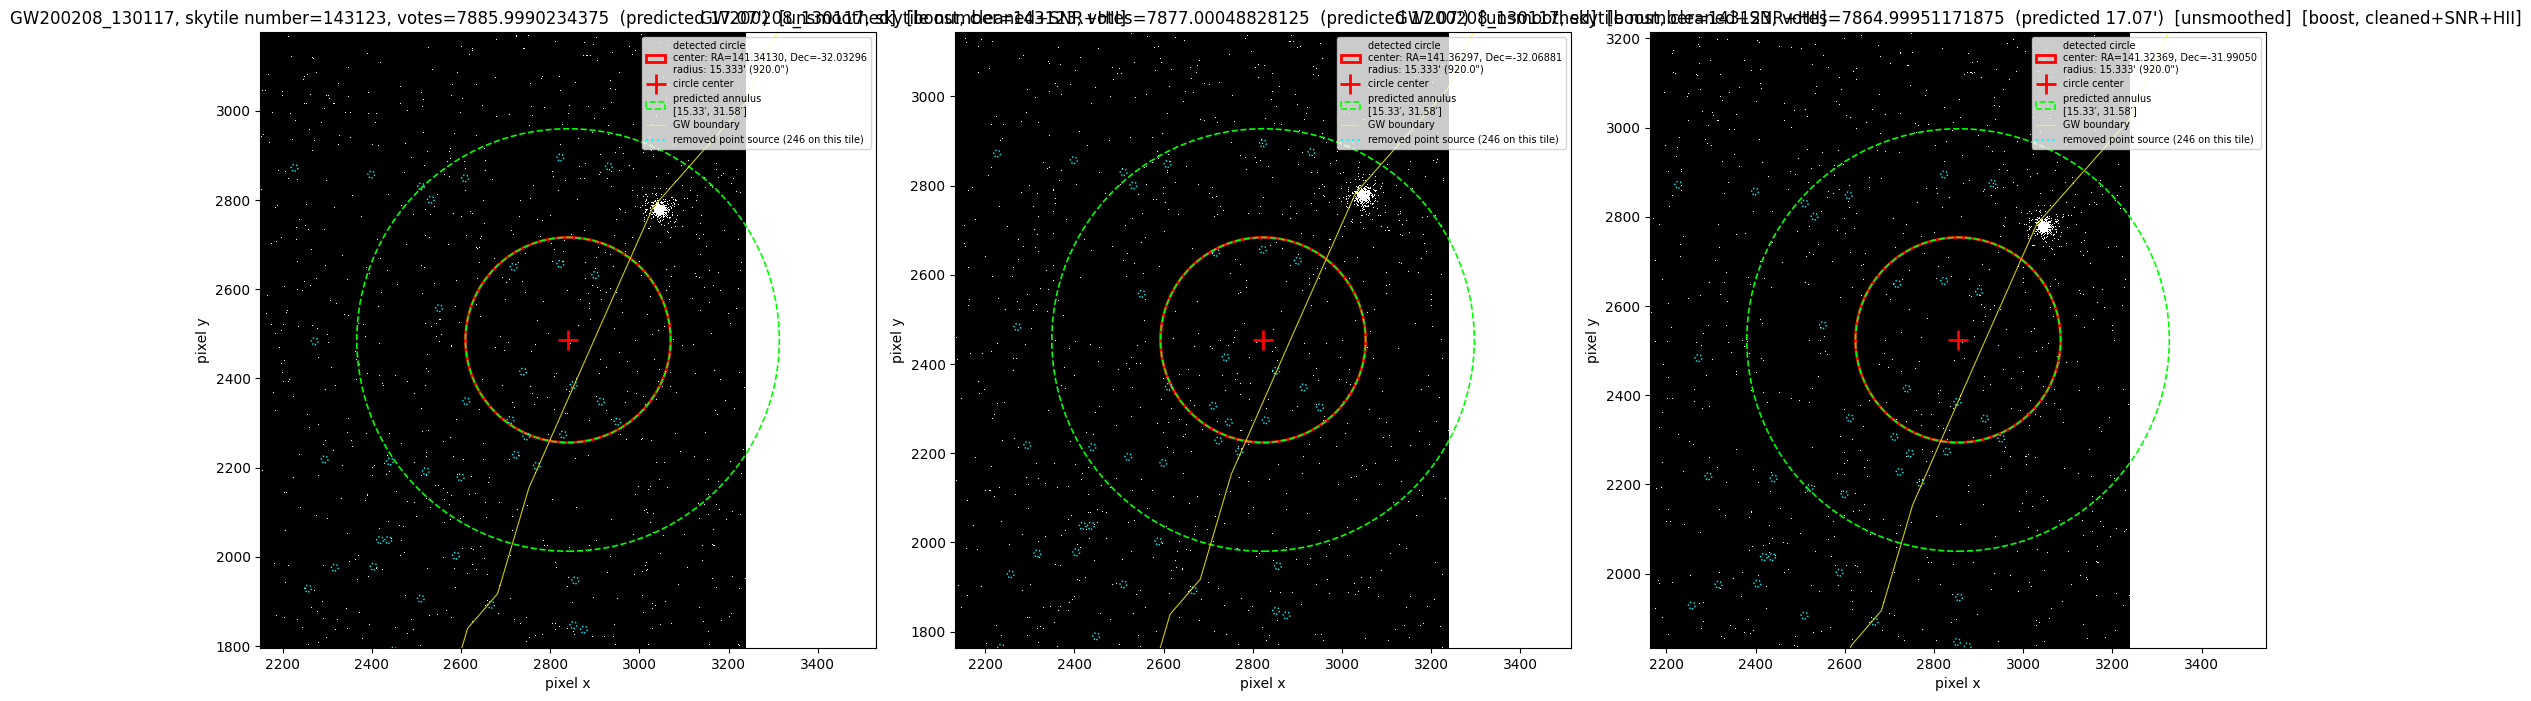

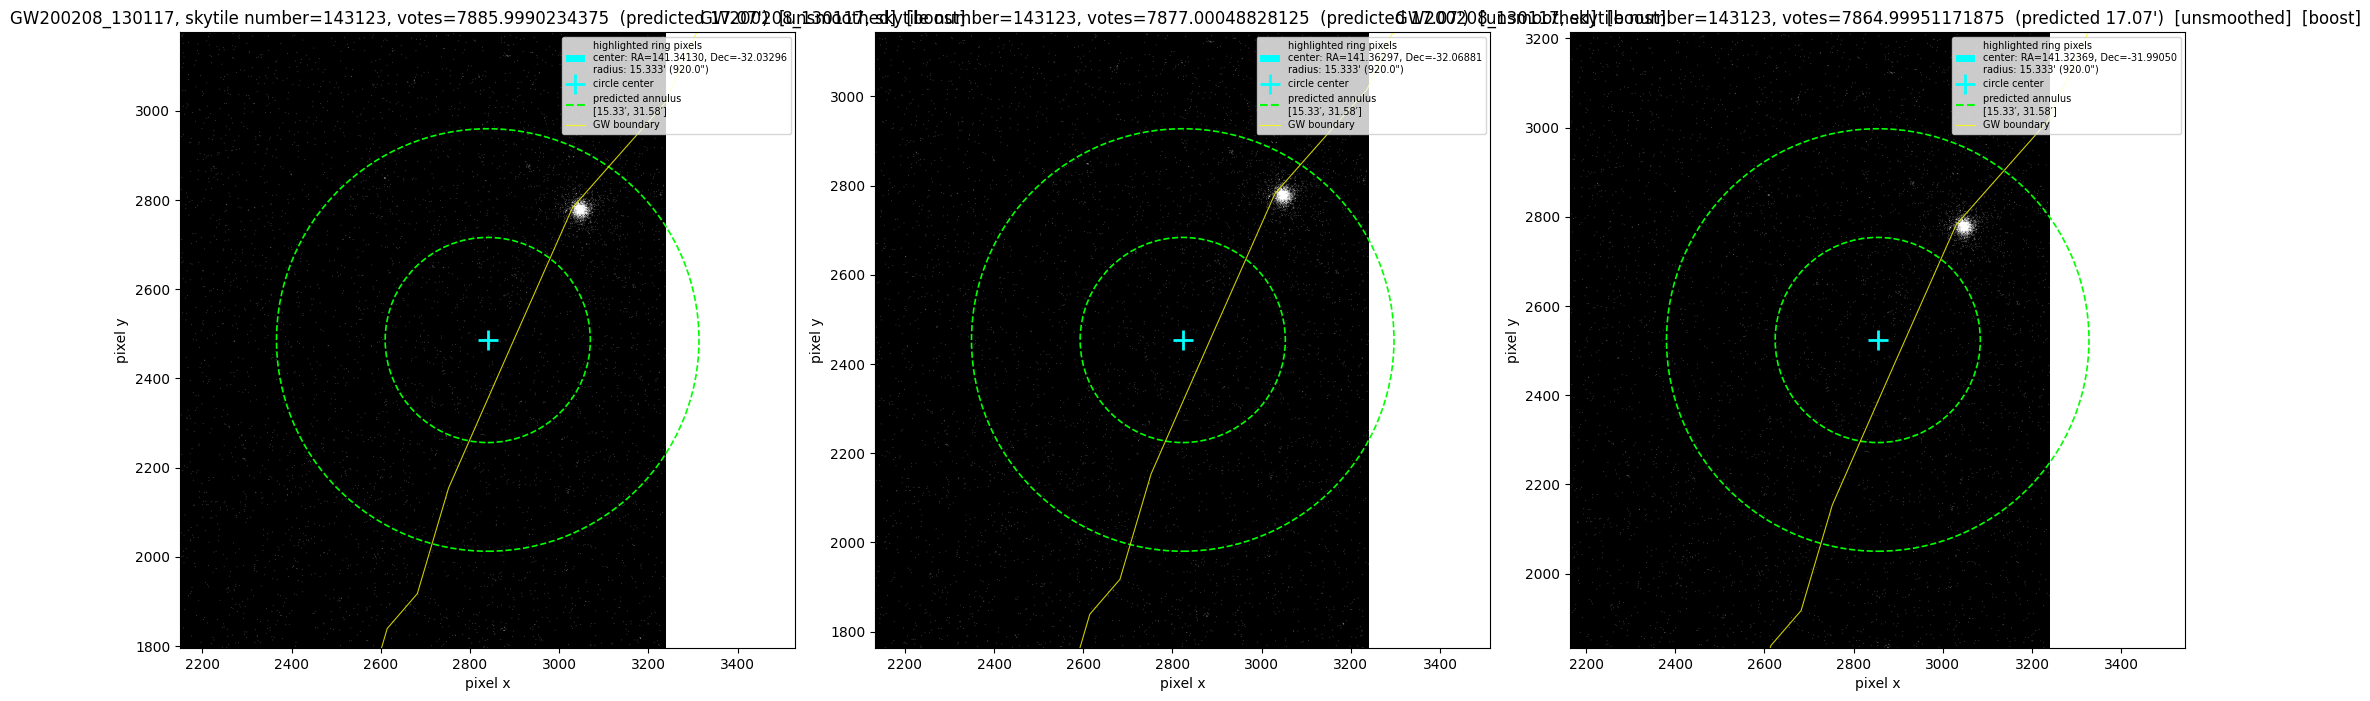

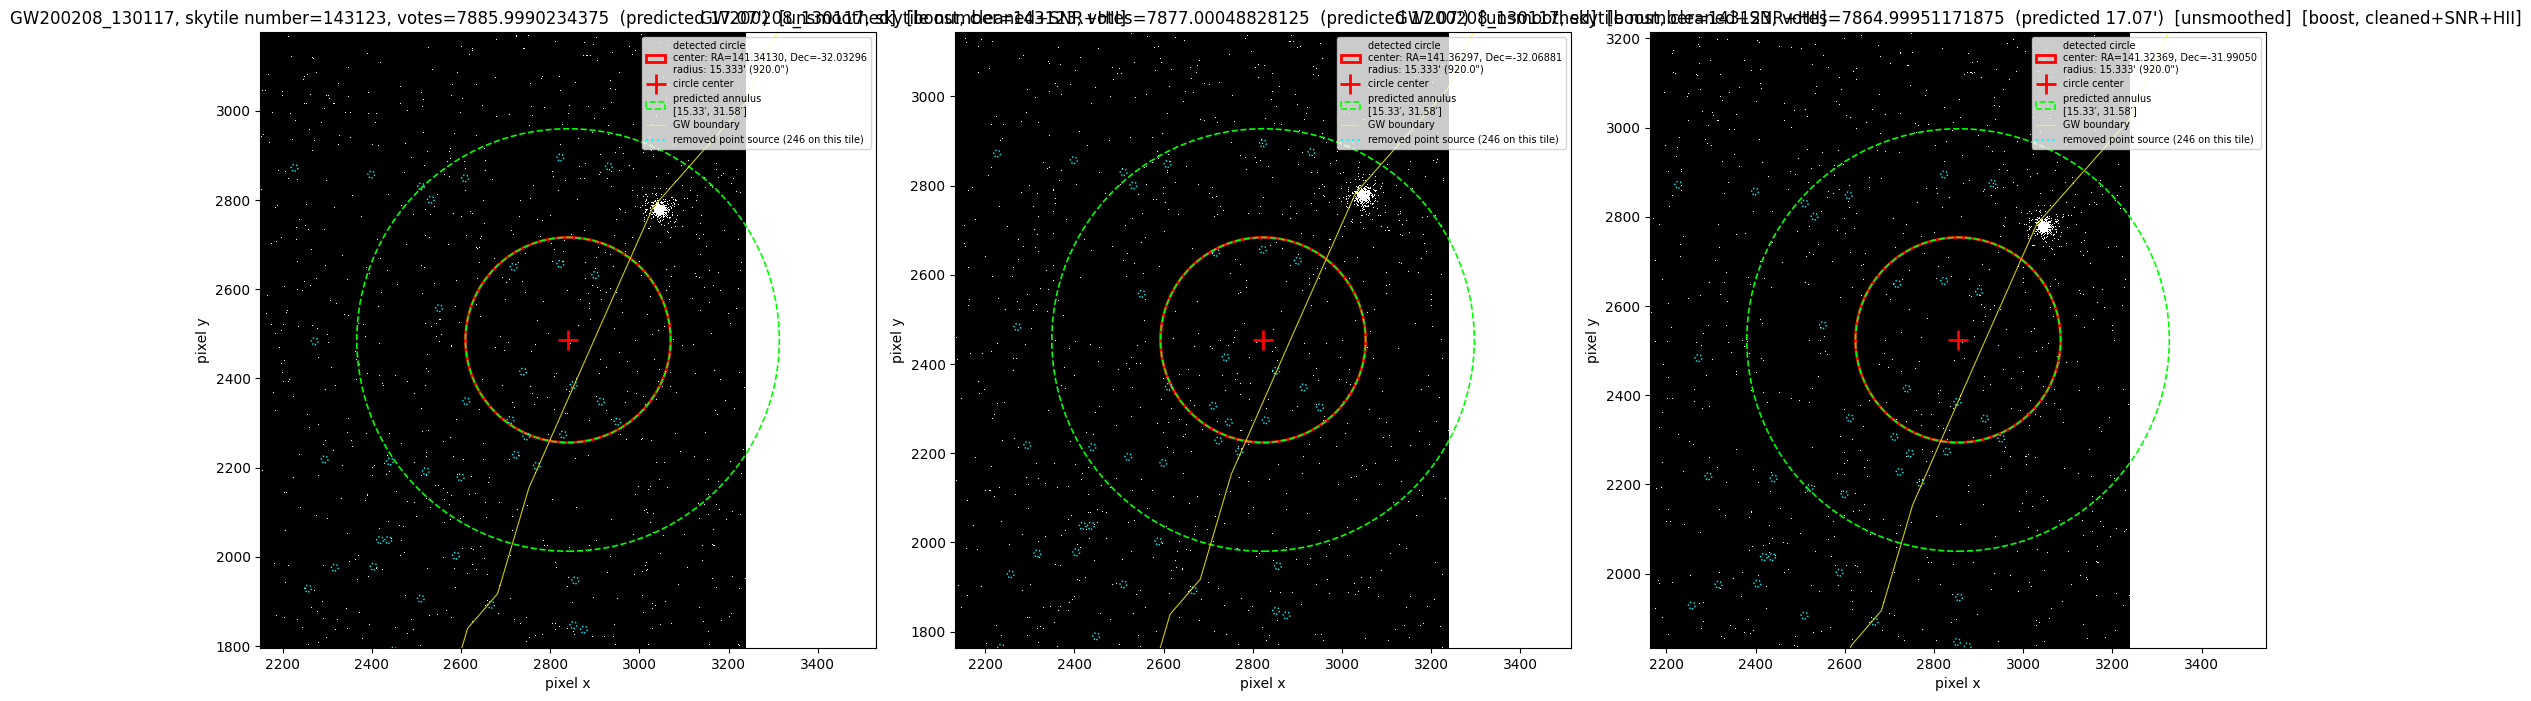

In [84]:
# with p-val now
# SNR + HII-MASKED SEARCH RUN - EXCESS METHOD (SNR: recenters on each
# cataloged SNR's real measured X-ray excess and fits its real extent -
# see fit_snr_excess/remove_snr_sources's docstring. HII: masks every
# cataloged Known/Group-tier WISE HII region overlapping a tile - see
# remove_hii_sources).
#
# remove_hii=True is pinned explicitly here, not just left to
# run_one_search_per_event's own default - the same reason
# remove_snr=False was pinned in the point-source-only baseline cell
# further up. The two SNR-masked cells directly above this one
# (catalog method, excess method) do NOT pin remove_hii, so re-running
# either of THEM today already includes HII masking too
# (run_one_search_per_event defaults remove_hii=True) even though
# neither their filename nor their comments say so - this cell exists
# to have one run whose name and settings actually agree.
#
# Same event set / boundary / annulus search as the two SNR-only cells
# above - only remove_hii differs (explicitly True here vs. implicitly
# True there) - so this file's candidates are directly comparable
# candidate-for-candidate against results_removed_point_sources_and_snr_excess.pkl.
#
# n_workers is pinned at 1, not left to run_one_search_per_event's own
# default (cpu_count()-1): multiprocessing.Pool doesn't actually work
# from this notebook on macOS - macOS's "spawn" process-start method
# needs each worker to re-import the module that defines
# _process_one_tile, but a function defined in a Jupyter cell isn't
# importable that way (see _process_one_tile's own header comment,
# "multiprocessing doesn't work rn"). Every real run in this notebook
# uses n_workers=1 for that reason, not just caution - bumping it up
# is expected to error, not just run hot.
#
# pvalue_threshold stays at photon_annulus_search's default (1e-3,
# ~3.09 sigma) - that only controls what counts as a "peak" at all,
# and is deliberately loose (see SIGNIFICANCE_TEST_PLAN.md). The real
# significance cut happens below via filter_results_by_sigma, applied
# at several sigma levels - including no cut at all, for comparison -
# so the candidate list and plots at each level can be compared
# side by side instead of committing to one threshold up front.

EVENT_NAMES_TO_RERUN = None
# EVENT_NAMES_TO_RERUN = ["GW200208_130117"]

SNR_EXCESS_HII_MASKED_RESULTS_PVAL_PATH = "pval_results_removed_point_sources_and_snr_excess_and_hii.pkl"

snr_excess_hii_masked_results = run_one_search_per_event(
    EVENTS_CSV_PATH, boundary_dir=BOUNDARY_DIR, n_workers=1,
    event_names=EVENT_NAMES_TO_RERUN, remove_snr=True, snr_method="excess", remove_hii=True,
)
# save_results auto-suffixes the filename with the actual
# pvalue_threshold used (see save_results docstring) - capture the
# real path it returns instead of reusing
# SNR_EXCESS_HII_MASKED_RESULTS_PVAL_PATH directly, since that is no
# longer the literal filename on disk.
saved_path = save_results(snr_excess_hii_masked_results, SNR_EXCESS_HII_MASKED_RESULTS_PVAL_PATH)

results = load_results(saved_path)

# None = no sigma cut at all (raw pvalue_threshold=1e-3 output, kept
# for comparison against the filtered sets below). 5 is the
# recommended default cut (see filter_results_by_sigma's docstring for
# where that number comes from); 7 and 10 are stricter cuts to compare
# against it.
SIGMA_LEVELS = [None, 5, 7, 10]

for min_sigma in SIGMA_LEVELS:
    if min_sigma is None:
        sigma_results = results
        print("\n=== unfiltered (pvalue_threshold=1e-3, no sigma cut) ===")
    else:
        sigma_results = filter_results_by_sigma(results, min_sigma)
        save_results(sigma_results, SNR_EXCESS_HII_MASKED_RESULTS_PVAL_PATH)
        print(f"\n=== sigma >= {min_sigma} ===")

    for event_name in results.keys():
        n_kept = len(sigma_results[event_name]["candidates"])
        print(f"  [{event_name}] {n_kept} candidate(s)")

        blobs = load_boundary_polygon(boundary_path_for_event(event_name, BOUNDARY_DIR))
        # masked=True: raw image cropped to the search mask (this
        # cell's original "masked" plot).
        plot_top_candidates(sigma_results, event_name, blobs, n=3, highlight_mode="recolor",
                             save_dir="skytile analysis", masked=True)
        # cleaned=True: point-source/SNR/HII-masked image, with every
        # replaced region circled (removed sources dotted, removed
        # SNRs dashed, removed HII regions dash-dot - see
        # plot_candidate's "Mark every masked ..." blocks) - same as
        # this cell's original cleaned plot.
        plot_top_candidates_cleaned(sigma_results, event_name, blobs, n=3, save_dir="skytile analysis")


In [85]:

"""
Exports detected ring candidates to a CSV: center (ra/dec), fitted
radius (arcmin and arcsec), event/blob membership, and the photon
count in the full predicted dust-scattering-echo annulus (donut) -
NOT the thin single-pixel band at the exact fitted radius that this
used to sum. A dust-scattering echo is smeared over the physical
width derived in halo_size.pdf (annulus_inner_arcmin/annulus_outer_arcmin
on each candidate, i.e. [theta_0, theta_0 + delta_theta] with NO extra
UNCERTAINTY_FRAC padding - see run_halo_search), so summing only the
pixels sitting exactly on the fitted circle throws away most of the
real signal (and most of the ring is never exactly one pixel wide
on a discrete grid anyway). count_photons_on_circle is kept below for
the MAXI J1348-630 radial-profile diagnostic (Step 10's Test A), which
deliberately scans many individual radii to build a profile - that is
a different use case from "how many photons are in the predicted
echo band around this one candidate."
"""

import csv
import numpy as np


def count_photons_on_circle(image, wcs, ra, dec, radius_arcmin,
                             band_halfwidth_px=0.5, arcsec_per_pixel=4.0):
    """
    Sums pixel values (photon counts) in a thin band of pixels whose
    distance from (ra, dec) falls within band_halfwidth_px of the
    exact fitted radius - i.e. the discrete pixel ring that best
    represents the zero-width circle at this image's resolution.

    band_halfwidth_px=0.5 (default) is the minimal width that still
    selects a continuous one-pixel-thick ring; going narrower risks
    gaps in the ring at some angles due to pixel discretization.
    This is NOT a physical halo-width parameter - it exists only to
    handle the floating point center/radius landing between pixels.

    Used for building a radial surface-brightness profile (scanning
    many radii - see the MAXI J1348-630 validation cell), not for
    quantifying a single candidate - use count_photons_in_annulus for
    that (it sums the whole predicted echo band in one call instead
    of needing many thin single-radius bands added together).

    Returns (photon_count, n_pixels_on_circle) - the pixel count is
    useful context since photon_count alone doesn't tell you whether
    a low number means "few photons" or "the circle barely overlapped
    the tile" (e.g. near a tile edge).
    """
    cx, cy = wcs.wcs_world2pix(ra, dec, 0)
    cx, cy = float(cx), float(cy)

    r_px = (radius_arcmin * 60.0) / arcsec_per_pixel

    h, w = image.shape
    yy, xx = np.mgrid[0:h, 0:w]
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)

    circle_mask = np.abs(dist - r_px) <= band_halfwidth_px
    n_pixels = int(circle_mask.sum())
    if n_pixels == 0:
        return 0.0, 0

    photon_count = float(np.nansum(image[circle_mask]))
    return photon_count, n_pixels


def count_photons_in_annulus(image, wcs, ra, dec, r_inner_arcmin, r_outer_arcmin,
                              arcsec_per_pixel=4.0):
    """
    Sums pixel values (photon counts) for every pixel whose distance
    from (ra, dec) falls within [r_inner_arcmin, r_outer_arcmin] - the
    full donut a dust-scattering echo is predicted to occupy, not a
    single-radius band. Pass annulus_inner_arcmin/annulus_outer_arcmin
    from the candidate dict (run_halo_search) as r_inner_arcmin/
    r_outer_arcmin so the counting band matches the physical width
    from halo_size.pdf (no UNCERTAINTY_FRAC padding included there -
    see run_halo_search's comment on why padding the counting band
    would only add background pixels with no benefit).

    Returns (photon_count, n_pixels_in_annulus) - the pixel count is
    useful context (e.g. for converting to a mean surface brightness,
    or noticing the annulus was mostly clipped by a tile edge).
    """
    cx, cy = wcs.wcs_world2pix(ra, dec, 0)
    cx, cy = float(cx), float(cy)

    r_in_px = (r_inner_arcmin * 60.0) / arcsec_per_pixel
    r_out_px = (r_outer_arcmin * 60.0) / arcsec_per_pixel

    h, w = image.shape
    yy, xx = np.mgrid[0:h, 0:w]
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)

    annulus_mask = (dist >= r_in_px) & (dist <= r_out_px)
    n_pixels = int(annulus_mask.sum())
    if n_pixels == 0:
        return 0.0, 0

    photon_count = float(np.nansum(image[annulus_mask]))
    return photon_count, n_pixels


def export_candidates_to_csv(results, out_path, skytiles_root="skytiles"):
    """
    results: the dict returned by run_one_search_per_event -
             {event_name: {"candidates": [...], ...}}
    out_path: where to write the CSV.

    For each candidate, loads its tile's FITS from disk (must already
    be downloaded via download_all_skytiles) and sums photons over the
    full predicted annulus (candidate's own annulus_inner_arcmin to
    annulus_outer_arcmin, via count_photons_in_annulus) around the
    fitted center - NOT just the fitted circle itself. If a tile's
    file can't be found/loaded, the row is still written with
    photon_count/n_pixels left blank, rather than dropping the
    candidate or crashing the whole export - missing local files are
    common (e.g. you've only downloaded a subset of events so far)
    and shouldn't block exporting everything else you do have.
    """
    fieldnames = [
        "event_name", "blob_id", "srvmap",
        "ra_deg", "dec_deg",
        "radius_arcmin", "radius_arcsec",
        "votes", "predicted_theta_arcmin",
        "annulus_inner_arcmin", "annulus_outer_arcmin",
        "photon_count_in_annulus", "n_pixels_in_annulus",
    ]

    # cache loaded (image, wcs) per (event_name, srvmap) so repeated
    # candidates from the same tile don't reload the FITS file each time
    tile_cache = {}

    rows = []
    for event_name, r in results.items():
        for c in r["candidates"]:
            key = (event_name, c["srvmap"])
            if key not in tile_cache:
                try:
                    tile_cache[key] = load_local_skytile(event_name, c["srvmap"], skytiles_root)
                except FileNotFoundError:
                    tile_cache[key] = None

            loaded = tile_cache[key]
            annulus_inner = c["annulus_inner_arcmin"]
            annulus_outer = c["annulus_outer_arcmin"]
            if loaded is None:
                photon_count, n_pixels = "", ""
            else:
                image, wcs = loaded
                photon_count, n_pixels = count_photons_in_annulus(
                    image, wcs, c["ra"], c["dec"], annulus_inner, annulus_outer,
                )

            rows.append({
                "event_name": event_name,
                "blob_id": c["blob_id"],
                "srvmap": c["srvmap"],
                "ra_deg": c["ra"],
                "dec_deg": c["dec"],
                "radius_arcmin": c["radius_arcmin"],
                "radius_arcsec": c["radius_arcmin"] * 60.0,
                "votes": c["votes"],
                "predicted_theta_arcmin": c["predicted_theta_arcmin"],
                "annulus_inner_arcmin": annulus_inner,
                "annulus_outer_arcmin": annulus_outer,
                "photon_count_in_annulus": photon_count,
                "n_pixels_in_annulus": n_pixels,
            })

    with open(out_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    n_missing = sum(1 for k, v in tile_cache.items() if v is None)
    print(f"Wrote {len(rows)} row(s) to {out_path}"
          + (f"  ({n_missing} tile(s) not found locally - photon counts left blank for those)"
             if n_missing else ""))
    return out_path

In [86]:
"""
Inspects a real downloaded skytile FITS file to check whether its
pixel values are actually raw photon counts, rather than assuming
it based on documentation/naming conventions alone.

Checks:
  1. Header keywords that explicitly state what the data represents
     (BUNIT, EXTNAME, HDUCLAS*, or similar) - the most direct evidence.
  2. Whether pixel values are non-negative integers (consistent with
     raw photon counts) vs floats with negative values (would suggest
     some processing like background subtraction already applied).
  3. The full header dump, since the answer might be in a keyword we
     didn't think to check directly.
"""

from astropy.io import fits
import numpy as np


def inspect_skytile_fits(path):
    hdul = fits.open(path)

    print(f"=== {path} ===")
    print(f"Number of HDUs: {len(hdul)}\n")

    for i, hdu in enumerate(hdul):
        print(f"--- HDU {i}: {hdu.name} ---")
        print(f"  type: {type(hdu).__name__}")
        if hdu.data is not None:
            print(f"  data shape: {hdu.data.shape}, dtype: {hdu.data.dtype}")
        else:
            print("  data: None")
        print()

    print("=== Full primary header ===")
    print(repr(hdul[0].header))
    print()

    data = hdul[0].data
    if data is not None:
        print("=== Pixel value statistics (primary HDU) ===")
        finite = data[np.isfinite(data)]
        print(f"  dtype: {data.dtype}")
        print(f"  min: {finite.min()}, max: {finite.max()}")
        print(f"  any negative values: {(finite < 0).any()}")
        print(f"  all values integer-valued: {np.allclose(finite, np.round(finite))}")
        print(f"  fraction of zero pixels: {(finite == 0).mean():.4f}")
        print(f"  unique small values (first 15 sorted unique): {np.unique(finite)[:15]}")

    hdul.close()


In [87]:
# inspect_skytile_fits("skytiles/GW200208_130117/srvmap_136123.fits.gz")


In [88]:
# See vote counts for the circles

"""
Exports candidate vote counts (and other details) from one or more
results dicts to a single CSV, tagged by a "run_label" column so you
can tell which result set (e.g. unsmoothed vs smoothed) each row came
from, and compare/sort/filter everything together in a spreadsheet
or pandas rather than scrolling through printed lists.
"""

import os
import csv


def export_vote_counts(results_by_label, out_path="vote_counts.csv"):
    """
    results_by_label: dict mapping a run label (any string you choose,
        e.g. "unsmoothed", "smoothed_sigma10px") to a results dict
        (the kind returned by run_one_search_per_event).

    Writes one row per candidate, with columns:
        run_label, event_name, rank_in_event, votes, radius_arcmin,
        ra, dec, srvmap, blob_id, predicted_theta_arcmin,
        smoothing_sigma_px

    rank_in_event: 1 = highest-voted candidate for that event within
        that run, 2 = second-highest, etc. - makes it easy to filter
        down to "just the top N per event" later without re-sorting.

    Events with zero candidates still get one row (with votes/etc
    left blank) so you can see at a glance which events had nothing,
    rather than them silently being absent from the CSV.

    Returns out_path.
    """
    fieldnames = [
        "run_label", "event_name", "rank_in_event", "votes",
        "radius_arcmin", "ra", "dec", "srvmap", "blob_id",
        "predicted_theta_arcmin", "smoothing_sigma_px",
    ]

    rows = []
    for run_label, results in results_by_label.items():
        for event_name, r in results.items():
            candidates = sorted(r.get("candidates", []), key=lambda c: -c["votes"])

            if not candidates:
                rows.append({
                    "run_label": run_label, "event_name": event_name,
                    "rank_in_event": "", "votes": "", "radius_arcmin": "",
                    "ra": "", "dec": "", "srvmap": "", "blob_id": "",
                    "predicted_theta_arcmin": "", "smoothing_sigma_px": "",
                })
                continue

            for rank, c in enumerate(candidates, start=1):
                rows.append({
                    "run_label": run_label,
                    "event_name": event_name,
                    "rank_in_event": rank,
                    "votes": c.get("votes"),
                    "radius_arcmin": c.get("radius_arcmin"),
                    "ra": c.get("ra"),
                    "dec": c.get("dec"),
                    "srvmap": c.get("srvmap"),
                    "blob_id": c.get("blob_id"),
                    "predicted_theta_arcmin": c.get("predicted_theta_arcmin"),
                    "smoothing_sigma_px": c.get("smoothing_sigma_px"),
                })

    out_dir = os.path.dirname(out_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    with open(out_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Wrote {len(rows)} row(s) to {out_path}")
    return out_path

In [89]:
# # See vote counts for the circles in most recent run
# RESULTS_PATH = "results_removed_point_sources_and_snr_excess.pkl"

# results = load_results(RESULTS_PATH)

# export_vote_counts({
#     "unsmoothed": results,
# }, out_path="skytile analysis/removed_point_sources_and_snr_excess_vote_counts.csv")


# # # See vote counts for the circles
# for event_name, r in results.items():
#     candidates = r["candidates"]
#     if not candidates:
#         print(f"{event_name}: no candidates")
#         continue
#     votes = sorted([c["votes"] for c in candidates], reverse=True)
#     print(f"{event_name}: n={len(votes)}, top 10 votes = {votes[:10]}")


In [90]:
"""
Diagnostic: walks through run_halo_search's internal steps one at a
time for a single real tile from a zero-candidate event, printing
the size/count at each stage so we can see exactly where it bottoms
out to zero - an empty crop mask (tile doesn't actually overlap the
polygon), zero edge pixels (edge detector found nothing above
threshold), or zero CHT candidates despite real edges (radius window
mismatch or vote threshold too strict).
"""

def diagnose_event(event_name, dt_days, boundary_dir, skytiles_root="skytiles", max_tiles=3):
    """
    Runs the first max_tiles tiles for this event through each
    pipeline stage individually, printing sizes/counts at every step.
    """
    boundary_path = f"{boundary_dir}/{event_name}_boundary.csv"
    tiles, samples, blobs = find_all_skytiles_for_event(boundary_path)
    print(f"Event {event_name}: {len(tiles)} tiles total, checking first {max_tiles}\n")

    theta_min, theta_max, theta_center = search_radius_window_arcmin(dt_days)
    print(f"theta window: [{theta_min:.2f}, {theta_max:.2f}] arcmin "
          f"-> pixel radii [{arcmin_to_pixels(theta_min):.0f}, {arcmin_to_pixels(theta_max):.0f}]\n")

    for tile in tiles[:max_tiles]:
        srvmap = tile["srvmap"]
        print(f"--- srvmap={srvmap} ---")

        try:
            image, wcs = load_local_skytile(event_name, srvmap, skytiles_root=skytiles_root)
        except Exception as e:
            print(f"  [FAILED TO LOAD]: {e}\n")
            continue

        print(f"  image shape: {image.shape}, dtype: {image.dtype}, "
              f"sum: {image.sum():.0f}, nonzero pixels: {(image > 0).sum()}")

        for blob_id, points in blobs.items():
            if len(points) < 3:
                continue
            poly_ra = [p[0] for p in points]
            poly_dec = [p[1] for p in points]

            cropped, mask = crop_to_polygon(image, wcs, poly_ra, poly_dec, margin_deg=0.5)
            n_mask_pixels = mask.sum()
            if n_mask_pixels == 0:
                print(f"  blob {blob_id}: mask is EMPTY (tile doesn't overlap this blob's polygon at all)")
                continue

            n_nonzero_in_mask = (cropped > 0).sum()
            print(f"  blob {blob_id}: mask covers {n_mask_pixels} px, "
                  f"{n_nonzero_in_mask} of those have a nonzero photon count")

            if n_mask_pixels < 100:
                print(f"    -> below min_mask_pixels=100, run_halo_search would bail out here")
                continue

            edges = simple_edge_map(cropped, threshold_sigma=2.5, ignore_mask=mask)
            print(f"    edge pixels found: {edges.sum()}")

            if edges.sum() == 0:
                print(f"    -> zero edges, CHT would find nothing")
                continue

            r_min_px = max(1, int(arcmin_to_pixels(theta_min)))
            r_max_px = int(arcmin_to_pixels(theta_max)) + 1
            candidates = circular_hough_transform(
                edges, range(r_min_px, r_max_px), vote_threshold_frac=0.6
            )
            print(f"    CHT candidates: {len(candidates)}")

        print()


In [91]:
# diagnose_event("GW190512_180714", dt_days=214.78, boundary_dir=BOUNDARY_DIR)

In [92]:
# Plotting skytiles
"""
Plots every downloaded skytile for a given event and
the GW boundary polygon for context. Useful for visually scanning real data
directly, rather than relying only on CHT's vote counts.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS

def plot_one_tile_fullres(event_name, tile, blobs, skytiles_root="skytiles",
                           save_dir=None, dpi=300, display_mode="boost",
                           log_vmin_floor=0.3):
    """
    Plots one tile at ~3240x3240 native resolution.

    display_mode: one of "boost", "log", "percentile".
      - "boost" (default): binary view, any pixel with >=1 photon
        shown at full brightness. Single photons and bright point sources
        look identical.
      - "log": log-scaled brightness, but with vmin deliberately set
        BELOW the minimum real value (see log_vmin_floor). Lets brighter multi-photon pixels/point sources
        still stand out further above single-photon background,
        unlike "boost".
      - "percentile": clips bottom 1% and top 0.5% of values. Linear scaling.

    Returns the saved path (or None if save_dir wasn't given).
    """
    srvmap = tile["srvmap"]
    try:
        image, wcs = load_local_skytile(event_name, srvmap, skytiles_root)
    except FileNotFoundError as e:
        print(f"[skip] srvmap={srvmap}: {e}")
        return None

    h, w = image.shape
    fig, ax = plt.subplots(figsize=(w / dpi, h / dpi))

    if display_mode == "boost":
        # Binary view: any pixel with >=1 photon renders at full
        # brightness (white), zero-count pixels stay black. No
        # continuous scale at all - deliberately throws away "how
        # many counts" information in exchange for making EVERY real
        # detection equally, maximally visible. Best for "is there a
        # photon here at all" scanning; a bright point source looks
        # the same as scattered single-photon background.
        display_image = (image > 0).astype(float)
        ax.imshow(display_image, origin="lower", cmap="gray", vmin=0, vmax=1, interpolation="nearest")

    elif display_mode == "log":
        # FIXED log scale: vmin is set BELOW the minimum real value
        # (1 photon), not at it. The original bug (still reproducible
        # via display_mode="percentile") set vmin from the 1st
        # percentile of nonzero pixels - which, since ~98% of real
        # nonzero pixels are exactly 1 photon in sparse eROSITA data,
        # landed EXACTLY at 1, putting single-photon pixels at the
        # very floor of the log range (log10(1)=vmin -> 0% brightness,
        # indistinguishable from true zero). Setting vmin to a value
        # clearly below 1 (default 0.3) gives single photons real,
        # visible brightness (~46% in testing) while still leaving
        # room for brighter multi-photon pixels to stand out further
        # above them - unlike "boost" mode, which makes a 1-photon
        # pixel and a 1000-photon source look identical.
        vmax = max(image.max(), log_vmin_floor * 2)  # avoid a degenerate vmax<=vmin
        log_vmin = np.log10(log_vmin_floor)
        log_vmax = np.log10(vmax)
        display_image = np.log10(np.clip(image, log_vmin_floor, vmax))
        ax.imshow(display_image, origin="lower", cmap="inferno",
                  vmin=log_vmin, vmax=log_vmax, interpolation="nearest")

    else:  # "percentile" - the ORIGINAL behavior, kept for comparison.
        # Known to make single-photon pixels nearly invisible on
        # realistic sparse data (vmin lands at the 1st percentile of
        # nonzero values, which equals 1 photon ~98% of the time) -
        # use "log" or "boost" instead unless you specifically want
        # to reproduce the old behavior.
        finite_vals = image[np.isfinite(image) & (image > 0)]
        if finite_vals.size:
            vmin, vmax = np.percentile(finite_vals, [1, 99.5])
            vmin = max(vmin, 1e-3)
        else:
            vmin, vmax = 1e-3, 1.0
        display_image = np.log10(np.clip(image, vmin, vmax))
        ax.imshow(display_image, origin="lower", cmap="inferno",
                  vmin=np.log10(vmin), vmax=np.log10(vmax))

    for bid, points in blobs.items():
        if len(points) < 2:
            continue
        poly_ra = [p[0] for p in points]
        poly_dec = [p[1] for p in points]
        px, py = wcs.wcs_world2pix(poly_ra, poly_dec, 0)
        if len(points) >= 3:
            px = np.append(px, px[0])
            py = np.append(py, py[0])
        ax.plot(px, py, "-", color="yellow", linewidth=0.8, alpha=0.8)

    # A boundary blob only needs to graze this tile to be included at
    # all - most of its polygon can extrapolate far outside the tile
    # in this tile's own pixel frame. Without clamping, that far-out
    # geometry drags matplotlib's autoscale along with it, shrinking
    # the actual tile image down into a tiny corner of the plot.
    ax.set_xlim(0, w)
    ax.set_ylim(0, h)

    ax.set_title(f"{event_name}  srvmap={srvmap}", fontsize=10)
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")
    fig.tight_layout()

    out_path = None
    if save_dir is not None:
        event_dir = os.path.join(save_dir, event_name)
        os.makedirs(event_dir, exist_ok=True)
        out_path = os.path.join(event_dir, f"fullres_srvmap_{srvmap:06d}.png")
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved {out_path}")

    return out_path


def plot_all_tiles_fullres(event_name, blobs, tiles, skytiles_root="skytiles",
                            save_dir="skytile analysis", dpi=300, display_mode="boost",
                            log_vmin_floor=0.3):
    """
    Convenience loop: saves one full-resolution PNG per tile for an
    event (see plot_one_tile_fullres). Does NOT display all of them
    inline (that would be a lot of large figures at once) - just
    saves to disk for later browsing/zooming. Returns the list of
    saved paths.
    """
    paths = []
    for tile in tiles:
        path = plot_one_tile_fullres(event_name, tile, blobs, skytiles_root=skytiles_root,
                                      save_dir=save_dir, dpi=dpi,
                                      display_mode=display_mode, log_vmin_floor=log_vmin_floor)
        if path:
            paths.append(path)
    print(f"\nSaved {len(paths)} full-resolution tile image(s) for {event_name}")
    return paths

In [93]:
# Raw-vs-cleaned full-tile comparison
"""
Side-by-side raw|cleaned PNGs, one pair per tile, at full-tile
resolution - lets you see directly what the cleaning pipeline (point
source + SNR + HII masking) actually changed on a given tile, rather
than only the candidate-zoomed view plot_candidate(cleaned=True/False)
already provides.

Saves ONE PNG per tile (mirroring plot_one_tile_fullres/
plot_all_tiles_fullres above), not one combined multi-tile mosaic
(plot_all_tiles_mosaic below) - deliberately, to keep memory bounded.
An event can cover dozens of 3240x3240 tiles; a mosaic holds every
tile's pixel data in memory at once to build one combined array,
while this loads/renders/saves one tile's raw+cleaned pair at a time
and closes the figure immediately after, so memory use never scales
with event size.
"""

import os
import numpy as np
import matplotlib.pyplot as plt


def _tile_display_image(image, display_mode="boost", log_vmin_floor=0.3):
    """
    Same three display modes as plot_one_tile_fullres (boost/log/
    percentile - see its docstring for what each means), factored out
    here so the raw and cleaned panels below render with identical
    scaling and are actually comparable side by side. Returns
    (display_image, cmap_name, vmin, vmax) ready to hand to imshow.
    """
    if display_mode == "boost":
        return (image > 0).astype(float), "gray", 0, 1

    if display_mode == "log":
        linear_vmax = max(float(image.max()), log_vmin_floor * 2)
        vmin, vmax = np.log10(log_vmin_floor), np.log10(linear_vmax)
        return np.log10(np.clip(image, log_vmin_floor, linear_vmax)), "inferno", vmin, vmax

    finite_vals = image[np.isfinite(image) & (image > 0)]
    if finite_vals.size:
        raw_vmin, raw_vmax = np.percentile(finite_vals, [1, 99.5])
        raw_vmin = max(raw_vmin, 1e-3)
    else:
        raw_vmin, raw_vmax = 1e-3, 1.0
    return np.log10(np.clip(image, raw_vmin, raw_vmax)), "inferno", np.log10(raw_vmin), np.log10(raw_vmax)


def plot_one_tile_raw_vs_cleaned(event_name, tile, blobs, skytiles_root="skytiles",
                                  save_dir="skytile analysis", dpi=200, display_mode="boost",
                                  log_vmin_floor=0.3, remove_snr=True, remove_hii=True,
                                  snr_margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN,
                                  hii_margin_arcsec=DEFAULT_HII_MARGIN_ARCSEC,
                                  mark_removed=True,
                                  source_marker_color="cyan", snr_marker_color="magenta",
                                  hii_marker_color="orange"):
    """
    Plots one tile's raw image (left) next to its cleaned image
    (right) at full-tile resolution, both scaled identically (see
    _tile_display_image) so brightness differences reflect the
    masking, not a display-range mismatch.

    mark_removed: if True (default), overlays small circles on the
    cleaned panel at every removed point source (dotted, cyan), SNR
    (dashed, magenta), and HII region (dash-dot, orange) - same
    marker style plot_candidate uses, sized the same way
    (mask_radius_arcsec for point sources, radius_arcmin +
    snr_margin_arcmin for SNRs, radius_arcsec + hii_margin_arcsec for
    HII regions) so a circle shown here matches what was actually
    masked. Skipped if this tile can't be resolved to a real srvmap or
    cleaning fails outright (falls back to a cleaned panel with no
    markers rather than failing the whole plot).

    Returns the saved path (or None if save_dir wasn't given, or if
    the raw tile itself isn't downloaded yet).
    """
    srvmap = tile["srvmap"]
    try:
        raw_image, wcs = load_local_skytile(event_name, srvmap, skytiles_root)
    except FileNotFoundError as e:
        print(f"[skip] srvmap={srvmap}: {e}")
        return None

    try:
        cleaned_image, _, removed_sources, removed_snrs, removed_hii_regions = load_cleaned_skytile(
            event_name, srvmap, skytiles_root=skytiles_root,
            remove_snr=remove_snr, snr_margin_arcmin=snr_margin_arcmin,
            remove_hii=remove_hii, hii_margin_arcsec=hii_margin_arcsec,
        )
    except Exception as e:
        print(f"    [WARNING] srvmap={srvmap}: cleaning failed ({e}) - "
              f"showing the raw image on both panels instead")
        cleaned_image = raw_image
        removed_sources, removed_snrs, removed_hii_regions = {"RA": [], "DEC": [], "EXT": []}, [], []

    h, w = raw_image.shape
    fig, axes = plt.subplots(1, 2, figsize=(2 * w / dpi, h / dpi))

    for ax, image, title in ((axes[0], raw_image, "raw"), (axes[1], cleaned_image, "cleaned")):
        display_image, cmap_name, vmin, vmax = _tile_display_image(
            image, display_mode=display_mode, log_vmin_floor=log_vmin_floor)
        ax.imshow(display_image, origin="lower", cmap=cmap_name, vmin=vmin, vmax=vmax,
                  interpolation="nearest")

        for bid, points in blobs.items():
            if len(points) < 2:
                continue
            poly_ra = [p[0] for p in points]
            poly_dec = [p[1] for p in points]
            px, py = wcs.wcs_world2pix(poly_ra, poly_dec, 0)
            if len(points) >= 3:
                px = np.append(px, px[0])
                py = np.append(py, py[0])
            ax.plot(px, py, "-", color="yellow", linewidth=0.8, alpha=0.8)

        # A boundary blob only needs to graze this tile to be drawn at
        # all - most of its polygon can extrapolate far outside the
        # tile in this tile's own pixel frame. Without clamping, that
        # far-out geometry drags matplotlib's autoscale along with it,
        # shrinking the actual tile image into a tiny corner of the
        # panel. Explicitly pin the view to the tile's own extent
        # instead, since that's what this comparison is actually for.
        ax.set_xlim(0, w)
        ax.set_ylim(0, h)

        ax.set_title(f"{title}", fontsize=10)
        ax.set_xlabel("pixel x")
        ax.set_ylabel("pixel y")

    if mark_removed:
        cleaned_ax = axes[1]
        for i in range(len(removed_sources["RA"])):
            sx, sy = wcs.wcs_world2pix(removed_sources["RA"][i], removed_sources["DEC"][i], 0)
            source_radius_px = mask_radius_arcsec(removed_sources["EXT"][i]) / ARCSEC_PER_PIXEL
            cleaned_ax.add_patch(plt.Circle((float(sx), float(sy)), source_radius_px, fill=False,
                                             edgecolor=source_marker_color, linewidth=0.6, linestyle=":"))
        for snr in removed_snrs:
            snrx, snry = wcs.wcs_world2pix(snr["ra_deg"], snr["dec_deg"], 0)
            snr_radius_px = (snr["radius_arcmin"] + snr_margin_arcmin) * 60.0 / ARCSEC_PER_PIXEL
            cleaned_ax.add_patch(plt.Circle((float(snrx), float(snry)), snr_radius_px, fill=False,
                                             edgecolor=snr_marker_color, linewidth=1.0, linestyle="--"))
        for region in removed_hii_regions:
            hx, hy = wcs.wcs_world2pix(region["ra_deg"], region["dec_deg"], 0)
            hii_radius_px = (region["radius_arcsec"] + hii_margin_arcsec) / ARCSEC_PER_PIXEL
            cleaned_ax.add_patch(plt.Circle((float(hx), float(hy)), hii_radius_px, fill=False,
                                             edgecolor=hii_marker_color, linewidth=0.6, linestyle="-."))

    fig.suptitle(f"{event_name}  srvmap={srvmap}  [{display_mode}]"
                  f"  ({len(removed_sources['RA'])} sources, {len(removed_snrs)} SNRs, "
                  f"{len(removed_hii_regions)} HII regions removed)", fontsize=10)
    fig.tight_layout()

    out_path = None
    if save_dir is not None:
        event_dir = os.path.join(save_dir, event_name)
        os.makedirs(event_dir, exist_ok=True)
        out_path = os.path.join(event_dir, f"rawvscleaned_srvmap_{srvmap:06d}.png")
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved {out_path}")

    plt.close(fig)
    return out_path


def plot_all_tiles_raw_vs_cleaned(event_name, blobs, tiles, skytiles_root="skytiles",
                                   save_dir="skytile analysis", dpi=200, display_mode="boost",
                                   log_vmin_floor=0.3, remove_snr=True, remove_hii=True,
                                   snr_margin_arcmin=DEFAULT_SNR_MARGIN_ARCMIN,
                                   hii_margin_arcsec=DEFAULT_HII_MARGIN_ARCSEC,
                                   mark_removed=True):
    """
    Convenience loop: saves one raw-vs-cleaned PNG per tile for an
    event (see plot_one_tile_raw_vs_cleaned). Does NOT display all of
    them inline, same reasoning as plot_all_tiles_fullres - just
    saves to disk for later browsing. Returns the list of saved paths.
    """
    paths = []
    for tile in tiles:
        path = plot_one_tile_raw_vs_cleaned(
            event_name, tile, blobs, skytiles_root=skytiles_root, save_dir=save_dir,
            dpi=dpi, display_mode=display_mode, log_vmin_floor=log_vmin_floor,
            remove_snr=remove_snr, remove_hii=remove_hii,
            snr_margin_arcmin=snr_margin_arcmin, hii_margin_arcsec=hii_margin_arcsec,
            mark_removed=mark_removed,
        )
        if path:
            paths.append(path)
    print(f"\nSaved {len(paths)} raw-vs-cleaned tile image(s) for {event_name}")
    return paths


In [94]:
# plot full gw event skytile
"""
Combines ALL of an event's downloaded skytiles into ONE large mosaic
image, with each tile placed at its real sky position (not just an
arbitrary grid order) and at full native resolution (4 arcsec/pixel,
same as the individual tiles - no downsampling).

This builds the combined image as a raw pixel array directly (not
via matplotlib's imshow, which isn't well-suited to compositing many
separately-positioned images at this scale) - much faster and more
memory-predictable for large mosaics, since there's no per-axes
rendering overhead, just direct array placement.

WARNING: at full native resolution with no cap, a many-tile event
can require a genuinely large amount of memory and produce a large
file. E.g. a 32-tile event arranged in its real ~6x6ish footprint
can need on the order of 300+ megapixels (~1+ GB in memory during
construction). This is intentional (no downsampling, per your
request), but be aware it may take a while and use significant RAM
for events with many tiles.
"""

import os
import numpy as np
from PIL import Image

ARCSEC_PER_PIXEL = 4.0
DEG_PER_PIXEL = ARCSEC_PER_PIXEL / 3600.0


def plot_all_tiles_mosaic(event_name, tiles, blobs=None, skytiles_root="skytiles",
                           save_dir="skytile analysis", boost_single_photons=True,
                           boundary_color=(255, 255, 0), boundary_width=4):
    """
    Builds one combined mosaic image of every downloaded tile for
    this event, placed at its real RA/Dec position, at full native
    4 arcsec/pixel resolution.

    boost_single_photons: same idea as plot_all_tiles_fullres's
        "boost" mode - any pixel with >=1 photon renders at full
        brightness (255), since a continuous brightness scale makes
        single-photon detections (the vast majority of real signal)
        nearly invisible. Set False for a raw linear-count grayscale
        instead (not recommended - very faint on real sparse data).

    blobs: optional {blob_id: [(ra,dec),...]} polygon dict (e.g. from
        load_boundary_polygon) - if given, draws the GW boundary
        polygon(s) on top of the mosaic as a thin colored line,
        converted directly into canvas pixel coordinates (this is a
        raw pixel array, not a matplotlib axes, so the line is drawn
        with PIL rather than ax.plot - boundary_width is in PIXELS
        here, not the "linewidth" units matplotlib uses elsewhere,
        so a visually-similar thinness to the other plots' lines
        needs a small pixel count, not a directly equivalent number).

    Returns the saved file path, or None if no tiles could be loaded.
    """
    # Pass 1: load every tile's data + WCS, and find the overall sky
    # bounding box (in RA/Dec) across all of them, so we know how big
    # the combined canvas needs to be.
    loaded_tiles = []
    ra_min, ra_max = None, None
    dec_min, dec_max = None, None

    for tile in tiles:
        srvmap = tile["srvmap"]
        try:
            image, wcs = load_local_skytile(event_name, srvmap, skytiles_root)
        except FileNotFoundError as e:
            print(f"[skip] srvmap={srvmap}: {e}")
            continue

        h, w = image.shape
        # corners of this tile, in sky coordinates
        corner_x = np.array([0, w, 0, w])
        corner_y = np.array([0, 0, h, h])
        corner_ra, corner_dec = wcs.wcs_pix2world(corner_x, corner_y, 0)

        tile_ra_min, tile_ra_max = float(np.min(corner_ra)), float(np.max(corner_ra))
        tile_dec_min, tile_dec_max = float(np.min(corner_dec)), float(np.max(corner_dec))

        loaded_tiles.append({
            "srvmap": srvmap, "image": image, "wcs": wcs,
            "ra_min": tile_ra_min, "ra_max": tile_ra_max,
            "dec_min": tile_dec_min, "dec_max": tile_dec_max,
        })

        ra_min = tile_ra_min if ra_min is None else min(ra_min, tile_ra_min)
        ra_max = tile_ra_max if ra_max is None else max(ra_max, tile_ra_max)
        dec_min = tile_dec_min if dec_min is None else min(dec_min, tile_dec_min)
        dec_max = tile_dec_max if dec_max is None else max(dec_max, tile_dec_max)

    if not loaded_tiles:
        print(f"No tiles could be loaded for {event_name}")
        return None

    # cos(dec) correction so RA spans translate to a sane pixel width
    # near the actual declination of this event, not equator-assumed
    cos_dec = np.cos(np.radians((dec_min + dec_max) / 2.0))

    ra_span_deg = (ra_max - ra_min) * cos_dec
    dec_span_deg = dec_max - dec_min

    canvas_w = int(np.ceil(ra_span_deg / DEG_PER_PIXEL)) + 1
    canvas_h = int(np.ceil(dec_span_deg / DEG_PER_PIXEL)) + 1

    print(f"[{event_name}] mosaic canvas: {canvas_w} x {canvas_h} px "
          f"({canvas_w*canvas_h/1e6:.0f} megapixels) from {len(loaded_tiles)} tile(s)")
    print(f"    canvas covers RA=[{ra_min:.4f}, {ra_max:.4f}], Dec=[{dec_min:.4f}, {dec_max:.4f}]")

    canvas = np.zeros((canvas_h, canvas_w), dtype=np.float32)

    # Pass 2: place each tile's pixels into the canvas at their real
    # sky-position offset. Uses each tile's OWN per-pixel RA/Dec (via
    # its WCS) rather than assuming a uniform grid, so real tile
    # rotation/distortion is respected rather than approximated.
    for t in loaded_tiles:
        image, wcs = t["image"], t["wcs"]
        h, w = image.shape

        yy, xx = np.mgrid[0:h, 0:w]
        ra, dec = wcs.wcs_pix2world(xx, yy, 0)

        # convert this tile's pixel sky-coords into canvas pixel coords
        canvas_x = ((ra_max - ra) * cos_dec / DEG_PER_PIXEL).astype(np.int64)
        canvas_y = ((dec - dec_min) / DEG_PER_PIXEL).astype(np.int64)

        valid = (
            (canvas_x >= 0) & (canvas_x < canvas_w) &
            (canvas_y >= 0) & (canvas_y < canvas_h)
        )

        # place photon counts; where tiles overlap, take the max
        # (avoids double-counting overlapping tile regions while
        # still showing real signal from either tile)
        flat_cx = canvas_x[valid]
        flat_cy = canvas_y[valid]
        flat_vals = image[valid]
        np.maximum.at(canvas, (flat_cy, flat_cx), flat_vals)

        print(f"    placed srvmap={t['srvmap']} ({h}x{w}) into canvas")

    if boost_single_photons:
        gray = (canvas > 0).astype(np.uint8) * 255
    else:
        finite_vals = canvas[canvas > 0]
        if finite_vals.size:
            vmax = finite_vals.max()
            gray = np.clip(canvas / max(vmax, 1) * 255, 0, 255).astype(np.uint8)
        else:
            gray = np.zeros_like(canvas, dtype=np.uint8)

    # flip vertically for image save convention (origin top-left) vs
    # our canvas convention (dec increasing = canvas_y increasing,
    # i.e. origin lower-left, matching origin='lower' used elsewhere)
    gray = np.flipud(gray)

    # Build an RGB image (grayscale replicated across channels) so a
    # colored boundary line can be drawn on top - a pure grayscale
    # ("L" mode) image can't hold a yellow line.
    rgb = np.stack([gray, gray, gray], axis=-1)
    img = Image.fromarray(rgb, mode="RGB")

    if blobs is not None:
        from PIL import ImageDraw
        draw = ImageDraw.Draw(img)
        for bid, points in blobs.items():
            if len(points) < 2:
                continue
            poly_ra = np.array([p[0] for p in points])
            poly_dec = np.array([p[1] for p in points])
            print(f"    blob {bid}: RA=[{poly_ra.min():.4f}, {poly_ra.max():.4f}], "
                  f"Dec=[{poly_dec.min():.4f}, {poly_dec.max():.4f}] "
                  f"({len(points)} points)")
            # same RA/Dec -> canvas pixel transform used for tile
            # placement above, then flip y to match the post-flipud
            # image (top-left origin) rather than the pre-flip canvas
            # (bottom-left origin) coordinates used during placement.
            poly_x = (ra_max - poly_ra) * cos_dec / DEG_PER_PIXEL
            poly_y_canvas = (poly_dec - dec_min) / DEG_PER_PIXEL
            poly_y_image = (canvas_h - 1) - poly_y_canvas

            line_pts = list(zip(poly_x.tolist(), poly_y_image.tolist()))
            if len(points) >= 3:
                line_pts.append(line_pts[0])  # close the polygon

            draw.line(line_pts, fill=boundary_color, width=boundary_width)

    out_path = None
    if save_dir is not None:
        event_dir = os.path.join(save_dir, event_name)
        os.makedirs(event_dir, exist_ok=True)
        out_path = os.path.join(event_dir, f"mosaic_all_tiles_fullres.png")
        img.save(out_path)
        size_mb = os.path.getsize(out_path) / 1e6
        print(f"Saved {out_path} ({size_mb:.1f} MB)")

    return out_path

In [95]:
# blobs = load_boundary_polygon(boundary_path_for_event("GW200208_130117", BOUNDARY_DIR))
# plot_all_tiles_mosaic("GW200208_130117", results["GW200208_130117"]["tiles"], blobs=blobs, save_dir="skytile analysis")

In [96]:
# Raw-vs-cleaned check: for every downloaded tile of this event, save a
# side-by-side raw (left) vs fully-filtered (right, point source + SNR +
# HII masking) PNG, so the masking can be visually checked tile by tile
# rather than trusted blindly.
#
# Self-contained: paths and results/blobs are loaded directly here
# (not via RESULTS_PATH/BOUNDARY_DIR, which are only set by other cells
# further up) - as long as the function-definition cells earlier in the
# notebook have been run at least once this kernel session, this cell
# can be run on its own.
import os

results = load_results("results_removed_point_sources_and_snr_excess.pkl")
boundary_dir = os.path.join("x-rays E = 1.0keV for filtering", "overlap_boundaries")
blobs = load_boundary_polygon(boundary_path_for_event("GW200208_130117", boundary_dir))

plot_all_tiles_raw_vs_cleaned(
    "GW200208_130117", blobs, results["GW200208_130117"]["tiles"],
    save_dir="skytile analysis",
)

Loaded results_removed_point_sources_and_snr_excess.pkl: 7 event(s), 55287 total candidate(s)
tile 136123: 260 catalogued sources -> masked 46393 pixels (0.44% of the image)
Saved skytile analysis/GW200208_130117/rawvscleaned_srvmap_136123.png
tile 140126: 272 catalogued sources -> masked 48327 pixels (0.46% of the image)
Saved skytile analysis/GW200208_130117/rawvscleaned_srvmap_140126.png
tile 139123: 282 catalogued sources -> masked 50291 pixels (0.48% of the image)
Saved skytile analysis/GW200208_130117/rawvscleaned_srvmap_139123.png
tile 139120: 286 catalogued sources -> masked 51705 pixels (0.49% of the image)
Saved skytile analysis/GW200208_130117/rawvscleaned_srvmap_139120.png
tile 138129: 248 catalogued sources -> masked 44858 pixels (0.43% of the image)
tile 138129: SNR G261.9+05.5 - too close to/off this tile's edge to measure, falling back to catalog-circle masking
tile 138129: masked 487803 pixels (4.65% of the image) total (snr_method='excess')
Saved skytile analysis/GW20

['skytile analysis/GW200208_130117/rawvscleaned_srvmap_136123.png',
 'skytile analysis/GW200208_130117/rawvscleaned_srvmap_140126.png',
 'skytile analysis/GW200208_130117/rawvscleaned_srvmap_139123.png',
 'skytile analysis/GW200208_130117/rawvscleaned_srvmap_139120.png',
 'skytile analysis/GW200208_130117/rawvscleaned_srvmap_138129.png',
 'skytile analysis/GW200208_130117/rawvscleaned_srvmap_142129.png',
 'skytile analysis/GW200208_130117/rawvscleaned_srvmap_143123.png']

real_srvmap=205153  tile_center=(205.263,-63.017)  offset=0.845 deg
 15.0'  0.0103
 16.0'  0.0111
 17.0'  0.0122
 18.0'  0.0118
 19.0'  0.0115
 20.0'  0.0113
 21.0'  0.0112
 22.0'  0.0111
 23.0'  0.0111
 24.0'  0.0113
 25.0'  0.0112
 26.0'  0.0110
 27.0'  0.0115
 28.0'  0.0116
 29.0'  0.0107
 30.0'  0.0103
 31.0'  0.0102
 32.0'  0.0102
 33.0'  0.0105
 34.0'  0.0113  <-- in 34-40' band
 35.0'  0.0129  <-- in 34-40' band
 36.0'  0.0144  <-- in 34-40' band
 37.0'  0.0146  <-- in 34-40' band
 38.0'  0.0159  <-- in 34-40' band
 39.0'  0.0178  <-- in 34-40' band
 40.0'  0.0139  <-- in 34-40' band
 41.0'  0.0086
 42.0'  0.0078
 43.0'  0.0082
 44.0'  0.0084
 45.0'  0.0079
 46.0'  0.0079
 47.0'  0.0083
 48.0'  0.0084
 49.0'  0.0090
 50.0'  0.0092
 51.0'  0.0083
 52.0'  0.0082
 53.0'  0.0090
 54.0'  0.0099

theta_target=37.00'  -> dt_days=578.1 (reverse-engineered, not a real GW delay), search window=[33.30', 40.70']

True center in this tile: (895.2, 1377.0)
Top 5 photon_annulus_search candidat

(<Figure size 1080x1080 with 1 Axes>,
 <Axes: title={'center': 'MAXI J1348-630  srvmap=205153  photon_annulus_search: top 5 candidates'}, xlabel='pixel x', ylabel='pixel y'>)

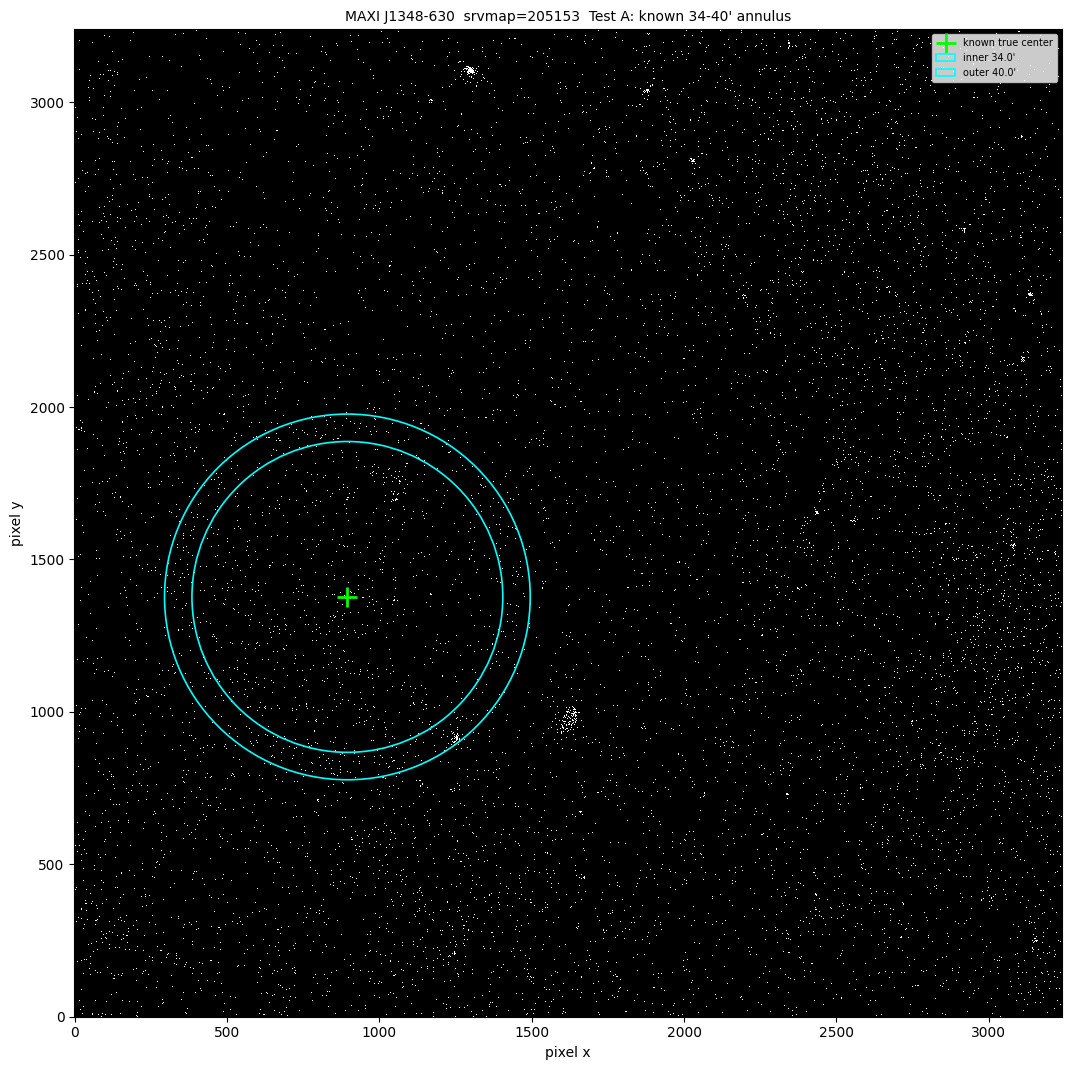

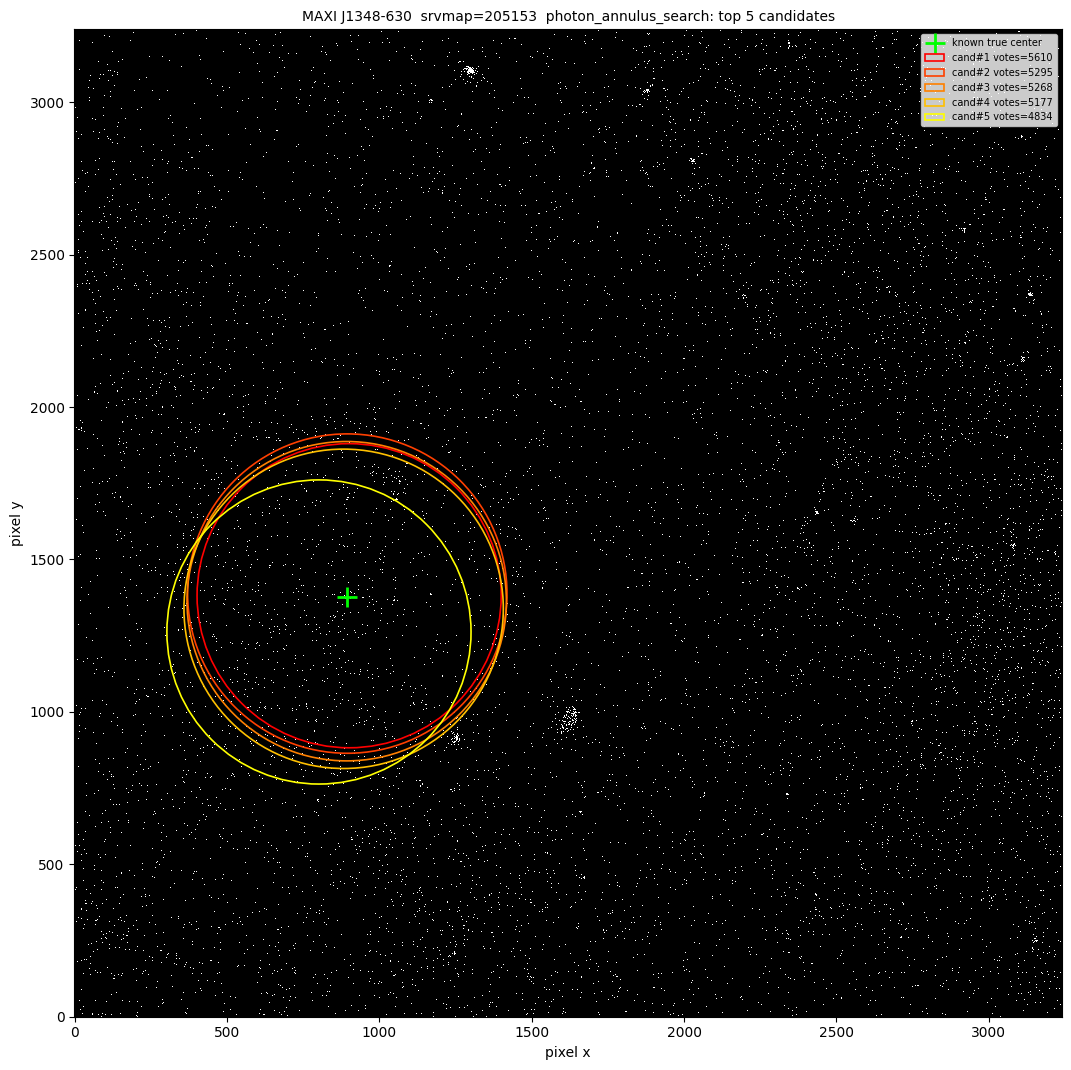

In [97]:
# test to look for MAXI J1348-630 eRASS1
# paper: A giant X-ray dust scattering ring discovered with SRG/eROSITA around the black hole transient MAXI J1348–630
# Lamer et. al.
#
# Test B below now runs the pipeline's actual production search method,
# photon_annulus_search (direct photon-counting ring kernel + FFT
# convolution - see run_one_search_per_event), instead of the retired
# simple_edge_map/circular_hough_transform approach. photon_annulus_search
# has no smoothing step at all (it's built to work directly on raw,
# single-photon-dominated counts), so the old "smoothed vs unsmoothed"
# split doesn't apply anymore - there's just one run now.
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

TARGET_RA  = 207.052917   # 13h48m12.7s
TARGET_DEC = -63.274917   # -63d16m29.7s
RING_MIN_ARCMIN = 34.0
RING_MAX_ARCMIN = 40.0
EVENT_NAME = "MAXI_J1348-630"

margin = 1.0  # degrees; > 40' outer radius with room to spare

box_ra  = [TARGET_RA - margin, TARGET_RA + margin, TARGET_RA + margin, TARGET_RA - margin]
box_dec = [TARGET_DEC - margin, TARGET_DEC - margin, TARGET_DEC + margin, TARGET_DEC + margin]

real_srvmap, actual_ra, actual_dec, offset_deg = find_real_srvmap(TARGET_RA, TARGET_DEC)
print(f"real_srvmap={real_srvmap}  tile_center=({actual_ra:.3f},{actual_dec:.3f})  offset={offset_deg:.3f} deg")

dest_dir = os.path.join("skytiles", EVENT_NAME)
os.makedirs(dest_dir, exist_ok=True)
dest_path = os.path.join(dest_dir, f"srvmap_{real_srvmap:06d}.fits.gz")

download_skytile_image(real_srvmap, dest_path, expected_ra=TARGET_RA, expected_dec=TARGET_DEC)
image, wcs = load_local_skytile(EVENT_NAME, real_srvmap, skytiles_root="skytiles")

cx_true, cy_true = wcs.wcs_world2pix(TARGET_RA, TARGET_DEC, 0)
cx_true, cy_true = float(cx_true), float(cy_true)


# --- TEST A: direct radial photon profile at the KNOWN center ---
# This bypasses the search's center-finding entirely and replicates
# the paper's own method (Fig. 2: radial surface-brightness profile).
radii_arcmin = np.arange(15, 55, 1.0)
profile = []
for r in radii_arcmin:
    counts, npix = count_photons_on_circle(
        image, wcs, TARGET_RA, TARGET_DEC, r,
        band_halfwidth_px=15,   # ~1 arcmin-wide bin, wide enough to average noise
    )
    profile.append(counts / max(npix, 1))  # normalize to counts/pixel

for r, v in zip(radii_arcmin, profile):
    marker = "  <-- in 34-40' band" if RING_MIN_ARCMIN <= r <= RING_MAX_ARCMIN else ""
    print(f"{r:5.1f}'  {v:.4f}{marker}")


# --- TEST B: photon_annulus_search, the pipeline's actual search method ---
# photon_annulus_search predicts its own search window from dt_days (time
# since a GW detection) via predicted_theta_arcmin - that doesn't apply
# here, since MAXI J1348-630 isn't tied to a GW event. Instead, invert
# predicted_theta_arcmin to find the dt_days that makes the predicted
# theta land at the midpoint of the paper's own published 34'-40' ring,
# so the search's default +/-10% window (UNCERTAINTY_FRAC) brackets it
# the same way it would for a real event - this is NOT a real GW time
# delay, just a way to point the real search method at the known ring.
theta_target = (RING_MIN_ARCMIN + RING_MAX_ARCMIN) / 2.0
dt_days_target = REF_TAU_DAYS * (theta_target / REF_THETA_ARCMIN) ** 2
theta_lo = theta_target * (1 - UNCERTAINTY_FRAC)
theta_hi = theta_target * (1 + UNCERTAINTY_FRAC)
print(f"\ntheta_target={theta_target:.2f}'  -> dt_days={dt_days_target:.1f} "
      f"(reverse-engineered, not a real GW delay), "
      f"search window=[{theta_lo:.2f}', {theta_hi:.2f}']")

candidates = photon_annulus_search(image, wcs, box_ra, box_dec, dt_days_target)
candidates.sort(key=lambda c: -c["votes"])

print(f"\nTrue center in this tile: ({cx_true:.1f}, {cy_true:.1f})")
print("Top 5 photon_annulus_search candidates (x_px, y_px, radius_arcmin, votes):")
for c in candidates[:5]:
    dist_from_true = ((c["x_px"] - cx_true) ** 2 + (c["y_px"] - cy_true) ** 2) ** 0.5
    print(f"  ({c['x_px']},{c['y_px']}) r={c['radius_arcmin']:.2f}' votes={c['votes']:.0f}  "
          f"dist_from_known_center={dist_from_true:.1f}px")


# --- Plotting ---
def plot_boost_native(image, wcs, circles, title, save_path=None, dpi=300):
    """
    Native-resolution boost-mode plot (same binary any-photon=full-brightness
    logic as plot_one_tile_fullres's display_mode="boost"), with circle
    overlays instead of a boundary polygon.

    circles: list of dicts, each with:
        ra, dec           - center in degrees
        radius_arcmin     - None to just mark a center point, no circle
        color             - matplotlib color
        label             - legend label
        mark_center       - bool, draw a '+' at the center
    """
    h, w = image.shape
    fig, ax = plt.subplots(figsize=(w / dpi, h / dpi))

    display_image = (image > 0).astype(float)
    ax.imshow(display_image, origin="lower", cmap="gray", vmin=0, vmax=1, interpolation="nearest")

    arcsec_per_pixel = 4.0
    for c in circles:
        cx, cy = wcs.wcs_world2pix(c["ra"], c["dec"], 0)
        cx, cy = float(cx), float(cy)
        if c.get("radius_arcmin") is not None:
            r_px = (c["radius_arcmin"] * 60.0) / arcsec_per_pixel
            ax.add_patch(Circle((cx, cy), r_px, fill=False, edgecolor=c.get("color", "red"),
                                 linewidth=1.2, label=c.get("label")))
        if c.get("mark_center"):
            ax.plot(cx, cy, "+", color=c.get("color", "red"), markersize=14, markeredgewidth=2,
                     label=c.get("label") if c.get("radius_arcmin") is None else None)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc="upper right", fontsize=7)
    fig.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved {save_path}")
    return fig, ax


# Test A: known 34'-40' annulus
plot_boost_native(
    image, wcs,
    circles=[
        {"ra": TARGET_RA, "dec": TARGET_DEC, "radius_arcmin": None,
         "color": "lime", "label": "known true center", "mark_center": True},
        {"ra": TARGET_RA, "dec": TARGET_DEC, "radius_arcmin": RING_MIN_ARCMIN,
         "color": "cyan", "label": f"inner {RING_MIN_ARCMIN}'"},
        {"ra": TARGET_RA, "dec": TARGET_DEC, "radius_arcmin": RING_MAX_ARCMIN,
         "color": "cyan", "label": f"outer {RING_MAX_ARCMIN}'"},
    ],
    title=f"MAXI J1348-630  srvmap={real_srvmap}  Test A: known 34-40' annulus",
    save_path="skytile analysis/MAXI_J1348-630/testA_annulus_boost.png",
)

# Test B: photon_annulus_search top candidates
top_n = 5
colors = plt.cm.autumn(np.linspace(0, 1, top_n))
circles_b = [
    {"ra": TARGET_RA, "dec": TARGET_DEC, "radius_arcmin": None,
     "color": "lime", "label": "known true center", "mark_center": True},
]
for i, c in enumerate(candidates[:top_n]):
    circles_b.append({
        "ra": c["ra"], "dec": c["dec"],
        "radius_arcmin": c["radius_arcmin"],
        "color": tuple(colors[i][:3]),
        "label": f"cand#{i+1} votes={c['votes']:.0f}",
        "mark_center": True,  # '+' at the predicted center, same color as its circle
    })

plot_boost_native(
    image, wcs, circles_b,
    title=f"MAXI J1348-630  srvmap={real_srvmap}  photon_annulus_search: top {top_n} candidates",
    save_path="skytile analysis/MAXI_J1348-630/testB_photon_annulus_search_boost.png",
)


tile 205153: 353 catalogued sources -> masked 64211 pixels (0.61% of the image)
tile 205153: SNR G306.3-00.9 - too close to/off this tile's edge to measure, falling back to catalog-circle masking
tile 205153: SNR G308.1-00.7 -> NOT masked (sig=3.8sigma < 15.0sigma floor, no significant excess found on this tile)
tile 205153: SNR G308.4-01.4 -> masked (sig=26.4sigma, radius=5.0', offset=4.1' from catalog position)
tile 205153: SNR G308.8-00.1 -> NOT masked (sig=7.2sigma < 15.0sigma floor, no significant excess found on this tile)
tile 205153: SNR G309.2-00.6 -> NOT masked (sig=10.8sigma < 15.0sigma floor, no significant excess found on this tile)
tile 205153: SNR G309.8+00.0 -> NOT masked (sig=4.9sigma < 15.0sigma floor, no significant excess found on this tile)
tile 205153: SNR G310.6-01.6 - too close to/off this tile's edge to measure, falling back to catalog-circle masking
tile 205153: SNR G310.6-00.3 - too close to/off this tile's edge to measure, falling back to catalog-circle mask

(<Figure size 1080x1080 with 1 Axes>,
 <Axes: title={'center': "MAXI J1348-630  srvmap=205153  Test A v2: known 34-40' annulus (cleaned/masked image)"}, xlabel='pixel x', ylabel='pixel y'>)

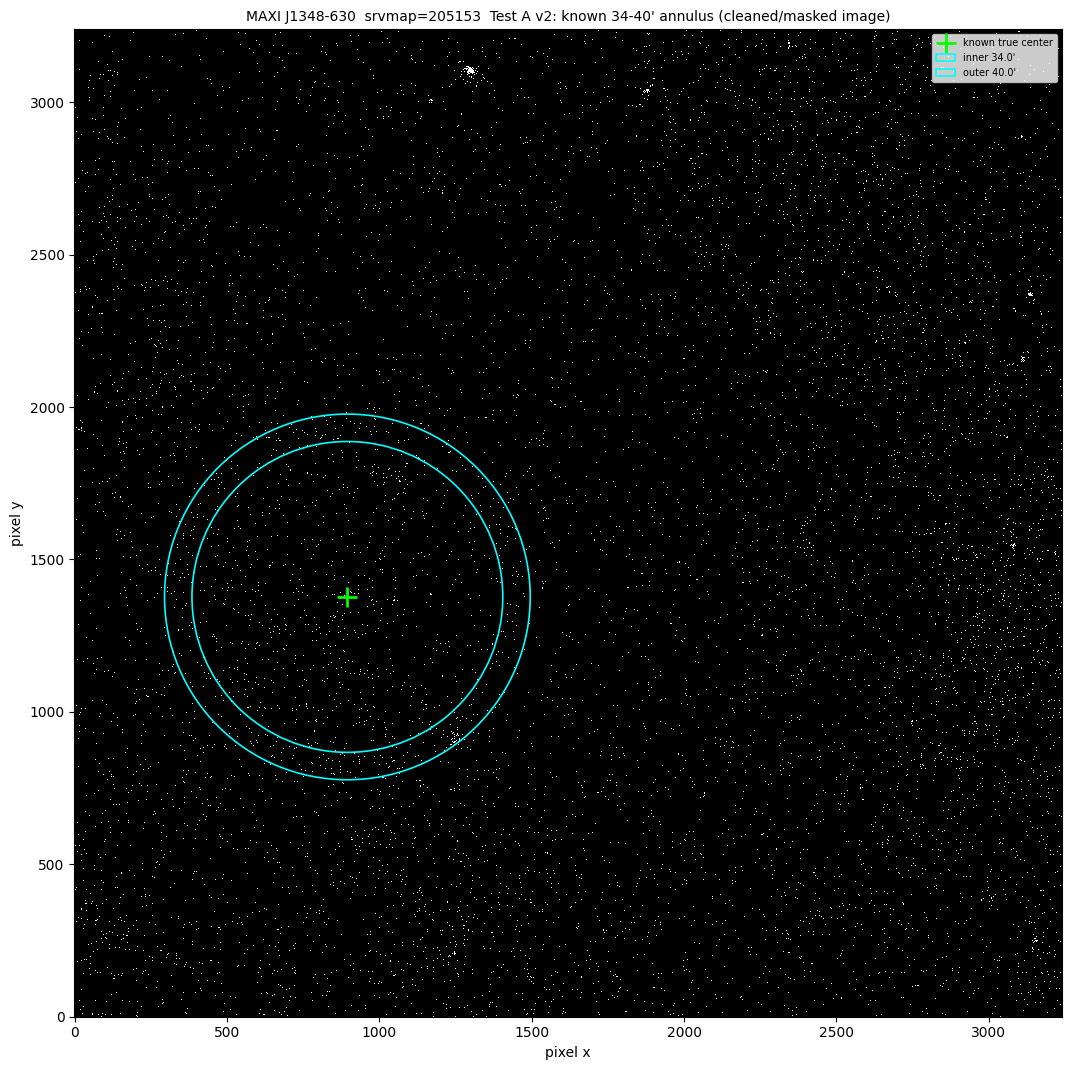

In [98]:
# --- TEST A v2: same radial photon profile, but on the cleaned
# (point-source + SNR + HII masked) image instead of the raw one ---
#
# Test A above measures the raw tile directly, matching the paper's own
# method exactly. This repeats the same radial profile after applying
# this pipeline's own masking (remove_point_sources + remove_snr_sources
# + remove_hii_sources, via load_cleaned_skytile - the same masking
# run_one_search_per_event applies by default) - a check that cleaning
# doesn't destroy or shift the real ring signal MAXI J1348-630 is known
# to have. Additive only: doesn't change Test A/B above, just adds a
# second profile (and plot) for comparison against the raw one.

cleaned_image, wcs_cleaned, removed_sources, removed_snrs, removed_hii_regions = load_cleaned_skytile(
    EVENT_NAME, real_srvmap, skytiles_root="skytiles", remove_snr=True, remove_hii=True,
)

profile_masked = []
for r in radii_arcmin:
    counts, npix = count_photons_on_circle(
        cleaned_image, wcs_cleaned, TARGET_RA, TARGET_DEC, r,
        band_halfwidth_px=15,   # same bin width as Test A, for a like-for-like comparison
    )
    profile_masked.append(counts / max(npix, 1))

print(f"\n{len(removed_sources['RA'])} point source(s), {len(removed_snrs)} SNR(s), "
      f"{len(removed_hii_regions)} HII region(s) masked on this tile.\n")
print(f"{'radius':>7}  {'raw':>8}  {'masked':>8}")
for r, v_raw, v_masked in zip(radii_arcmin, profile, profile_masked):
    marker = "  <-- in 34-40' band" if RING_MIN_ARCMIN <= r <= RING_MAX_ARCMIN else ""
    print(f"{r:5.1f}'  {v_raw:8.4f}  {v_masked:8.4f}{marker}")

plot_boost_native(
    cleaned_image, wcs_cleaned,
    circles=[
        {"ra": TARGET_RA, "dec": TARGET_DEC, "radius_arcmin": None,
         "color": "lime", "label": "known true center", "mark_center": True},
        {"ra": TARGET_RA, "dec": TARGET_DEC, "radius_arcmin": RING_MIN_ARCMIN,
         "color": "cyan", "label": f"inner {RING_MIN_ARCMIN}'"},
        {"ra": TARGET_RA, "dec": TARGET_DEC, "radius_arcmin": RING_MAX_ARCMIN,
         "color": "cyan", "label": f"outer {RING_MAX_ARCMIN}'"},
    ],
    title=f"MAXI J1348-630  srvmap={real_srvmap}  Test A v2: known 34-40' annulus (cleaned/masked image)",
    save_path="skytile analysis/MAXI_J1348-630/testA_v2_annulus_boost_cleaned.png",
)
